In [3]:
from torch.utils.data import Dataset, DataLoader

def load_splits(
    splits_dir: str     = SPLITS_DIR,
    tokenizer_name: str = ROBERTA_NAME,
    max_len: int        = MAX_LEN,
    batch_size: int     = BATCH_SIZE,
):
    train_df = pd.read_csv(os.path.join(splits_dir, "train.csv"))
    val_df   = pd.read_csv(os.path.join(splits_dir, "val.csv"))
    test_df  = pd.read_csv(os.path.join(splits_dir, "test.csv"))
    map_df   = pd.read_csv(os.path.join(splits_dir, "label_mapping.csv"))

    # Проверяем маппинг
    for _, row in map_df.iterrows():
        expected = CLASS_TO_ID[row["class_name"]]
        actual   = int(row["class_id"])
        assert expected == actual, (
            f"Mapping mismatch: {row['class_name']} "
            f"expected id={expected}, got id={actual}. "
            f"Re-run prepare_and_save_splits()!"
        )

    num_labels = len(emotion_classes)
    samples_per_class = [int((train_df["label_id"] == i).sum()) for i in range(num_labels)]

    print(f"Splits loaded from: {splits_dir}/")
    print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print(f"\n  Train samples per class:")
    for i, cls in enumerate(emotion_classes):
        print(f"    id={i}  {cls:<12}: {samples_per_class[i]:>5}")

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    X_train, y_train = train_df["tweet_text"], train_df["label_id"]
    X_val,   y_val   = val_df["tweet_text"],   val_df["label_id"]
    X_test,  y_test  = test_df["tweet_text"],  test_df["label_id"]

    ds_train = TweetDataset(X_train, y_train, tokenizer, max_len)
    ds_val   = TweetDataset(X_val,   y_val,   tokenizer, max_len)
    ds_test  = TweetDataset(X_test,  y_test,  tokenizer, max_len)

    loaders = {
        "train": DataLoader(ds_train, batch_size=batch_size,     shuffle=True),
        "val":   DataLoader(ds_val,   batch_size=batch_size * 2, shuffle=False),
        "test":  DataLoader(ds_test,  batch_size=batch_size * 2, shuffle=False),
    }

    meta = {
        "num_labels":        num_labels,
        "samples_per_class": samples_per_class,
        "tokenizer":         tokenizer,
        "X_train": X_train, "y_train": y_train,
        "X_val":   X_val,   "y_val":   y_val,
        "X_test":  X_test,  "y_test":  y_test,
        "train_df": train_df,
        "val_df":   val_df,
        "test_df":  test_df,
    }

    return loaders, meta

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels":         torch.tensor(int(self.labels[idx]), dtype=torch.long),
        }

In [4]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import re
import random
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

# ============================================================
# КОНФИГУРАЦИЯ
# ============================================================

ROBERTA_NAME    = "cardiffnlp/twitter-roberta-large-emotion-latest"
MAX_LEN         = 128
BATCH_SIZE      = 64           # ← было 32
EPOCHS          = 20
ENCODER_LR      = 3e-5         # ← было 2e-5 (поднято под больший batch)
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
PATIENCE        = 5
SEED            = 42

# DataLoader
NUM_WORKERS     = 4
PIN_MEMORY      = True

# Mixed precision (FP16 для V100 — нативная поддержка через Tensor Cores)
USE_AMP         = True
AMP_DTYPE       = torch.float16

emotion_classes  = ["neutral", "happiness", "anger", "disgust", "sadness", "surprise", "fear"]
CLASS_TO_ID      = {cls: i for i, cls in enumerate(emotion_classes)}
MINORITY_CLASSES = ["fear", "disgust", "surprise"]

SPLITS_DIR = "splits"
OUTPUT_DIR = "head_experiments"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"AMP: {USE_AMP}  |  dtype: {AMP_DTYPE}  |  Batch: {BATCH_SIZE}  |  Encoder LR: {ENCODER_LR}")

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

# ============================================================
# ЛОСС
# ============================================================

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_prob  = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            dist = torch.full_like(log_prob, self.smoothing / (n_classes - 1))
            dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(dist * log_prob).sum(dim=-1).mean()

# ============================================================
# ATTENTION POOLING
# ============================================================

class AttentionPooling(nn.Module):
    """
    Bahdanau-style attention pooling.
    attention_dim = H/4 — стандартное соотношение.
    Маскирование через -1e4 — безопасно для FP16
    (-1e9 переполнило бы FP16, диапазон ±65504).
    """
    def __init__(self, hidden_size):
        super().__init__()
        attention_dim  = hidden_size // 4
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, attention_dim),
            nn.Tanh(),
            nn.Linear(attention_dim, 1),
        )

    def forward(self, hidden_states, attention_mask):
        scores  = self.attention(hidden_states)                       # [B, T, 1]
        scores  = scores.masked_fill(
            attention_mask.unsqueeze(-1) == 0, -1e4)                  # FP16-safe
        weights = torch.softmax(scores, dim=1)                        # [B, T, 1]
        return (hidden_states * weights).sum(dim=1)                   # [B, H]


# ============================================================
# 6 АРХИТЕКТУР ГОЛОВ
# ============================================================

class RobertaLinearHead(nn.Module):
    HEAD_LR = 2e-5
    USES_POOLING = True

    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling    = AttentionPooling(H)
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(H, num_labels)

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        pooled = self.pooling(seq, attention_mask)
        return self.classifier(self.dropout(pooled))

    def head_parameters(self):
        return list(self.pooling.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())


class RobertaMLPHead(nn.Module):
    HEAD_LR = 5e-5
    USES_POOLING = True

    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling = AttentionPooling(H)
        self.head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(H, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_labels),
        )

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        pooled = self.pooling(seq, attention_mask)
        return self.head(pooled)

    def head_parameters(self):
        return list(self.pooling.parameters()) + list(self.head.parameters())


class RobertaCNNHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = False

    def __init__(self, model_name, num_labels,
                 num_filters=128, kernel_sizes=(2, 3, 4)):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size

        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=H, out_channels=num_filters,
                      kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(num_filters * len(kernel_sizes), num_labels)

    def forward(self, input_ids, attention_mask):
        seq   = self.backbone(input_ids=input_ids,
                              attention_mask=attention_mask).last_hidden_state
        seq_t = seq.permute(0, 2, 1)
        mask_t = attention_mask.unsqueeze(1).to(seq_t.dtype)
        seq_t  = seq_t * mask_t

        pooled_list = []
        for conv in self.convs:
            x = F.gelu(conv(seq_t))
            x = F.adaptive_max_pool1d(x, 1).squeeze(-1)
            pooled_list.append(x)

        cat = torch.cat(pooled_list, dim=1)
        return self.classifier(self.dropout(cat))

    def head_parameters(self):
        return list(self.convs.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())


class RobertaBiLSTMHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = False

    def __init__(self, model_name, num_labels, lstm_hidden=256):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.lstm = nn.LSTM(
            input_size    = H,
            hidden_size   = lstm_hidden,
            num_layers    = 1,
            bidirectional = True,
            batch_first   = True,
        )
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(lstm_hidden * 2, num_labels)

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        # LSTM безопаснее держать в FP32 (cuDNN bias to FP16 иногда нестабилен)
        with autocast('cuda', enabled=False):
            seq_fp32 = seq.float()
            out, _   = self.lstm(seq_fp32)

        mask = attention_mask.unsqueeze(-1).to(out.dtype)
        pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        return self.classifier(self.dropout(pooled))

    def head_parameters(self):
        return list(self.lstm.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())


class RobertaResidualMLPHead(nn.Module):
    HEAD_LR = 5e-5
    USES_POOLING = True

    def __init__(self, model_name, num_labels, n_blocks=2):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling     = AttentionPooling(H)
        self.input_drop  = nn.Dropout(0.2)

        self.blocks = nn.ModuleList([
            nn.ModuleDict({
                "norm":     nn.LayerNorm(H),
                "linear1":  nn.Linear(H, H),
                "linear2":  nn.Linear(H, H),
                "dropout":  nn.Dropout(0.2),
            })
            for _ in range(n_blocks)
        ])

        self.final_norm  = nn.LayerNorm(H)
        self.classifier  = nn.Linear(H, num_labels)

    def _block_forward(self, x, block):
        h = block["norm"](x)
        h = block["linear1"](h)
        h = F.gelu(h)
        h = block["dropout"](h)
        h = block["linear2"](h)
        return x + h

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        x      = self.pooling(seq, attention_mask)
        x      = self.input_drop(x)
        for block in self.blocks:
            x = self._block_forward(x, block)
        x = self.final_norm(x)
        return self.classifier(x)

    def head_parameters(self):
        return list(self.pooling.parameters()) + \
               list(self.input_drop.parameters()) + \
               list(self.blocks.parameters()) + \
               list(self.final_norm.parameters()) + \
               list(self.classifier.parameters())


class RobertaBottleneckHead(nn.Module):
    HEAD_LR = 5e-5
    USES_POOLING = True

    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling = AttentionPooling(H)
        self.head = nn.Sequential(
            nn.LayerNorm(H),
            nn.Dropout(0.2),
            nn.Linear(H, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_labels),
        )

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        pooled = self.pooling(seq, attention_mask)
        return self.head(pooled)

    def head_parameters(self):
        return list(self.pooling.parameters()) + list(self.head.parameters())


# ============================================================
# OPTIMIZER (без изменений)
# ============================================================

def build_optimizer(model, encoder_lr, head_lr, weight_decay):
    encoder_params = list(model.backbone.parameters())
    head_params    = model.head_parameters()
    no_decay = ("bias", "LayerNorm.weight", "layer_norm.weight")

    def split_decay(params, lr):
        decay, no_dec = [], []
        for n, p in params:
            if any(nd in n for nd in no_decay):
                no_dec.append(p)
            else:
                decay.append(p)
        return [
            {"params": decay,  "lr": lr, "weight_decay": weight_decay},
            {"params": no_dec, "lr": lr, "weight_decay": 0.0},
        ]

    encoder_named = list(model.backbone.named_parameters())
    head_named    = [(f"head.{i}", p) for i, p in enumerate(head_params)]

    groups = split_decay(encoder_named, encoder_lr) + \
             split_decay(head_named,    head_lr)

    return torch.optim.AdamW(groups, eps=1e-6)


# ============================================================
# TRAIN / EVAL — с FP16 autocast
# ============================================================

def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
            loss   = criterion(logits, labs)

        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).detach().cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    ce = nn.CrossEntropyLoss()
    for batch in tqdm(loader, desc="  eval", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)

        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)

        # Loss и softmax считаем в FP32 для численной устойчивости метрик
        logits_fp32 = logits.float()
        total_loss += ce(logits_fp32, labs).item()
        probs = torch.softmax(logits_fp32, 1).cpu().numpy()
        all_preds.extend(probs.argmax(1))
        all_labels.extend(labs.cpu().numpy())
    return (total_loss / len(loader),
            f1_score(all_labels, all_preds, average="macro"),
            np.array(all_preds), np.array(all_labels))

# ============================================================
# УНИВЕРСАЛЬНЫЙ ЭКСПЕРИМЕНТ
# ============================================================

def run_experiment(model_class, display_name,
                   train_df, val_df, test_df, tokenizer):
    print(f"\n{'='*60}")
    print(f"  {display_name}")
    print(f"  Head LR: {model_class.HEAD_LR}  |  Encoder LR: {ENCODER_LR}")
    print(f"{'='*60}")

    set_seed(SEED)
    num_labels = len(emotion_classes)

    X_train, y_train = train_df["tweet_text"], train_df["label_id"]
    X_val,   y_val   = val_df["tweet_text"],   val_df["label_id"]
    X_test,  y_test  = test_df["tweet_text"],  test_df["label_id"]

    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)

    tr_loader = DataLoader(
        TweetDataset(X_train, y_train, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    va_loader = DataLoader(
        TweetDataset(X_val, y_val, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    te_loader = DataLoader(
        TweetDataset(X_test, y_test, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )

    set_seed(SEED)
    model     = model_class(ROBERTA_NAME, num_labels).to(device)
    optimizer = build_optimizer(model,
                                encoder_lr   = ENCODER_LR,
                                head_lr      = model_class.HEAD_LR,
                                weight_decay = WEIGHT_DECAY)
    total_steps = len(tr_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    scaler = GradScaler('cuda', enabled=USE_AMP)

    best_f1, patience_cnt, best_state = 0.0, 0, None
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_f1 = train_epoch(model, tr_loader, optimizer, scheduler, criterion, scaler)
        va_loss, va_f1, _, _ = evaluate(model, va_loader)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1);     history["val_f1"].append(va_f1)

        print(f"  Ep {ep}/{EPOCHS}  "
              f"trL={tr_loss:.4f} trF1={tr_f1:.4f}  "
              f"vaL={va_loss:.4f} vaF1={va_f1:.4f}", end="")

        if va_f1 > best_f1:
            best_f1, patience_cnt = va_f1, 0
            best_state = deepcopy(model.state_dict())
            print("  ✓")
        else:
            patience_cnt += 1
            print(f"  ⏳ {patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"  Early stop at epoch {ep}"); break

    model.load_state_dict(best_state)
    te_loss, te_f1, te_preds, te_labels = evaluate(model, te_loader)

    rep     = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4,
                                    output_dict=True)
    rep_str = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4)
    print(f"\n  Test loss={te_loss:.4f}  Macro F1={te_f1:.4f}")
    print(rep_str)

    # Освобождаем VRAM перед следующим экспериментом
    del model, optimizer, scheduler, scaler, best_state
    torch.cuda.empty_cache()

    result = {
        "variant":              display_name,
        "head_lr":              model_class.HEAD_LR,
        "uses_pooling":         model_class.USES_POOLING,
        "train_size":           len(X_train),
        "epochs_trained":       len(history["train_loss"]),
        "best_val_f1":          best_f1,
        "test_loss":            te_loss,
        "test_accuracy":        rep["accuracy"],
        "test_macro_precision": rep["macro avg"]["precision"],
        "test_macro_recall":    rep["macro avg"]["recall"],
        "test_macro_f1":        rep["macro avg"]["f1-score"],
        "test_weighted_f1":     rep["weighted avg"]["f1-score"],
        "history":              history,
        "report_dict":          rep,
        "test_preds":           te_preds,
        "test_labels":          te_labels,
    }
    for cls in emotion_classes:
        result[f"f1_{cls}"] = rep[cls]["f1-score"] if cls in rep else 0.0
    return result

# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================

loaders, meta = load_splits(splits_dir=SPLITS_DIR)
train_df  = meta["train_df"]
val_df    = meta["val_df"]
test_df   = meta["test_df"]
tokenizer = meta["tokenizer"]

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ============================================================
# ОПРЕДЕЛЕНИЕ ЭКСПЕРИМЕНТОВ
# ============================================================

experiments = [
    {"display_name": "1. Linear (baseline)",   "model_class": RobertaLinearHead},
    {"display_name": "2. MLP",                 "model_class": RobertaMLPHead},
    {"display_name": "3. CNN Head",            "model_class": RobertaCNNHead},
    {"display_name": "4. BiLSTM Head",         "model_class": RobertaBiLSTMHead},
    {"display_name": "5. Residual MLP (×2)",   "model_class": RobertaResidualMLPHead},
    {"display_name": "6. Bottleneck Head",     "model_class": RobertaBottleneckHead},
]

# ============================================================
# ЗАПУСК
# ============================================================

all_results = []
for exp in experiments:
    res = run_experiment(
        model_class  = exp["model_class"],
        display_name = exp["display_name"],
        train_df     = train_df,
        val_df       = val_df,
        test_df      = test_df,
        tokenizer    = tokenizer,
    )
    all_results.append(res)

# ============================================================
# ГРАФИКИ (без изменений — оставлены как были)
# ============================================================

plt.rcParams['font.family'] = 'DejaVu Sans'
PROPS_BOX  = dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5',
                  edgecolor='#aaaaaa', alpha=0.9)
EXP_COLORS = ['#2c7bb6', '#1a9641', '#d7191c', '#fdae61',
              '#762a83', '#e66101']


def plot_training_curves(result, output_dir):
    ep = range(1, len(result["history"]["train_f1"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('white')
    for ax in axes:
        ax.set_facecolor('white')
        ax.grid(True, ls='--', alpha=0.4, zorder=1)
        ax.set_axisbelow(True)
    axes[0].plot(ep, result["history"]["train_f1"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train F1", zorder=3)
    axes[0].plot(ep, result["history"]["val_f1"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val F1", zorder=3)
    axes[0].set_title("Macro F1", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Macro F1")
    axes[0].legend(fontsize=11)

    axes[1].plot(ep, result["history"]["train_loss"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train Loss", zorder=3)
    axes[1].plot(ep, result["history"]["val_loss"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val Loss", zorder=3)
    axes[1].set_title("Loss", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(fontsize=11)

    stats = (f"Epochs: {result['epochs_trained']}  |  "
             f"Best Val F1: {result['best_val_f1']:.4f}  |  "
             f"Head LR: {result['head_lr']}  |  "
             f"Train N: {result['train_size']:,}")
    axes[1].text(0.99, 0.03, stats, transform=axes[1].transAxes, fontsize=9,
                 va='bottom', ha='right', bbox=PROPS_BOX, family='monospace')

    plt.suptitle(result["variant"], fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"curves_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()


def plot_per_class_f1(result, output_dir):
    from matplotlib.patches import Patch
    rep = result["report_dict"]
    f1s = [rep[c]["f1-score"] if c in rep else 0 for c in emotion_classes]
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')

    colors = ["#e74c3c" if c in MINORITY_CLASSES else "steelblue"
              for c in emotion_classes]
    bars = ax.bar(emotion_classes, f1s, color=colors, alpha=0.75,
                  edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")

    ax.axhline(result["test_macro_f1"], color="#FFA500", ls="--", lw=2.2,
               zorder=3, label=f"Macro F1={result['test_macro_f1']:.4f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
    ax.set_title(f"Per-Class F1 — {result['variant']}",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
    ax.legend(handles=[
        plt.Line2D([0], [0], color="#FFA500", ls="--", lw=2.2,
                   label=f"Macro F1={result['test_macro_f1']:.4f}"),
        Patch(color='#e74c3c', alpha=0.75, label='Minority class'),
    ], fontsize=10)

    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"perclass_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()


def plot_confusion_matrix(result, output_dir):
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')
    cm   = confusion_matrix(result["test_labels"], result["test_preds"])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_classes, yticklabels=emotion_classes,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f"CM — {result['variant']}\n"
                 f"F1={result['test_macro_f1']:.4f}  "
                 f"Acc={result['test_accuracy']:.4f}",
                 fontsize=11, fontweight="bold", pad=12)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"cm_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()


for res in all_results:
    plot_training_curves(res, OUTPUT_DIR)
    plot_per_class_f1(res, OUTPUT_DIR)
    plot_confusion_matrix(res, OUTPUT_DIR)

# ---- Сравнительный Macro F1 ----
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

mf1s        = [r["test_macro_f1"] for r in all_results]
baseline_f1 = mf1s[0]
short_names = [
    "Linear\n(baseline)", "MLP", "CNN\nHead",
    "BiLSTM\nHead", "Residual\nMLP", "Bottleneck\nHead",
]

bars = ax.bar(range(len(all_results)), mf1s, color=EXP_COLORS,
              alpha=0.85, edgecolor='white', zorder=2, width=0.6)

for b, v in zip(bars, mf1s):
    delta = v - baseline_f1
    sign  = "+" if delta >= 0 else ""
    label = f"{v:.4f}\n({sign}{delta:.4f})" if delta != 0 else f"{v:.4f}\n(baseline)"
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.003,
            label, ha="center", fontsize=9.5, fontweight="bold", va='bottom')

ax.axhline(baseline_f1, color='black', ls='--', lw=1.8, zorder=3,
           label=f"Baseline (Linear) = {baseline_f1:.4f}")
ax.set_xticks(range(len(all_results)))
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_title("Classification Head Comparison — Macro F1\n"
             "Twitter-RoBERTa-large + Attention Pooling + Label Smoothing (eps=0.1)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylim(max(0, min(mf1s) - 0.05), min(1.0, max(mf1s) + 0.09))
ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_macro_f1.png"),
            dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ---- Per-Class F1 grouped ----
n_exp = len(all_results)
x = np.arange(len(emotion_classes))
w = 0.13

fig, ax = plt.subplots(figsize=(17, 7))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

for i, (r, color) in enumerate(zip(all_results, EXP_COLORS)):
    f1s    = [r.get(f"f1_{c}", 0) for c in emotion_classes]
    offset = (i - n_exp / 2 + 0.5) * w
    bars   = ax.bar(x + offset, f1s, w, label=r["variant"],
                    color=color, alpha=0.82, edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.004,
                f"{v:.2f}", ha="center", fontsize=7, rotation=45)

for i, cls in enumerate(emotion_classes):
    if cls in MINORITY_CLASSES:
        ax.axvspan(i - 0.45, i + 0.45, alpha=0.06, color='red', zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{c}\n★" if c in MINORITY_CLASSES else c for c in emotion_classes],
    fontsize=11)
ax.set_ylim(0, 1.14); ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
ax.set_title("Per-Class F1 — Classification Head Architectures\n★ = minority class",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=8.5, loc='upper right', ncol=2)
ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_per_class_f1.png"),
            dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ---- Delta heatmap ----
bl_pc = {cls: all_results[0].get(f"f1_{cls}", 0) for cls in emotion_classes}
delta_rows = [
    {"Method": r["variant"],
     **{c: round(r.get(f"f1_{c}", 0) - bl_pc[c], 4) for c in emotion_classes}}
    for r in all_results[1:]
]
delta_df = pd.DataFrame(delta_rows).set_index("Method")

fig, ax = plt.subplots(figsize=(14, 4.5))
fig.patch.set_facecolor('white')
sns.heatmap(delta_df, annot=True, fmt=".4f", cmap="RdYlGn", center=0,
            linewidths=0.6, linecolor='#cccccc', ax=ax,
            cbar_kws={"label": "ΔF1 vs Linear baseline"},
            annot_kws={"size": 10})
ax.set_title("Per-Class F1 Delta vs Linear Head Baseline\n"
             "Green = improvement  |  Red = degradation",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Emotion Class"); ax.set_ylabel("")
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "delta_heatmap.png"),
            dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ============================================================
# ИТОГОВЫЕ ТАБЛИЦЫ
# ============================================================

print(f"\n{'='*120}")
print("  HEAD ARCHITECTURE COMPARISON — Twitter-RoBERTa-large + Attention Pool + LS")
print(f"{'='*120}\n")

rows = []
for r in all_results:
    delta = r["test_macro_f1"] - all_results[0]["test_macro_f1"]
    rows.append({
        "Method":      r["variant"],
        "Head LR":     r["head_lr"],
        "Pooling":     "Attn" if r["uses_pooling"] else "bypass",
        "Epochs":      r["epochs_trained"],
        "Accuracy":    round(r["test_accuracy"], 4),
        "Macro P":     round(r["test_macro_precision"], 4),
        "Macro R":     round(r["test_macro_recall"], 4),
        "Macro F1":    round(r["test_macro_f1"], 4),
        "Weighted F1": round(r["test_weighted_f1"], 4),
        "Val F1":      round(r["best_val_f1"], 4),
        "Δ Macro F1":  f"{'+' if delta >= 0 else ''}{delta:.4f}",
    })

summary_df = pd.DataFrame(rows).set_index("Method")
print(summary_df.to_string())

print(f"\n{'='*120}")
print("  PER-CLASS F1")
print(f"{'='*120}\n")

pc_rows = [{"Method": r["variant"],
            **{c: round(r.get(f"f1_{c}", 0), 4) for c in emotion_classes}}
           for r in all_results]
pc_df = pd.DataFrame(pc_rows).set_index("Method")
print(pc_df.to_string())

print(f"\n{'='*120}")
print("  PER-CLASS DELTA vs LINEAR BASELINE")
print(f"{'='*120}\n")
print(delta_df.to_string())

# Сохранение
summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"))
pc_df.to_csv(os.path.join(OUTPUT_DIR, "per_class_f1.csv"))
delta_df.to_csv(os.path.join(OUTPUT_DIR, "delta_per_class_f1.csv"))

best_idx = int(np.argmax([r["test_macro_f1"] for r in all_results]))
print(f"\n🏆 Best head: {all_results[best_idx]['variant']}")
print(f"   Macro F1  = {all_results[best_idx]['test_macro_f1']:.4f}")
print(f"   Δ vs Linear = "
      f"{all_results[best_idx]['test_macro_f1'] - all_results[0]['test_macro_f1']:+.4f}")
print(f"\nSaved to: {OUTPUT_DIR}/")

Device: cuda
AMP: True  |  dtype: torch.float16  |  Batch: 64  |  Encoder LR: 3e-05
Splits loaded from: splits/
  Train: 7134 | Val: 1260 | Test: 1482

  Train samples per class:
    id=0  neutral     :  2313
    id=1  happiness   :  1745
    id=2  anger       :  1129
    id=3  disgust     :   368
    id=4  sadness     :  1057
    id=5  surprise    :   368
    id=6  fear        :   154


Train: 7134 | Val: 1260 | Test: 1482

  1. Linear (baseline)
  Head LR: 2e-05  |  Encoder LR: 3e-05


Loading weights: 100%|████████████████████████████████████████████████████████████████████| 389/389 [00:00<00:00, 1368.08it/s]
RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-large-emotion-latest
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


KeyboardInterrupt: 

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import re
import random
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

# ============================================================
# КОНФИГУРАЦИЯ
# ============================================================

ROBERTA_NAME    = "cardiffnlp/twitter-roberta-large-emotion-latest"
MAX_LEN         = 128
BATCH_SIZE      = 64           # ← было 32
EPOCHS          = 20
ENCODER_LR      = 1e-5         # ← было 2e-5 (поднято под больший batch)
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
PATIENCE        = 5
SEED            = 42

# DataLoader
NUM_WORKERS     = 4
PIN_MEMORY      = True

# Mixed precision (FP16 для V100 — нативная поддержка через Tensor Cores)
USE_AMP         = True
AMP_DTYPE       = torch.float16

emotion_classes  = ["neutral", "happiness", "anger", "disgust", "sadness", "surprise", "fear"]
CLASS_TO_ID      = {cls: i for i, cls in enumerate(emotion_classes)}
MINORITY_CLASSES = ["fear", "disgust", "surprise"]

SPLITS_DIR = "splits"
OUTPUT_DIR = "head_experiments"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"AMP: {USE_AMP}  |  dtype: {AMP_DTYPE}  |  Batch: {BATCH_SIZE}  |  Encoder LR: {ENCODER_LR}")

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

# ============================================================
# ЛОСС
# ============================================================

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_prob  = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            dist = torch.full_like(log_prob, self.smoothing / (n_classes - 1))
            dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(dist * log_prob).sum(dim=-1).mean()

# ============================================================
# ATTENTION POOLING
# ============================================================

class AttentionPooling(nn.Module):
    """
    Bahdanau-style attention pooling.
    attention_dim = H/4 — стандартное соотношение.
    Маскирование через -1e4 — безопасно для FP16
    (-1e9 переполнило бы FP16, диапазон ±65504).
    """
    def __init__(self, hidden_size):
        super().__init__()
        attention_dim  = hidden_size // 4
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, attention_dim),
            nn.Tanh(),
            nn.Linear(attention_dim, 1),
        )

    def forward(self, hidden_states, attention_mask):
        scores  = self.attention(hidden_states)                       # [B, T, 1]
        scores  = scores.masked_fill(
            attention_mask.unsqueeze(-1) == 0, -1e4)                  # FP16-safe
        weights = torch.softmax(scores, dim=1)                        # [B, T, 1]
        return (hidden_states * weights).sum(dim=1)                   # [B, H]


# ============================================================
# 6 АРХИТЕКТУР ГОЛОВ
# ============================================================

class RobertaLinearHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = True

    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling    = AttentionPooling(H)
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(H, num_labels)

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        pooled = self.pooling(seq, attention_mask)
        return self.classifier(self.dropout(pooled))

    def head_parameters(self):
        return list(self.pooling.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())


class RobertaMLPHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = True

    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling = AttentionPooling(H)
        self.head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(H, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_labels),
        )

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        pooled = self.pooling(seq, attention_mask)
        return self.head(pooled)

    def head_parameters(self):
        return list(self.pooling.parameters()) + list(self.head.parameters())


class RobertaCNNHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = False

    def __init__(self, model_name, num_labels,
                 num_filters=128, kernel_sizes=(2, 3, 4)):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size

        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=H, out_channels=num_filters,
                      kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(num_filters * len(kernel_sizes), num_labels)

    def forward(self, input_ids, attention_mask):
        seq   = self.backbone(input_ids=input_ids,
                              attention_mask=attention_mask).last_hidden_state
        seq_t = seq.permute(0, 2, 1)
        mask_t = attention_mask.unsqueeze(1).to(seq_t.dtype)
        seq_t  = seq_t * mask_t

        pooled_list = []
        for conv in self.convs:
            x = F.gelu(conv(seq_t))
            x = F.adaptive_max_pool1d(x, 1).squeeze(-1)
            pooled_list.append(x)

        cat = torch.cat(pooled_list, dim=1)
        return self.classifier(self.dropout(cat))

    def head_parameters(self):
        return list(self.convs.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())


class RobertaBiLSTMHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = False

    def __init__(self, model_name, num_labels, lstm_hidden=256):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.lstm = nn.LSTM(
            input_size    = H,
            hidden_size   = lstm_hidden,
            num_layers    = 1,
            bidirectional = True,
            batch_first   = True,
        )
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(lstm_hidden * 2, num_labels)

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        # LSTM безопаснее держать в FP32 (cuDNN bias to FP16 иногда нестабилен)
        with autocast('cuda', enabled=False):
            seq_fp32 = seq.float()
            out, _   = self.lstm(seq_fp32)

        mask = attention_mask.unsqueeze(-1).to(out.dtype)
        pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        return self.classifier(self.dropout(pooled))

    def head_parameters(self):
        return list(self.lstm.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())


class RobertaResidualMLPHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = True

    def __init__(self, model_name, num_labels, n_blocks=2):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling     = AttentionPooling(H)
        self.input_drop  = nn.Dropout(0.2)

        self.blocks = nn.ModuleList([
            nn.ModuleDict({
                "norm":     nn.LayerNorm(H),
                "linear1":  nn.Linear(H, H),
                "linear2":  nn.Linear(H, H),
                "dropout":  nn.Dropout(0.2),
            })
            for _ in range(n_blocks)
        ])

        self.final_norm  = nn.LayerNorm(H)
        self.classifier  = nn.Linear(H, num_labels)

    def _block_forward(self, x, block):
        h = block["norm"](x)
        h = block["linear1"](h)
        h = F.gelu(h)
        h = block["dropout"](h)
        h = block["linear2"](h)
        return x + h

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        x      = self.pooling(seq, attention_mask)
        x      = self.input_drop(x)
        for block in self.blocks:
            x = self._block_forward(x, block)
        x = self.final_norm(x)
        return self.classifier(x)

    def head_parameters(self):
        return list(self.pooling.parameters()) + \
               list(self.input_drop.parameters()) + \
               list(self.blocks.parameters()) + \
               list(self.final_norm.parameters()) + \
               list(self.classifier.parameters())


class RobertaBottleneckHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = True

    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling = AttentionPooling(H)
        self.head = nn.Sequential(
            nn.LayerNorm(H),
            nn.Dropout(0.2),
            nn.Linear(H, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_labels),
        )

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        pooled = self.pooling(seq, attention_mask)
        return self.head(pooled)

    def head_parameters(self):
        return list(self.pooling.parameters()) + list(self.head.parameters())


# ============================================================
# OPTIMIZER (без изменений)
# ============================================================

def build_optimizer(model, encoder_lr, head_lr, weight_decay):
    encoder_params = list(model.backbone.parameters())
    head_params    = model.head_parameters()
    no_decay = ("bias", "LayerNorm.weight", "layer_norm.weight")

    def split_decay(params, lr):
        decay, no_dec = [], []
        for n, p in params:
            if any(nd in n for nd in no_decay):
                no_dec.append(p)
            else:
                decay.append(p)
        return [
            {"params": decay,  "lr": lr, "weight_decay": weight_decay},
            {"params": no_dec, "lr": lr, "weight_decay": 0.0},
        ]

    encoder_named = list(model.backbone.named_parameters())
    head_named    = [(f"head.{i}", p) for i, p in enumerate(head_params)]

    groups = split_decay(encoder_named, encoder_lr) + \
             split_decay(head_named,    head_lr)

    return torch.optim.AdamW(groups, eps=1e-6)


# ============================================================
# TRAIN / EVAL — с FP16 autocast
# ============================================================

def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
            loss   = criterion(logits, labs)

        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).detach().cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    ce = nn.CrossEntropyLoss()
    for batch in tqdm(loader, desc="  eval", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)

        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)

        # Loss и softmax считаем в FP32 для численной устойчивости метрик
        logits_fp32 = logits.float()
        total_loss += ce(logits_fp32, labs).item()
        probs = torch.softmax(logits_fp32, 1).cpu().numpy()
        all_preds.extend(probs.argmax(1))
        all_labels.extend(labs.cpu().numpy())
    return (total_loss / len(loader),
            f1_score(all_labels, all_preds, average="macro"),
            np.array(all_preds), np.array(all_labels))

# ============================================================
# УНИВЕРСАЛЬНЫЙ ЭКСПЕРИМЕНТ
# ============================================================

def run_experiment(model_class, display_name,
                   train_df, val_df, test_df, tokenizer):
    print(f"\n{'='*60}")
    print(f"  {display_name}")
    print(f"  Head LR: {model_class.HEAD_LR}  |  Encoder LR: {ENCODER_LR}")
    print(f"{'='*60}")

    set_seed(SEED)
    num_labels = len(emotion_classes)

    X_train, y_train = train_df["tweet_text"], train_df["label_id"]
    X_val,   y_val   = val_df["tweet_text"],   val_df["label_id"]
    X_test,  y_test  = test_df["tweet_text"],  test_df["label_id"]

    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)

    tr_loader = DataLoader(
        TweetDataset(X_train, y_train, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    va_loader = DataLoader(
        TweetDataset(X_val, y_val, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    te_loader = DataLoader(
        TweetDataset(X_test, y_test, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )

    set_seed(SEED)
    model     = model_class(ROBERTA_NAME, num_labels).to(device)
    optimizer = build_optimizer(model,
                                encoder_lr   = ENCODER_LR,
                                head_lr      = model_class.HEAD_LR,
                                weight_decay = WEIGHT_DECAY)
    total_steps = len(tr_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    scaler = GradScaler('cuda', enabled=USE_AMP)

    best_f1, patience_cnt, best_state = 0.0, 0, None
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_f1 = train_epoch(model, tr_loader, optimizer, scheduler, criterion, scaler)
        va_loss, va_f1, _, _ = evaluate(model, va_loader)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1);     history["val_f1"].append(va_f1)

        print(f"  Ep {ep}/{EPOCHS}  "
              f"trL={tr_loss:.4f} trF1={tr_f1:.4f}  "
              f"vaL={va_loss:.4f} vaF1={va_f1:.4f}", end="")

        if va_f1 > best_f1:
            best_f1, patience_cnt = va_f1, 0
            best_state = deepcopy(model.state_dict())
            print("  ✓")
        else:
            patience_cnt += 1
            print(f"  ⏳ {patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"  Early stop at epoch {ep}"); break

    model.load_state_dict(best_state)
    te_loss, te_f1, te_preds, te_labels = evaluate(model, te_loader)

    rep     = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4,
                                    output_dict=True)
    rep_str = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4)
    print(f"\n  Test loss={te_loss:.4f}  Macro F1={te_f1:.4f}")
    print(rep_str)

    # Освобождаем VRAM перед следующим экспериментом
    del model, optimizer, scheduler, scaler, best_state
    torch.cuda.empty_cache()

    result = {
        "variant":              display_name,
        "head_lr":              model_class.HEAD_LR,
        "uses_pooling":         model_class.USES_POOLING,
        "train_size":           len(X_train),
        "epochs_trained":       len(history["train_loss"]),
        "best_val_f1":          best_f1,
        "test_loss":            te_loss,
        "test_accuracy":        rep["accuracy"],
        "test_macro_precision": rep["macro avg"]["precision"],
        "test_macro_recall":    rep["macro avg"]["recall"],
        "test_macro_f1":        rep["macro avg"]["f1-score"],
        "test_weighted_f1":     rep["weighted avg"]["f1-score"],
        "history":              history,
        "report_dict":          rep,
        "test_preds":           te_preds,
        "test_labels":          te_labels,
    }
    for cls in emotion_classes:
        result[f"f1_{cls}"] = rep[cls]["f1-score"] if cls in rep else 0.0
    return result

# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================

loaders, meta = load_splits(splits_dir=SPLITS_DIR)
train_df  = meta["train_df"]
val_df    = meta["val_df"]
test_df   = meta["test_df"]
tokenizer = meta["tokenizer"]

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ============================================================
# ОПРЕДЕЛЕНИЕ ЭКСПЕРИМЕНТОВ
# ============================================================

experiments = [
    {"display_name": "1. Linear (baseline)",   "model_class": RobertaLinearHead},
    {"display_name": "2. MLP",                 "model_class": RobertaMLPHead},
    {"display_name": "3. CNN Head",            "model_class": RobertaCNNHead},
    {"display_name": "4. BiLSTM Head",         "model_class": RobertaBiLSTMHead},
    {"display_name": "5. Residual MLP (×2)",   "model_class": RobertaResidualMLPHead},
    {"display_name": "6. Bottleneck Head",     "model_class": RobertaBottleneckHead},
]

# ============================================================
# ЗАПУСК
# ============================================================

all_results = []
for exp in experiments:
    res = run_experiment(
        model_class  = exp["model_class"],
        display_name = exp["display_name"],
        train_df     = train_df,
        val_df       = val_df,
        test_df      = test_df,
        tokenizer    = tokenizer,
    )
    all_results.append(res)

# ============================================================
# ГРАФИКИ (без изменений — оставлены как были)
# ============================================================

plt.rcParams['font.family'] = 'DejaVu Sans'
PROPS_BOX  = dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5',
                  edgecolor='#aaaaaa', alpha=0.9)
EXP_COLORS = ['#2c7bb6', '#1a9641', '#d7191c', '#fdae61',
              '#762a83', '#e66101']


def plot_training_curves(result, output_dir):
    ep = range(1, len(result["history"]["train_f1"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('white')
    for ax in axes:
        ax.set_facecolor('white')
        ax.grid(True, ls='--', alpha=0.4, zorder=1)
        ax.set_axisbelow(True)
    axes[0].plot(ep, result["history"]["train_f1"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train F1", zorder=3)
    axes[0].plot(ep, result["history"]["val_f1"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val F1", zorder=3)
    axes[0].set_title("Macro F1", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Macro F1")
    axes[0].legend(fontsize=11)

    axes[1].plot(ep, result["history"]["train_loss"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train Loss", zorder=3)
    axes[1].plot(ep, result["history"]["val_loss"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val Loss", zorder=3)
    axes[1].set_title("Loss", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(fontsize=11)

    stats = (f"Epochs: {result['epochs_trained']}  |  "
             f"Best Val F1: {result['best_val_f1']:.4f}  |  "
             f"Head LR: {result['head_lr']}  |  "
             f"Train N: {result['train_size']:,}")
    axes[1].text(0.99, 0.03, stats, transform=axes[1].transAxes, fontsize=9,
                 va='bottom', ha='right', bbox=PROPS_BOX, family='monospace')

    plt.suptitle(result["variant"], fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"curves_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()


def plot_per_class_f1(result, output_dir):
    from matplotlib.patches import Patch
    rep = result["report_dict"]
    f1s = [rep[c]["f1-score"] if c in rep else 0 for c in emotion_classes]
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')

    colors = ["#e74c3c" if c in MINORITY_CLASSES else "steelblue"
              for c in emotion_classes]
    bars = ax.bar(emotion_classes, f1s, color=colors, alpha=0.75,
                  edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")

    ax.axhline(result["test_macro_f1"], color="#FFA500", ls="--", lw=2.2,
               zorder=3, label=f"Macro F1={result['test_macro_f1']:.4f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
    ax.set_title(f"Per-Class F1 — {result['variant']}",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
    ax.legend(handles=[
        plt.Line2D([0], [0], color="#FFA500", ls="--", lw=2.2,
                   label=f"Macro F1={result['test_macro_f1']:.4f}"),
        Patch(color='#e74c3c', alpha=0.75, label='Minority class'),
    ], fontsize=10)

    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"perclass_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()


def plot_confusion_matrix(result, output_dir):
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')
    cm   = confusion_matrix(result["test_labels"], result["test_preds"])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_classes, yticklabels=emotion_classes,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f"CM — {result['variant']}\n"
                 f"F1={result['test_macro_f1']:.4f}  "
                 f"Acc={result['test_accuracy']:.4f}",
                 fontsize=11, fontweight="bold", pad=12)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"cm_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()


for res in all_results:
    plot_training_curves(res, OUTPUT_DIR)
    plot_per_class_f1(res, OUTPUT_DIR)
    plot_confusion_matrix(res, OUTPUT_DIR)

# ---- Сравнительный Macro F1 ----
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

mf1s        = [r["test_macro_f1"] for r in all_results]
baseline_f1 = mf1s[0]
short_names = [
    "Linear\n(baseline)", "MLP", "CNN\nHead",
    "BiLSTM\nHead", "Residual\nMLP", "Bottleneck\nHead",
]

bars = ax.bar(range(len(all_results)), mf1s, color=EXP_COLORS,
              alpha=0.85, edgecolor='white', zorder=2, width=0.6)

for b, v in zip(bars, mf1s):
    delta = v - baseline_f1
    sign  = "+" if delta >= 0 else ""
    label = f"{v:.4f}\n({sign}{delta:.4f})" if delta != 0 else f"{v:.4f}\n(baseline)"
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.003,
            label, ha="center", fontsize=9.5, fontweight="bold", va='bottom')

ax.axhline(baseline_f1, color='black', ls='--', lw=1.8, zorder=3,
           label=f"Baseline (Linear) = {baseline_f1:.4f}")
ax.set_xticks(range(len(all_results)))
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_title("Classification Head Comparison — Macro F1\n"
             "Twitter-RoBERTa-large + Attention Pooling + Label Smoothing (eps=0.1)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylim(max(0, min(mf1s) - 0.05), min(1.0, max(mf1s) + 0.09))
ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_macro_f1.png"),
            dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ---- Per-Class F1 grouped ----
n_exp = len(all_results)
x = np.arange(len(emotion_classes))
w = 0.13

fig, ax = plt.subplots(figsize=(17, 7))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

for i, (r, color) in enumerate(zip(all_results, EXP_COLORS)):
    f1s    = [r.get(f"f1_{c}", 0) for c in emotion_classes]
    offset = (i - n_exp / 2 + 0.5) * w
    bars   = ax.bar(x + offset, f1s, w, label=r["variant"],
                    color=color, alpha=0.82, edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.004,
                f"{v:.2f}", ha="center", fontsize=7, rotation=45)

for i, cls in enumerate(emotion_classes):
    if cls in MINORITY_CLASSES:
        ax.axvspan(i - 0.45, i + 0.45, alpha=0.06, color='red', zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{c}\n★" if c in MINORITY_CLASSES else c for c in emotion_classes],
    fontsize=11)
ax.set_ylim(0, 1.14); ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
ax.set_title("Per-Class F1 — Classification Head Architectures\n★ = minority class",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=8.5, loc='upper right', ncol=2)
ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_per_class_f1.png"),
            dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ---- Delta heatmap ----
bl_pc = {cls: all_results[0].get(f"f1_{cls}", 0) for cls in emotion_classes}
delta_rows = [
    {"Method": r["variant"],
     **{c: round(r.get(f"f1_{c}", 0) - bl_pc[c], 4) for c in emotion_classes}}
    for r in all_results[1:]
]
delta_df = pd.DataFrame(delta_rows).set_index("Method")

fig, ax = plt.subplots(figsize=(14, 4.5))
fig.patch.set_facecolor('white')
sns.heatmap(delta_df, annot=True, fmt=".4f", cmap="RdYlGn", center=0,
            linewidths=0.6, linecolor='#cccccc', ax=ax,
            cbar_kws={"label": "ΔF1 vs Linear baseline"},
            annot_kws={"size": 10})
ax.set_title("Per-Class F1 Delta vs Linear Head Baseline\n"
             "Green = improvement  |  Red = degradation",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Emotion Class"); ax.set_ylabel("")
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "delta_heatmap.png"),
            dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ============================================================
# ИТОГОВЫЕ ТАБЛИЦЫ
# ============================================================

print(f"\n{'='*120}")
print("  HEAD ARCHITECTURE COMPARISON — Twitter-RoBERTa-large + Attention Pool + LS")
print(f"{'='*120}\n")

rows = []
for r in all_results:
    delta = r["test_macro_f1"] - all_results[0]["test_macro_f1"]
    rows.append({
        "Method":      r["variant"],
        "Head LR":     r["head_lr"],
        "Pooling":     "Attn" if r["uses_pooling"] else "bypass",
        "Epochs":      r["epochs_trained"],
        "Accuracy":    round(r["test_accuracy"], 4),
        "Macro P":     round(r["test_macro_precision"], 4),
        "Macro R":     round(r["test_macro_recall"], 4),
        "Macro F1":    round(r["test_macro_f1"], 4),
        "Weighted F1": round(r["test_weighted_f1"], 4),
        "Val F1":      round(r["best_val_f1"], 4),
        "Δ Macro F1":  f"{'+' if delta >= 0 else ''}{delta:.4f}",
    })

summary_df = pd.DataFrame(rows).set_index("Method")
print(summary_df.to_string())

print(f"\n{'='*120}")
print("  PER-CLASS F1")
print(f"{'='*120}\n")

pc_rows = [{"Method": r["variant"],
            **{c: round(r.get(f"f1_{c}", 0), 4) for c in emotion_classes}}
           for r in all_results]
pc_df = pd.DataFrame(pc_rows).set_index("Method")
print(pc_df.to_string())

print(f"\n{'='*120}")
print("  PER-CLASS DELTA vs LINEAR BASELINE")
print(f"{'='*120}\n")
print(delta_df.to_string())

# Сохранение
summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"))
pc_df.to_csv(os.path.join(OUTPUT_DIR, "per_class_f1.csv"))
delta_df.to_csv(os.path.join(OUTPUT_DIR, "delta_per_class_f1.csv"))

best_idx = int(np.argmax([r["test_macro_f1"] for r in all_results]))
print(f"\n🏆 Best head: {all_results[best_idx]['variant']}")
print(f"   Macro F1  = {all_results[best_idx]['test_macro_f1']:.4f}")
print(f"   Δ vs Linear = "
      f"{all_results[best_idx]['test_macro_f1'] - all_results[0]['test_macro_f1']:+.4f}")
print(f"\nSaved to: {OUTPUT_DIR}/")

Device: cuda
AMP: True  |  dtype: torch.float16  |  Batch: 64  |  Encoder LR: 1e-05
Splits loaded from: splits/
  Train: 7134 | Val: 1260 | Test: 1482

  Train samples per class:
    id=0  neutral     :  2313
    id=1  happiness   :  1745
    id=2  anger       :  1129
    id=3  disgust     :   368
    id=4  sadness     :  1057
    id=5  surprise    :   368
    id=6  fear        :   154
Train: 7134 | Val: 1260 | Test: 1482

  1. Linear (baseline)
  Head LR: 0.0001  |  Encoder LR: 1e-05


Loading weights: 100%|████████████████████████████████████████████████████████| 389/389 [00:00<00:00, 4603.35it/s]
RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-large-emotion-latest
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
                                                                                                                  

  Ep 1/20  trL=1.5340 trF1=0.3180  vaL=0.9524 vaF1=0.4853  ✓


  Ep 2/20  trL=1.0675 trF1=0.5879  vaL=0.7738 vaF1=0.6296  ✓


  Ep 3/20  trL=0.8951 trF1=0.7364  vaL=0.7338 vaF1=0.6614  ✓


...

  Ep 17/20  trL=0.5498 trF1=0.9897  vaL=0.9424 vaF1=0.6819  ⏳ 2/5


  Ep 18/20  trL=0.5500 trF1=0.9896  vaL=0.9299 vaF1=0.6761  ⏳ 3/5


  Ep 19/20  trL=0.5483 trF1=0.9904  vaL=0.9297 vaF1=0.6796  ⏳ 4/5


  Ep 20/20  trL=0.5464 trF1=0.9916  vaL=0.9335 vaF1=0.6798  ⏳ 5/5
  Early stop at epoch 20



  Test loss=0.9325  Macro F1=0.6912
              precision    recall  f1-score   support

     neutral     0.8197    0.7277    0.7709       481
   happiness     0.7907    0.8453    0.8171       362
       anger     0.7844    0.7308    0.7566       234
     disgust     0.5366    0.5714    0.5535        77
     sadness     0.7328    0.8227    0.7752       220
    surprise     0.5750    0.6053    0.5897        76
        fear     0.5122    0.6562    0.5753        32

    accuracy                         0.7551      1482
   macro avg     0.6788    0.7085    0.6912      1482
weighted avg     0.7602    0.7551    0.7558      1482



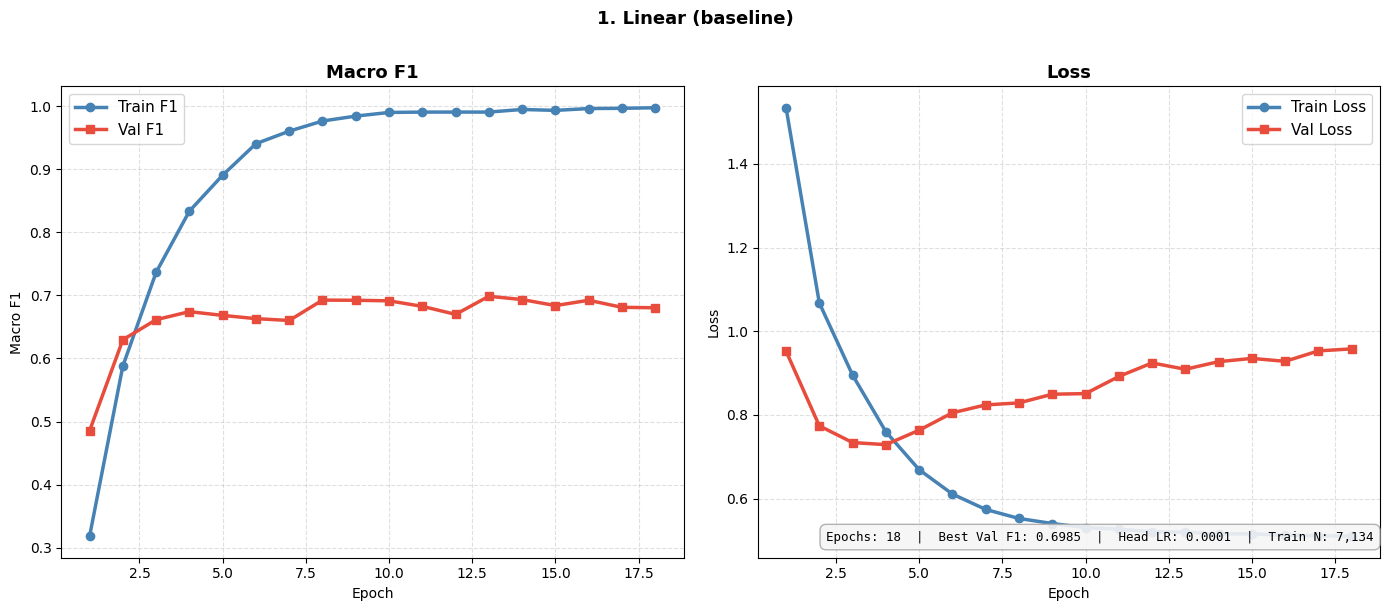

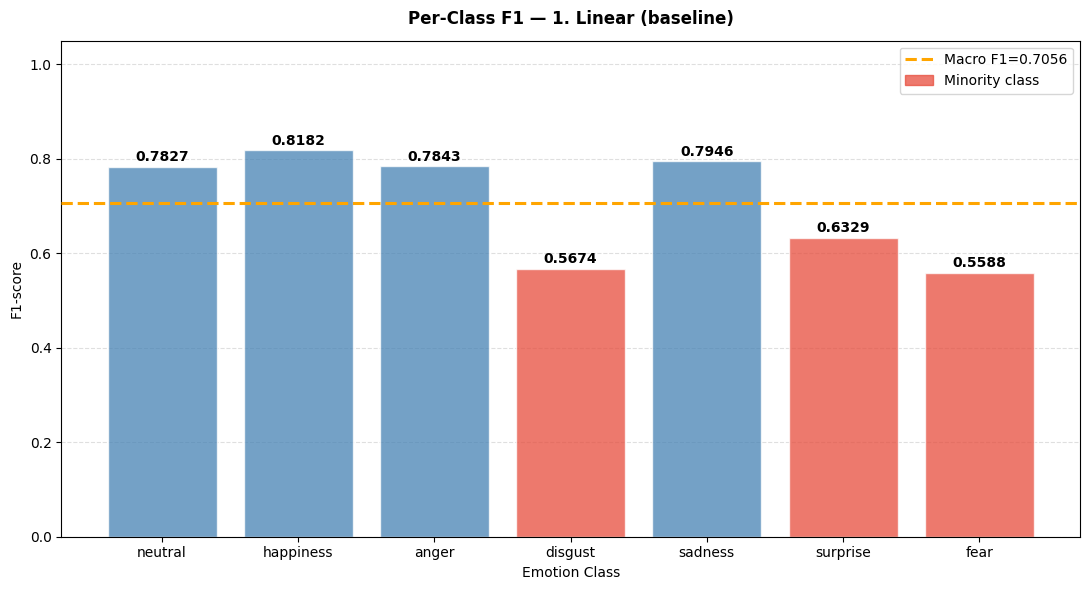

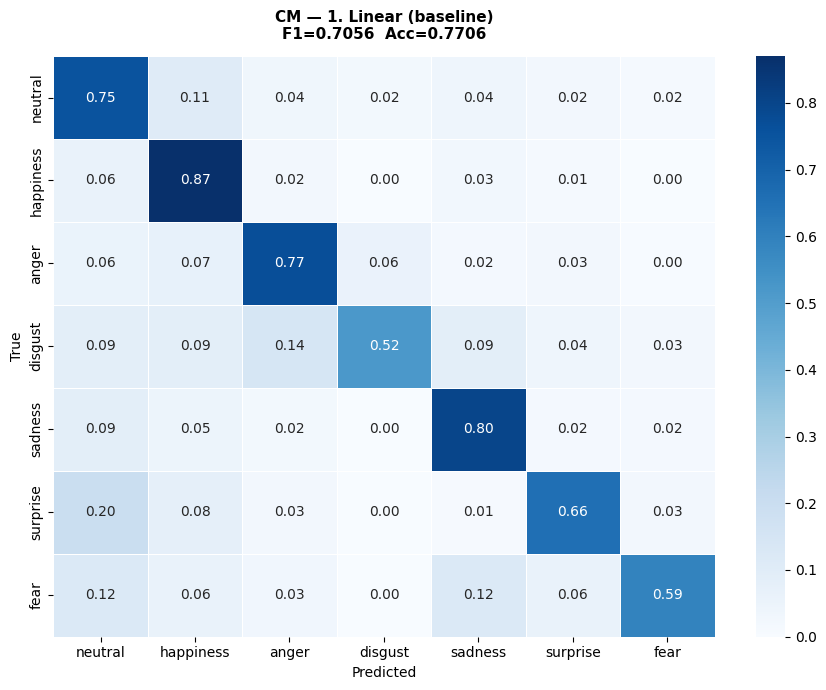

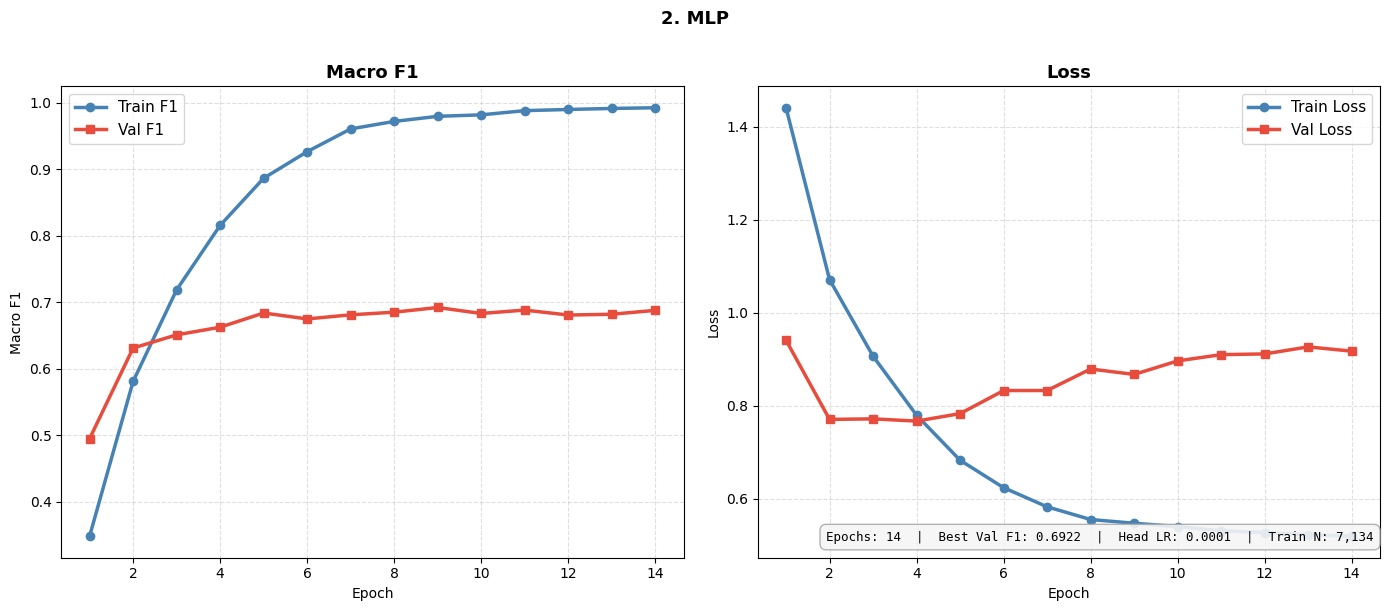

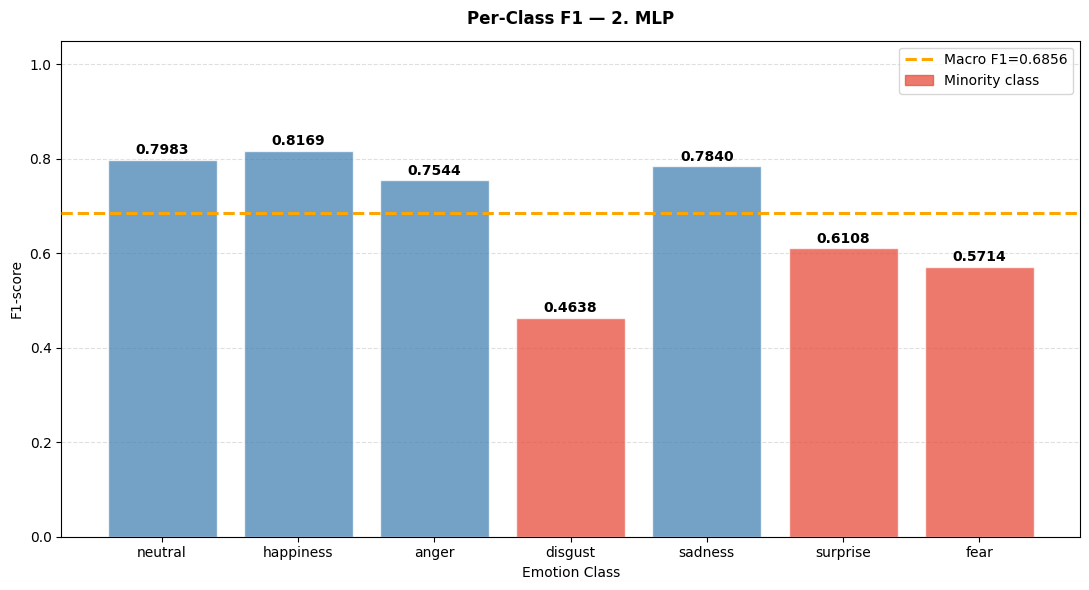

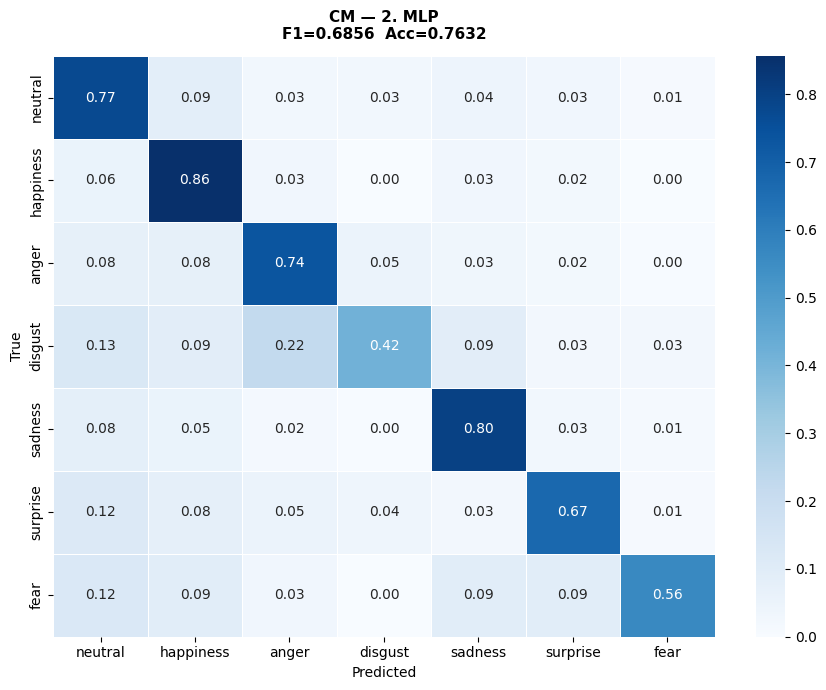

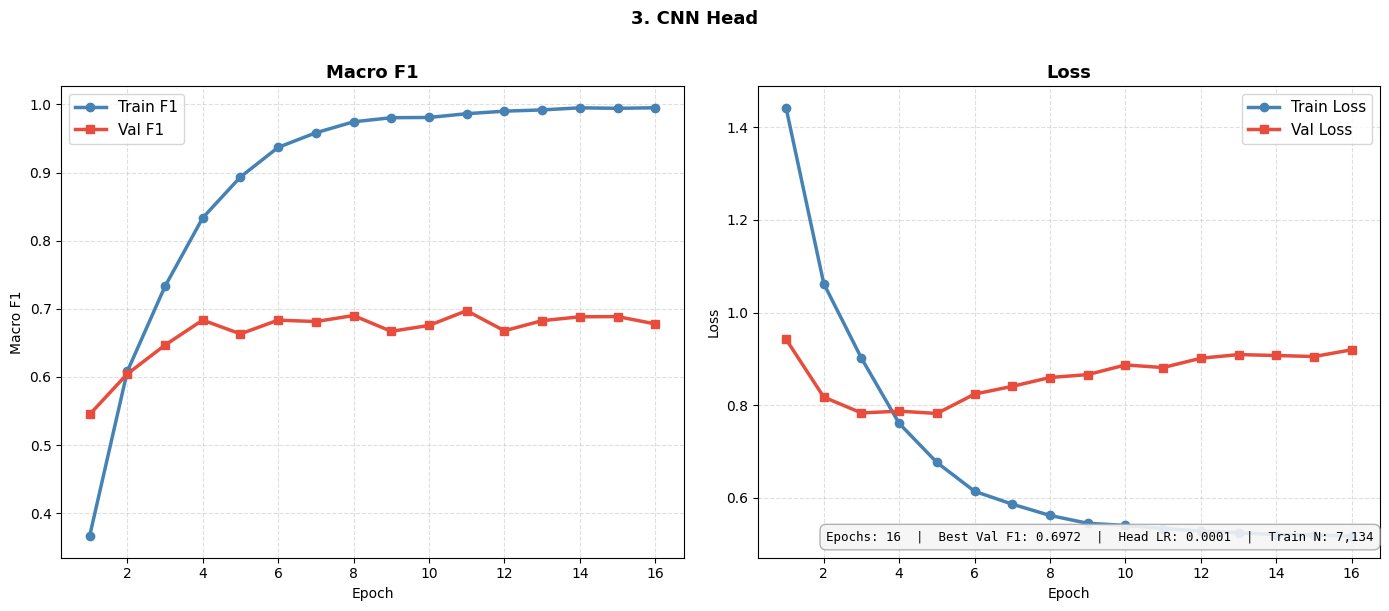

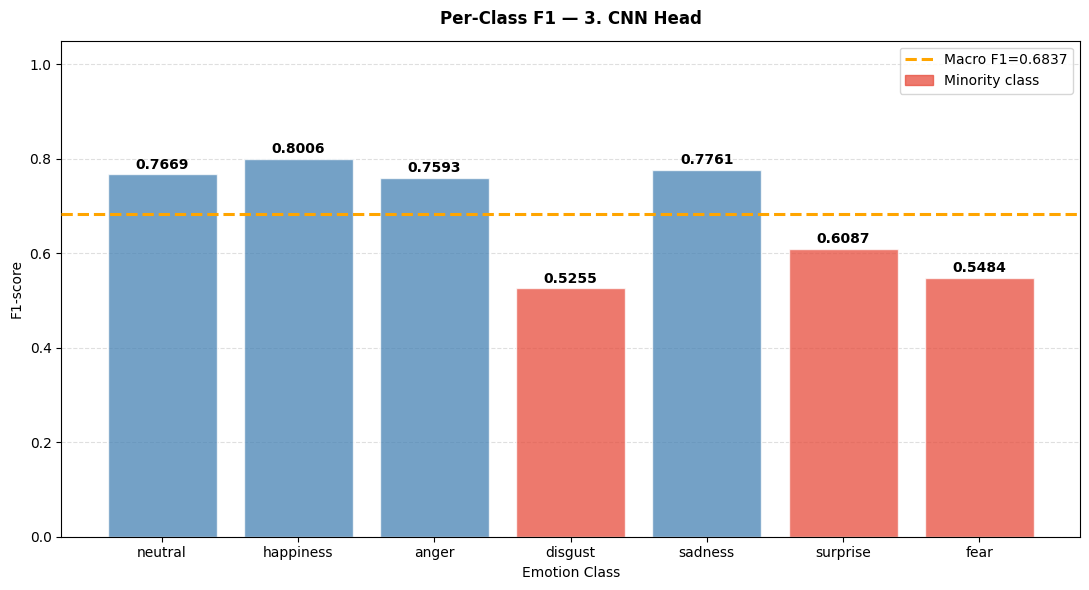

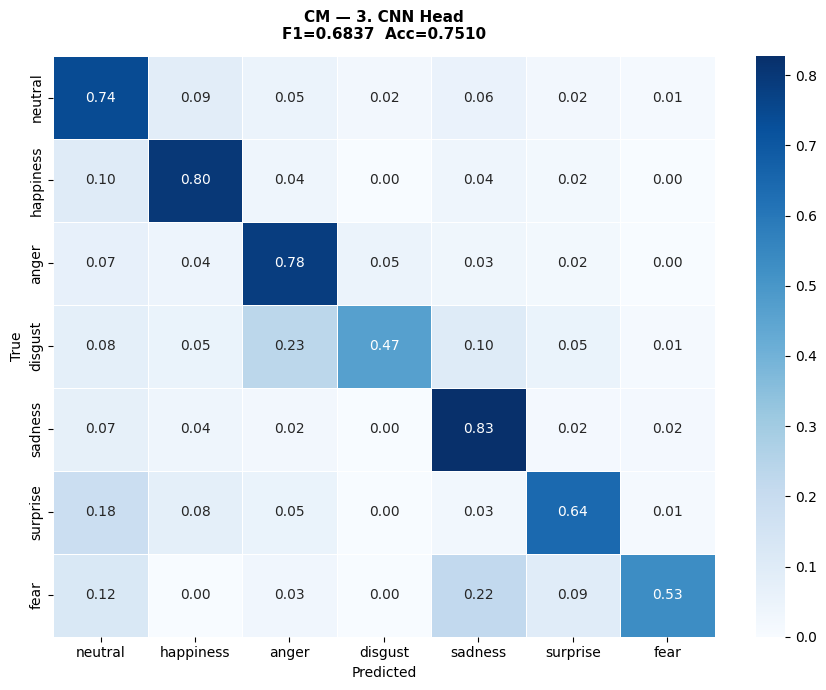

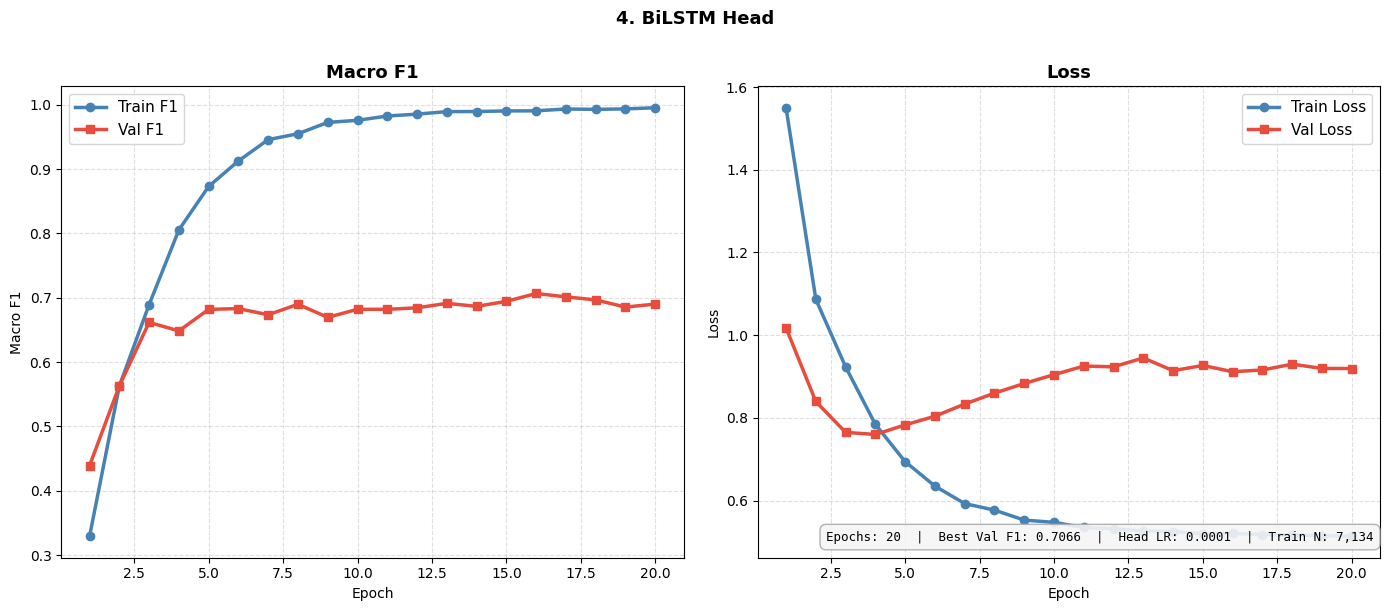

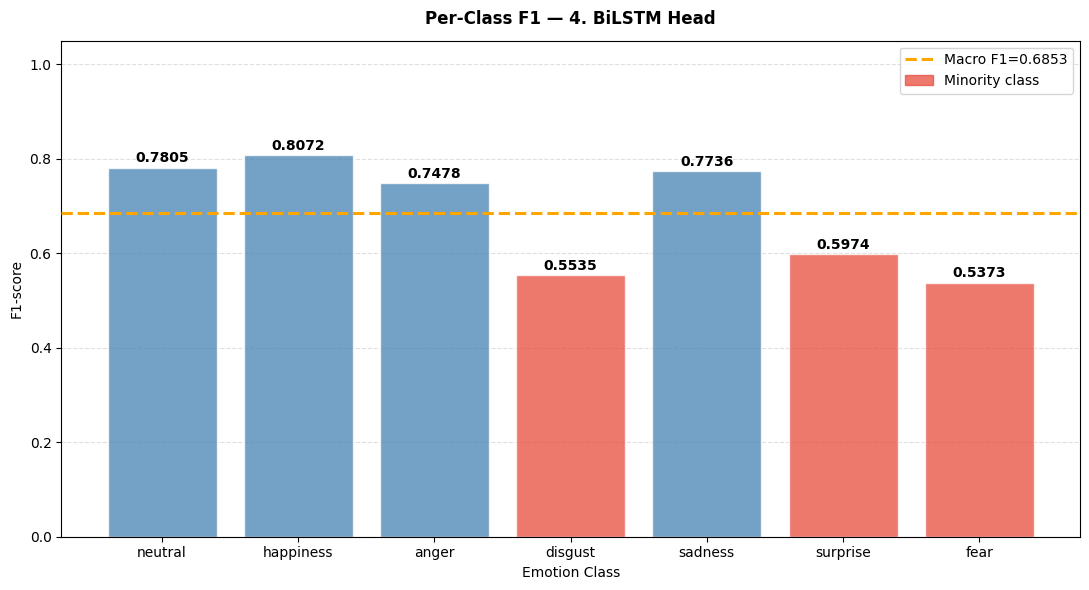

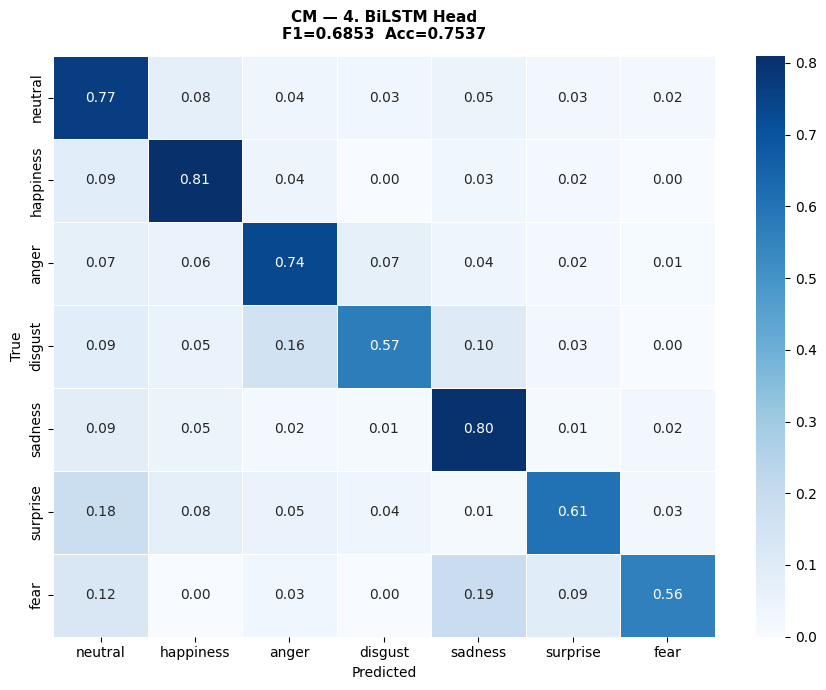

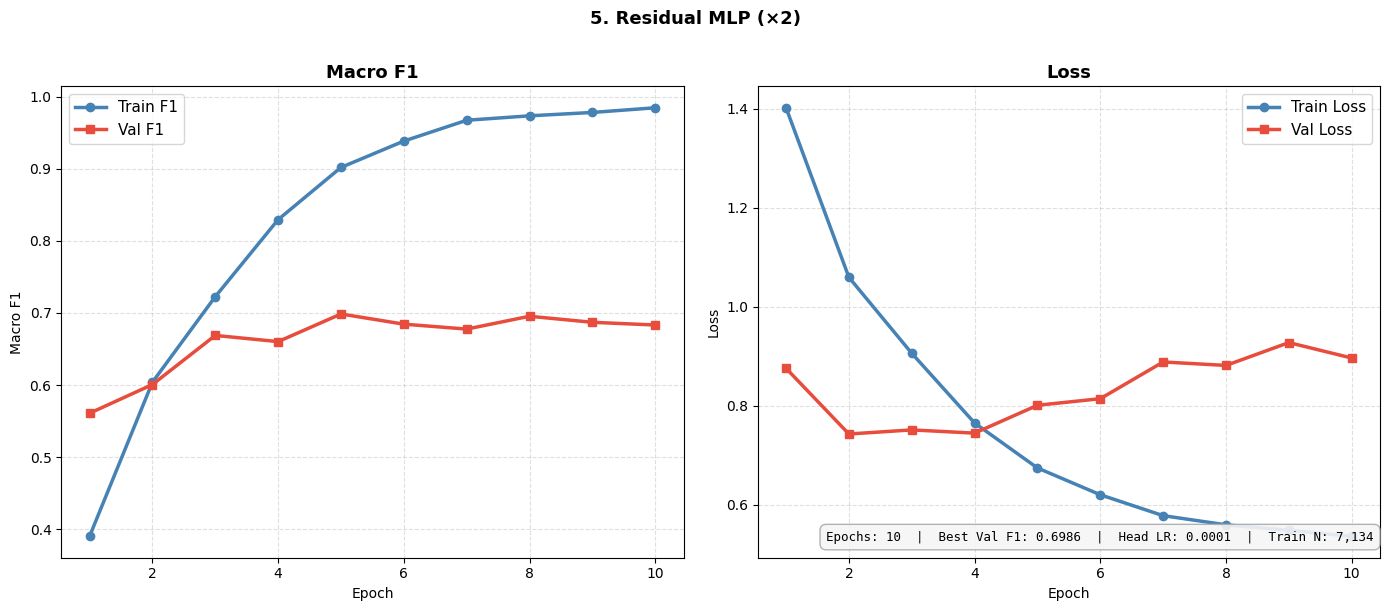

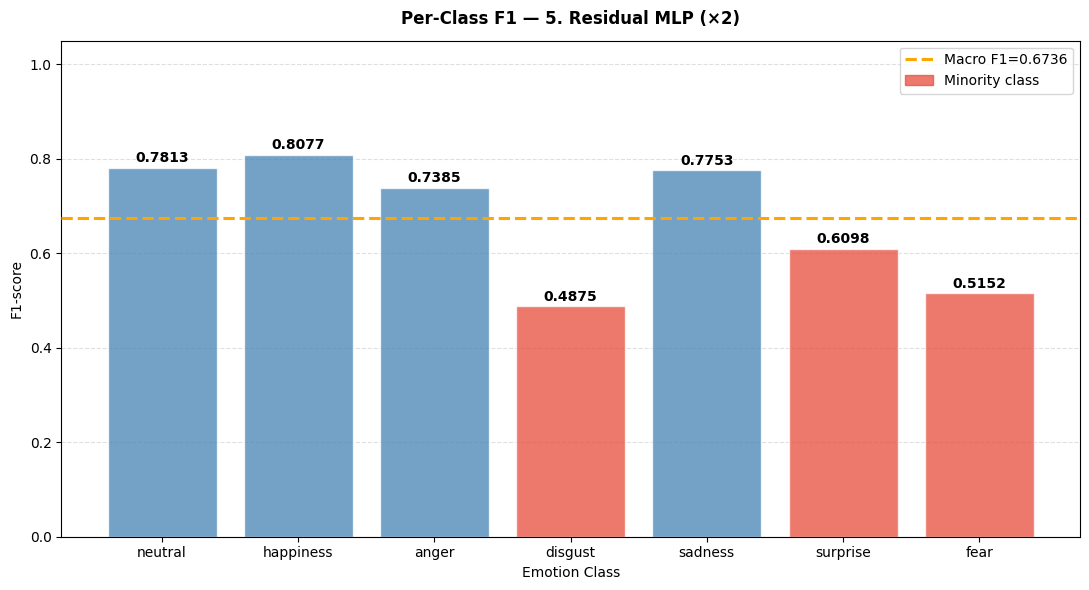

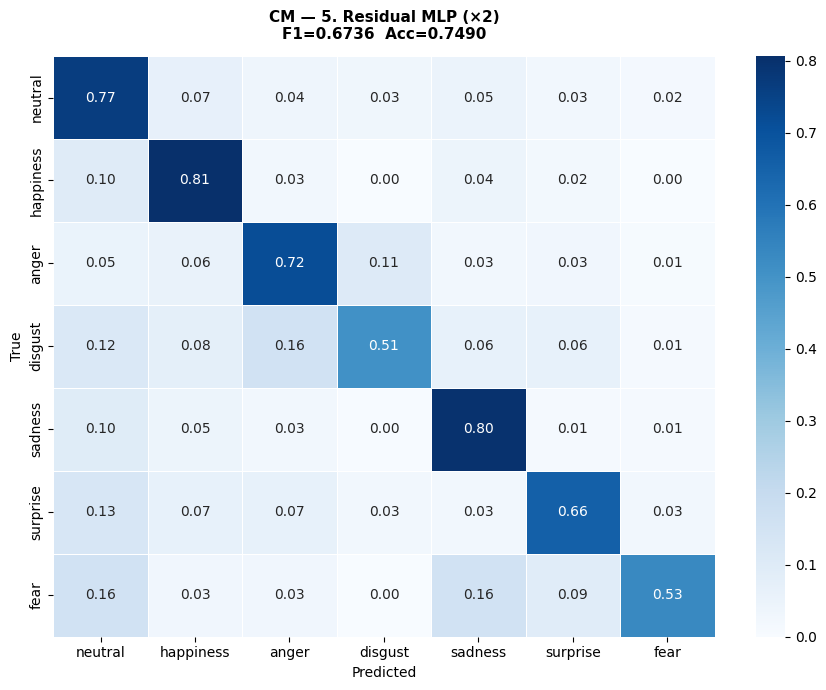

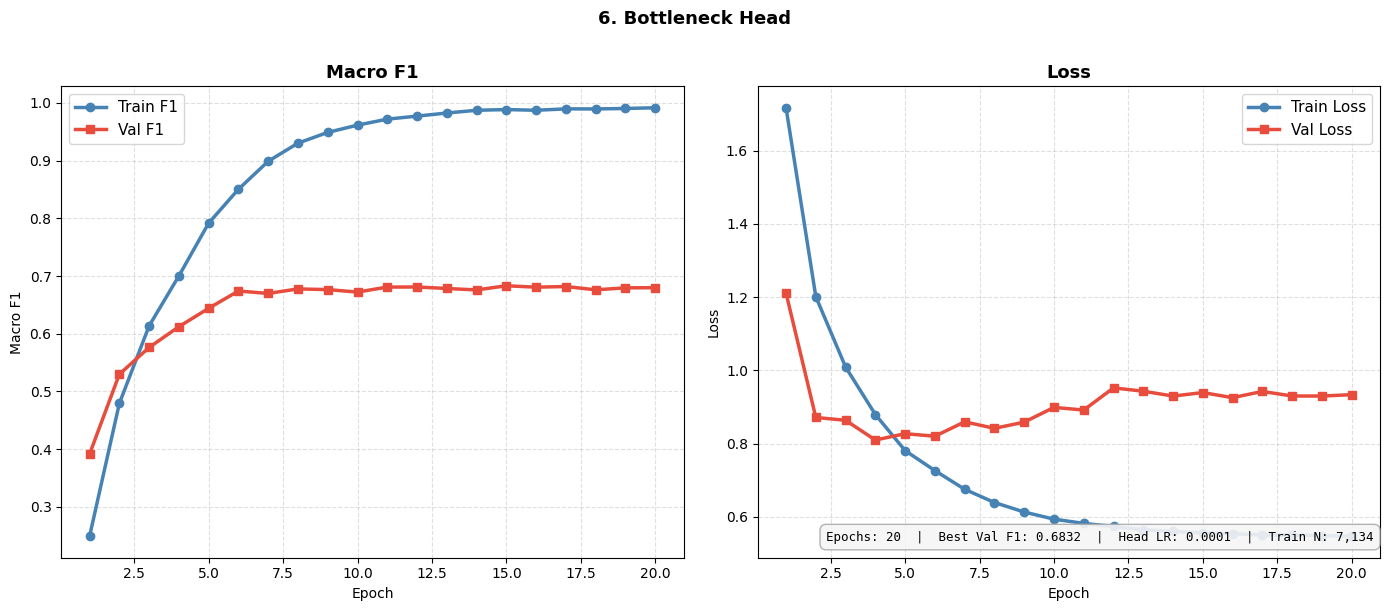

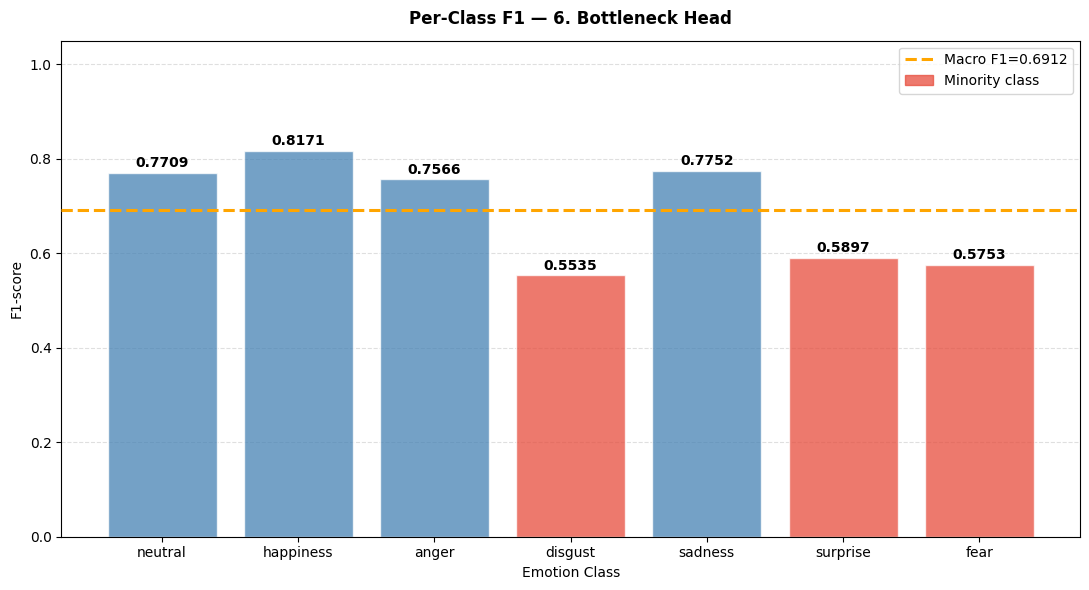

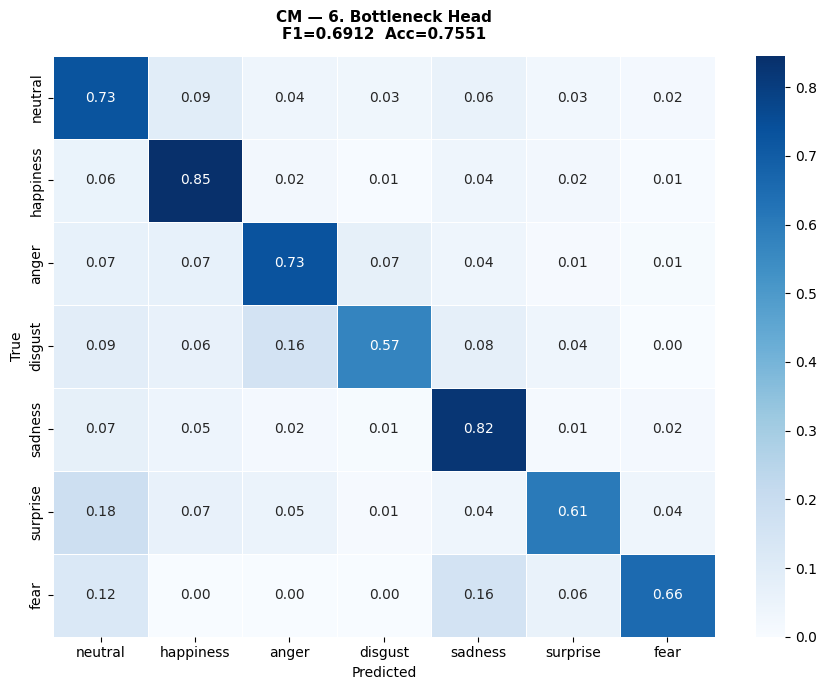

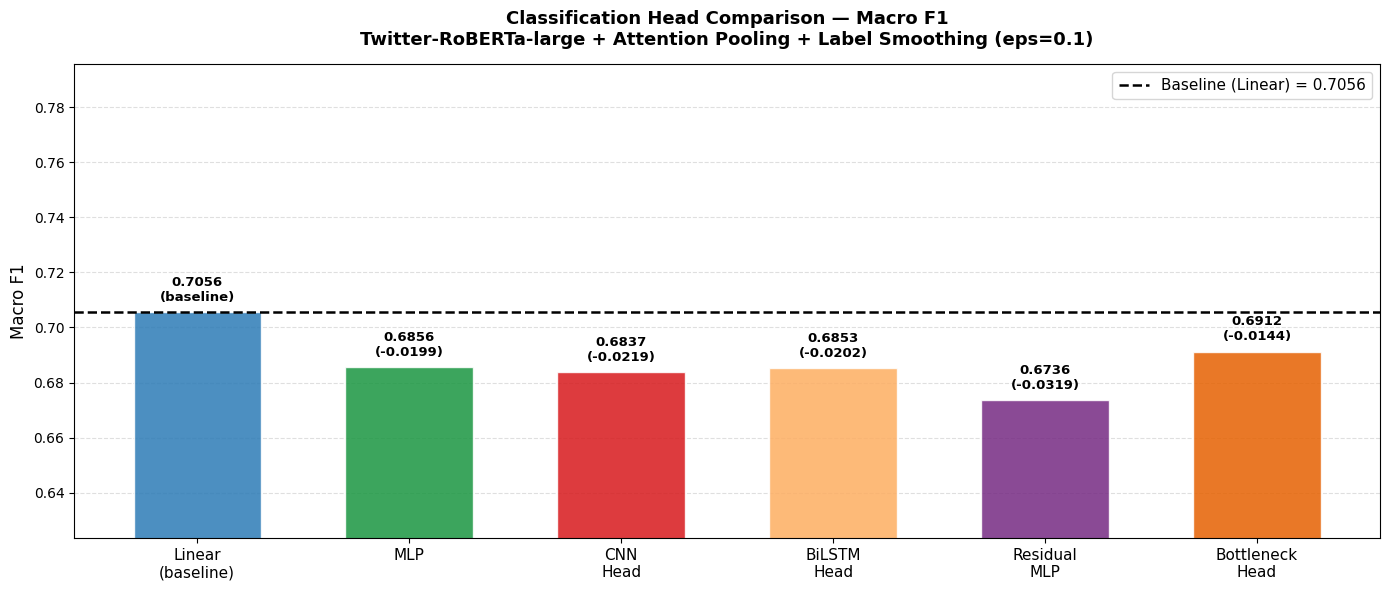

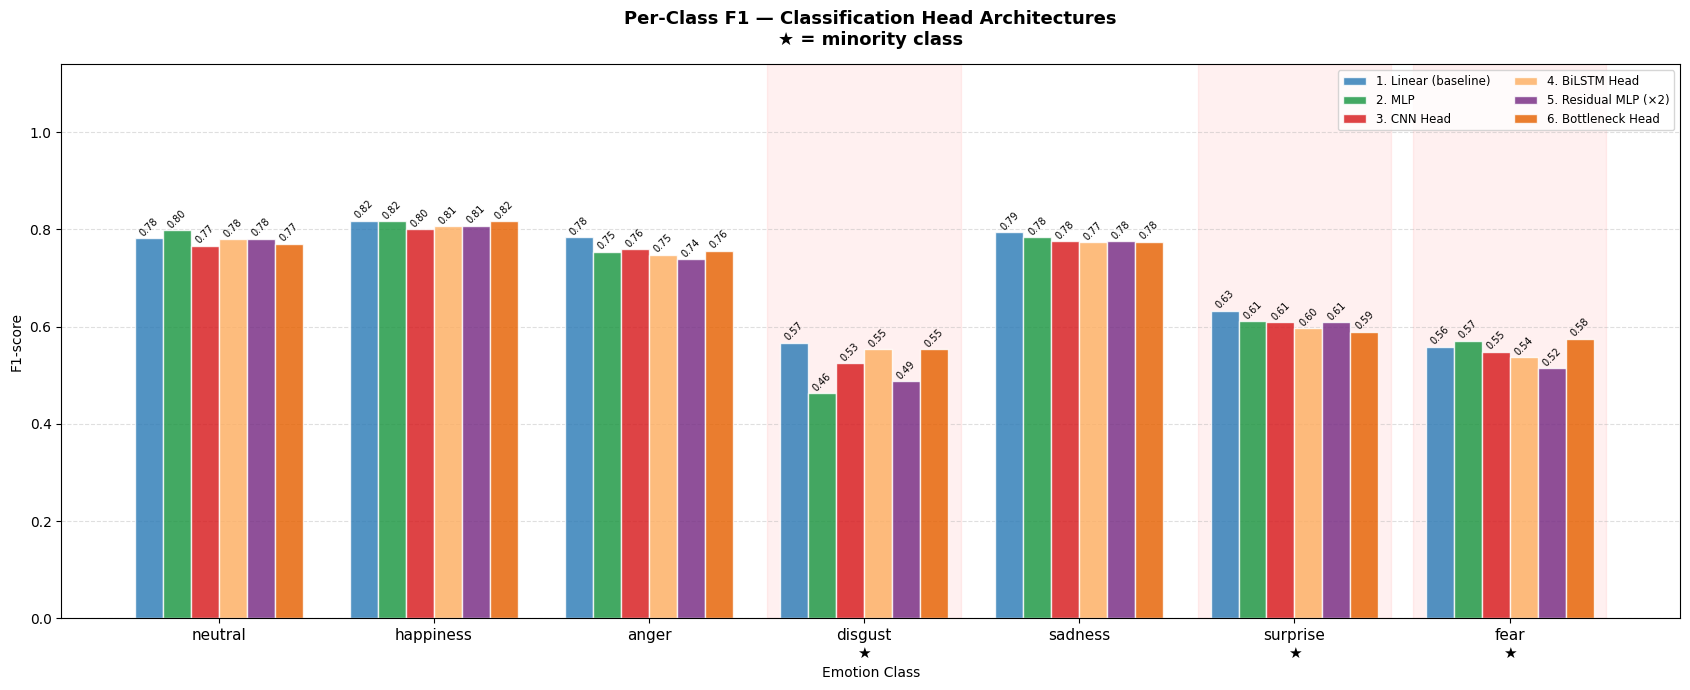

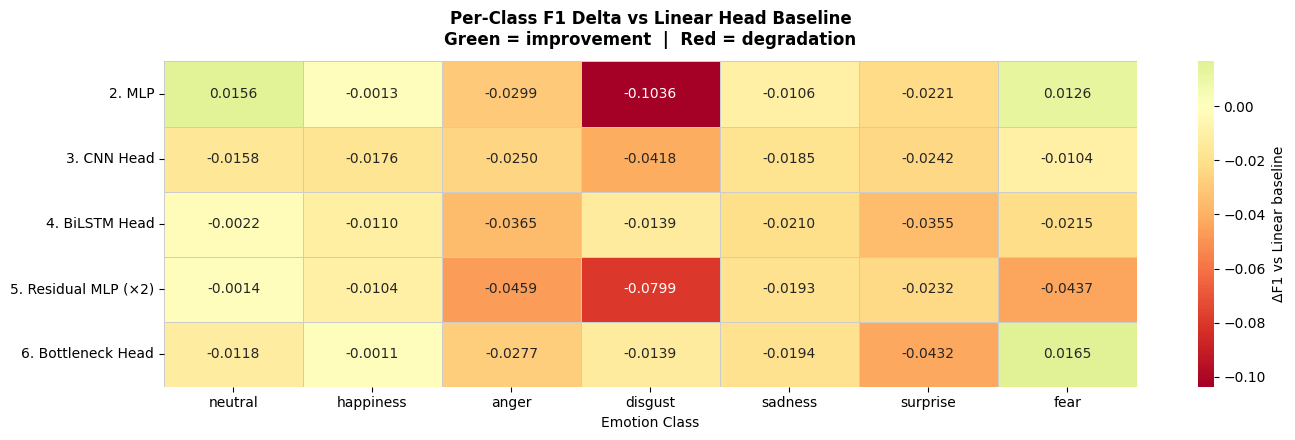


  HEAD ARCHITECTURE COMPARISON — Twitter-RoBERTa-large + Attention Pool + LS

                      Head LR Pooling  Epochs  Accuracy  Macro P  Macro R  Macro F1  Weighted F1  Val F1 Δ Macro F1
Method                                                                                                             
1. Linear (baseline)   0.0001    Attn      18    0.7706   0.7056   0.7090    0.7056       0.7697  0.6985    +0.0000
2. MLP                 0.0001    Attn      14    0.7632   0.6878   0.6877    0.6856       0.7619  0.6922    -0.0199
3. CNN Head            0.0001  bypass      16    0.7510   0.6869   0.6848    0.6837       0.7499  0.6972    -0.0219
4. BiLSTM Head         0.0001  bypass      20    0.7537   0.6789   0.6927    0.6853       0.7544  0.7066    -0.0202
5. Residual MLP (×2)   0.0001    Attn      10    0.7490   0.6654   0.6836    0.6736       0.7503  0.6986    -0.0319
6. Bottleneck Head     0.0001    Attn      20    0.7551   0.6788   0.7085    0.6912       0.7558  0.6832    -

In [14]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import re
import random
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy

# ============================================================
# КОНФИГУРАЦИЯ
# ============================================================

ROBERTA_NAME    = "cardiffnlp/twitter-roberta-large-emotion-latest"
MAX_LEN         = 128
BATCH_SIZE      = 64           # ← было 32
EPOCHS          = 20
ENCODER_LR      = 1e-5         # ← было 2e-5 (поднято под больший batch)
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
PATIENCE        = 5
SEED            = 42

# DataLoader
NUM_WORKERS     = 4
PIN_MEMORY      = True

# Mixed precision (FP16 для V100 — нативная поддержка через Tensor Cores)
USE_AMP         = True
AMP_DTYPE       = torch.float16

emotion_classes  = ["neutral", "happiness", "anger", "disgust", "sadness", "surprise", "fear"]
CLASS_TO_ID      = {cls: i for i, cls in enumerate(emotion_classes)}
MINORITY_CLASSES = ["fear", "disgust", "surprise"]

SPLITS_DIR = "splits"
OUTPUT_DIR = "head_experiments"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"AMP: {USE_AMP}  |  dtype: {AMP_DTYPE}  |  Batch: {BATCH_SIZE}  |  Encoder LR: {ENCODER_LR}")

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

# ============================================================
# ЛОСС
# ============================================================

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_prob  = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            dist = torch.full_like(log_prob, self.smoothing / (n_classes - 1))
            dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(dist * log_prob).sum(dim=-1).mean()

# ============================================================
# ATTENTION POOLING
# ============================================================

class AttentionPooling(nn.Module):
    """
    Bahdanau-style attention pooling.
    attention_dim = H/4 — стандартное соотношение.
    Маскирование через -1e4 — безопасно для FP16
    (-1e9 переполнило бы FP16, диапазон ±65504).
    """
    def __init__(self, hidden_size):
        super().__init__()
        attention_dim  = hidden_size // 4
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, attention_dim),
            nn.Tanh(),
            nn.Linear(attention_dim, 1),
        )

    def forward(self, hidden_states, attention_mask):
        scores  = self.attention(hidden_states)                       # [B, T, 1]
        scores  = scores.masked_fill(
            attention_mask.unsqueeze(-1) == 0, -1e4)                  # FP16-safe
        weights = torch.softmax(scores, dim=1)                        # [B, T, 1]
        return (hidden_states * weights).sum(dim=1)                   # [B, H]


# ============================================================
# 6 АРХИТЕКТУР ГОЛОВ
# ============================================================

class RobertaLinearHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = True

    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling    = AttentionPooling(H)
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(H, num_labels)

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        pooled = self.pooling(seq, attention_mask)
        return self.classifier(self.dropout(pooled))

    def head_parameters(self):
        return list(self.pooling.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())


class RobertaMLPHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = True

    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling = AttentionPooling(H)
        self.head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(H, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_labels),
        )

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        pooled = self.pooling(seq, attention_mask)
        return self.head(pooled)

    def head_parameters(self):
        return list(self.pooling.parameters()) + list(self.head.parameters())


class RobertaCNNHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = False

    def __init__(self, model_name, num_labels,
                 num_filters=128, kernel_sizes=(2, 3, 4)):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size

        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=H, out_channels=num_filters,
                      kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(num_filters * len(kernel_sizes), num_labels)

    def forward(self, input_ids, attention_mask):
        seq   = self.backbone(input_ids=input_ids,
                              attention_mask=attention_mask).last_hidden_state
        seq_t = seq.permute(0, 2, 1)
        mask_t = attention_mask.unsqueeze(1).to(seq_t.dtype)
        seq_t  = seq_t * mask_t

        pooled_list = []
        for conv in self.convs:
            x = F.gelu(conv(seq_t))
            x = F.adaptive_max_pool1d(x, 1).squeeze(-1)
            pooled_list.append(x)

        cat = torch.cat(pooled_list, dim=1)
        return self.classifier(self.dropout(cat))

    def head_parameters(self):
        return list(self.convs.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())


class RobertaBiLSTMHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = False

    def __init__(self, model_name, num_labels, lstm_hidden=256):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.lstm = nn.LSTM(
            input_size    = H,
            hidden_size   = lstm_hidden,
            num_layers    = 1,
            bidirectional = True,
            batch_first   = True,
        )
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(lstm_hidden * 2, num_labels)

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        # LSTM безопаснее держать в FP32 (cuDNN bias to FP16 иногда нестабилен)
        with autocast('cuda', enabled=False):
            seq_fp32 = seq.float()
            out, _   = self.lstm(seq_fp32)

        mask = attention_mask.unsqueeze(-1).to(out.dtype)
        pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        return self.classifier(self.dropout(pooled))

    def head_parameters(self):
        return list(self.lstm.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())


class RobertaResidualMLPHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = True

    def __init__(self, model_name, num_labels, n_blocks=2):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling     = AttentionPooling(H)
        self.input_drop  = nn.Dropout(0.2)

        self.blocks = nn.ModuleList([
            nn.ModuleDict({
                "norm":     nn.LayerNorm(H),
                "linear1":  nn.Linear(H, H),
                "linear2":  nn.Linear(H, H),
                "dropout":  nn.Dropout(0.2),
            })
            for _ in range(n_blocks)
        ])

        self.final_norm  = nn.LayerNorm(H)
        self.classifier  = nn.Linear(H, num_labels)

    def _block_forward(self, x, block):
        h = block["norm"](x)
        h = block["linear1"](h)
        h = F.gelu(h)
        h = block["dropout"](h)
        h = block["linear2"](h)
        return x + h

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        x      = self.pooling(seq, attention_mask)
        x      = self.input_drop(x)
        for block in self.blocks:
            x = self._block_forward(x, block)
        x = self.final_norm(x)
        return self.classifier(x)

    def head_parameters(self):
        return list(self.pooling.parameters()) + \
               list(self.input_drop.parameters()) + \
               list(self.blocks.parameters()) + \
               list(self.final_norm.parameters()) + \
               list(self.classifier.parameters())


class RobertaBottleneckHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = True

    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling = AttentionPooling(H)
        self.head = nn.Sequential(
            nn.LayerNorm(H),
            nn.Dropout(0.2),
            nn.Linear(H, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_labels),
        )

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        pooled = self.pooling(seq, attention_mask)
        return self.head(pooled)

    def head_parameters(self):
        return list(self.pooling.parameters()) + list(self.head.parameters())


# ============================================================
# OPTIMIZER (без изменений)
# ============================================================

def build_optimizer(model, encoder_lr, head_lr, weight_decay):
    encoder_params = list(model.backbone.parameters())
    head_params    = model.head_parameters()
    no_decay = ("bias", "LayerNorm.weight", "layer_norm.weight")

    def split_decay(params, lr):
        decay, no_dec = [], []
        for n, p in params:
            if any(nd in n for nd in no_decay):
                no_dec.append(p)
            else:
                decay.append(p)
        return [
            {"params": decay,  "lr": lr, "weight_decay": weight_decay},
            {"params": no_dec, "lr": lr, "weight_decay": 0.0},
        ]

    encoder_named = list(model.backbone.named_parameters())
    head_named    = [(f"head.{i}", p) for i, p in enumerate(head_params)]

    groups = split_decay(encoder_named, encoder_lr) + \
             split_decay(head_named,    head_lr)

    return torch.optim.AdamW(groups, eps=1e-6)


# ============================================================
# TRAIN / EVAL — с FP16 autocast
# ============================================================

def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
            loss   = criterion(logits, labs)

        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).detach().cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    ce = nn.CrossEntropyLoss()
    for batch in tqdm(loader, desc="  eval", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)

        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)

        # Loss и softmax считаем в FP32 для численной устойчивости метрик
        logits_fp32 = logits.float()
        total_loss += ce(logits_fp32, labs).item()
        probs = torch.softmax(logits_fp32, 1).cpu().numpy()
        all_preds.extend(probs.argmax(1))
        all_labels.extend(labs.cpu().numpy())
    return (total_loss / len(loader),
            f1_score(all_labels, all_preds, average="macro"),
            np.array(all_preds), np.array(all_labels))

# ============================================================
# УНИВЕРСАЛЬНЫЙ ЭКСПЕРИМЕНТ
# ============================================================

def run_experiment(model_class, display_name,
                   train_df, val_df, test_df, tokenizer):
    print(f"\n{'='*60}")
    print(f"  {display_name}")
    print(f"  Head LR: {model_class.HEAD_LR}  |  Encoder LR: {ENCODER_LR}")
    print(f"{'='*60}")

    set_seed(SEED)
    num_labels = len(emotion_classes)

    X_train, y_train = train_df["tweet_text"], train_df["label_id"]
    X_val,   y_val   = val_df["tweet_text"],   val_df["label_id"]
    X_test,  y_test  = test_df["tweet_text"],  test_df["label_id"]

    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)

    tr_loader = DataLoader(
        TweetDataset(X_train, y_train, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    va_loader = DataLoader(
        TweetDataset(X_val, y_val, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    te_loader = DataLoader(
        TweetDataset(X_test, y_test, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )

    set_seed(SEED)
    model     = model_class(ROBERTA_NAME, num_labels).to(device)
    optimizer = build_optimizer(model,
                                encoder_lr   = ENCODER_LR,
                                head_lr      = model_class.HEAD_LR,
                                weight_decay = WEIGHT_DECAY)
    total_steps = len(tr_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    scaler = GradScaler('cuda', enabled=USE_AMP)

    best_f1, patience_cnt, best_state = 0.0, 0, None
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_f1 = train_epoch(model, tr_loader, optimizer, scheduler, criterion, scaler)
        va_loss, va_f1, _, _ = evaluate(model, va_loader)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1);     history["val_f1"].append(va_f1)

        print(f"  Ep {ep}/{EPOCHS}  "
              f"trL={tr_loss:.4f} trF1={tr_f1:.4f}  "
              f"vaL={va_loss:.4f} vaF1={va_f1:.4f}", end="")

        if va_f1 > best_f1:
            best_f1, patience_cnt = va_f1, 0
            best_state = deepcopy(model.state_dict())
            print("  ✓")
        else:
            patience_cnt += 1
            print(f"  ⏳ {patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"  Early stop at epoch {ep}"); break

    model.load_state_dict(best_state)
    te_loss, te_f1, te_preds, te_labels = evaluate(model, te_loader)

    rep     = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4,
                                    output_dict=True)
    rep_str = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4)
    print(f"\n  Test loss={te_loss:.4f}  Macro F1={te_f1:.4f}")
    print(rep_str)

    # Освобождаем VRAM перед следующим экспериментом
    del model, optimizer, scheduler, scaler, best_state
    torch.cuda.empty_cache()

    result = {
        "variant":              display_name,
        "head_lr":              model_class.HEAD_LR,
        "uses_pooling":         model_class.USES_POOLING,
        "train_size":           len(X_train),
        "epochs_trained":       len(history["train_loss"]),
        "best_val_f1":          best_f1,
        "test_loss":            te_loss,
        "test_accuracy":        rep["accuracy"],
        "test_macro_precision": rep["macro avg"]["precision"],
        "test_macro_recall":    rep["macro avg"]["recall"],
        "test_macro_f1":        rep["macro avg"]["f1-score"],
        "test_weighted_f1":     rep["weighted avg"]["f1-score"],
        "history":              history,
        "report_dict":          rep,
        "test_preds":           te_preds,
        "test_labels":          te_labels,
    }
    for cls in emotion_classes:
        result[f"f1_{cls}"] = rep[cls]["f1-score"] if cls in rep else 0.0
    return result

# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================

loaders, meta = load_splits(splits_dir=SPLITS_DIR)
train_df  = meta["train_df"]
val_df    = meta["val_df"]
test_df   = meta["test_df"]
tokenizer = meta["tokenizer"]

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ============================================================
# ОПРЕДЕЛЕНИЕ ЭКСПЕРИМЕНТОВ
# ============================================================

experiments = [
    {"display_name": "1. Linear (baseline)",   "model_class": RobertaLinearHead},
    {"display_name": "2. MLP",                 "model_class": RobertaMLPHead},
    {"display_name": "3. CNN Head",            "model_class": RobertaCNNHead},
    {"display_name": "4. BiLSTM Head",         "model_class": RobertaBiLSTMHead},
    {"display_name": "5. Residual MLP (×2)",   "model_class": RobertaResidualMLPHead},
    {"display_name": "6. Bottleneck Head",     "model_class": RobertaBottleneckHead},
]

# ============================================================
# ЗАПУСК
# ============================================================

all_results = []
for exp in experiments:
    res = run_experiment(
        model_class  = exp["model_class"],
        display_name = exp["display_name"],
        train_df     = train_df,
        val_df       = val_df,
        test_df      = test_df,
        tokenizer    = tokenizer,
    )
    all_results.append(res)

# ============================================================
# ГРАФИКИ (без изменений — оставлены как были)
# ============================================================

plt.rcParams['font.family'] = 'DejaVu Sans'
PROPS_BOX  = dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5',
                  edgecolor='#aaaaaa', alpha=0.9)
EXP_COLORS = ['#2c7bb6', '#1a9641', '#d7191c', '#fdae61',
              '#762a83', '#e66101']


def plot_training_curves(result, output_dir):
    ep = range(1, len(result["history"]["train_f1"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('white')
    for ax in axes:
        ax.set_facecolor('white')
        ax.grid(True, ls='--', alpha=0.4, zorder=1)
        ax.set_axisbelow(True)
    axes[0].plot(ep, result["history"]["train_f1"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train F1", zorder=3)
    axes[0].plot(ep, result["history"]["val_f1"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val F1", zorder=3)
    axes[0].set_title("Macro F1", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Macro F1")
    axes[0].legend(fontsize=11)

    axes[1].plot(ep, result["history"]["train_loss"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train Loss", zorder=3)
    axes[1].plot(ep, result["history"]["val_loss"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val Loss", zorder=3)
    axes[1].set_title("Loss", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(fontsize=11)

    stats = (f"Epochs: {result['epochs_trained']}  |  "
             f"Best Val F1: {result['best_val_f1']:.4f}  |  "
             f"Head LR: {result['head_lr']}  |  "
             f"Train N: {result['train_size']:,}")
    axes[1].text(0.99, 0.03, stats, transform=axes[1].transAxes, fontsize=9,
                 va='bottom', ha='right', bbox=PROPS_BOX, family='monospace')

    plt.suptitle(result["variant"], fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"curves_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()


def plot_per_class_f1(result, output_dir):
    from matplotlib.patches import Patch
    rep = result["report_dict"]
    f1s = [rep[c]["f1-score"] if c in rep else 0 for c in emotion_classes]
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')

    colors = ["#e74c3c" if c in MINORITY_CLASSES else "steelblue"
              for c in emotion_classes]
    bars = ax.bar(emotion_classes, f1s, color=colors, alpha=0.75,
                  edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")

    ax.axhline(result["test_macro_f1"], color="#FFA500", ls="--", lw=2.2,
               zorder=3, label=f"Macro F1={result['test_macro_f1']:.4f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
    ax.set_title(f"Per-Class F1 — {result['variant']}",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
    ax.legend(handles=[
        plt.Line2D([0], [0], color="#FFA500", ls="--", lw=2.2,
                   label=f"Macro F1={result['test_macro_f1']:.4f}"),
        Patch(color='#e74c3c', alpha=0.75, label='Minority class'),
    ], fontsize=10)

    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"perclass_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()


def plot_confusion_matrix(result, output_dir):
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')
    cm   = confusion_matrix(result["test_labels"], result["test_preds"])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_classes, yticklabels=emotion_classes,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f"CM — {result['variant']}\n"
                 f"F1={result['test_macro_f1']:.4f}  "
                 f"Acc={result['test_accuracy']:.4f}",
                 fontsize=11, fontweight="bold", pad=12)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"cm_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()


for res in all_results:
    plot_training_curves(res, OUTPUT_DIR)
    plot_per_class_f1(res, OUTPUT_DIR)
    plot_confusion_matrix(res, OUTPUT_DIR)

# ---- Сравнительный Macro F1 ----
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

mf1s        = [r["test_macro_f1"] for r in all_results]
baseline_f1 = mf1s[0]
short_names = [
    "Linear\n(baseline)", "MLP", "CNN\nHead",
    "BiLSTM\nHead", "Residual\nMLP", "Bottleneck\nHead",
]

bars = ax.bar(range(len(all_results)), mf1s, color=EXP_COLORS,
              alpha=0.85, edgecolor='white', zorder=2, width=0.6)

for b, v in zip(bars, mf1s):
    delta = v - baseline_f1
    sign  = "+" if delta >= 0 else ""
    label = f"{v:.4f}\n({sign}{delta:.4f})" if delta != 0 else f"{v:.4f}\n(baseline)"
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.003,
            label, ha="center", fontsize=9.5, fontweight="bold", va='bottom')

ax.axhline(baseline_f1, color='black', ls='--', lw=1.8, zorder=3,
           label=f"Baseline (Linear) = {baseline_f1:.4f}")
ax.set_xticks(range(len(all_results)))
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_title("Classification Head Comparison — Macro F1\n"
             "Twitter-RoBERTa-large + Attention Pooling + Label Smoothing (eps=0.1)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylim(max(0, min(mf1s) - 0.05), min(1.0, max(mf1s) + 0.09))
ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_macro_f1.png"),
            dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ---- Per-Class F1 grouped ----
n_exp = len(all_results)
x = np.arange(len(emotion_classes))
w = 0.13

fig, ax = plt.subplots(figsize=(17, 7))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

for i, (r, color) in enumerate(zip(all_results, EXP_COLORS)):
    f1s    = [r.get(f"f1_{c}", 0) for c in emotion_classes]
    offset = (i - n_exp / 2 + 0.5) * w
    bars   = ax.bar(x + offset, f1s, w, label=r["variant"],
                    color=color, alpha=0.82, edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.004,
                f"{v:.2f}", ha="center", fontsize=7, rotation=45)

for i, cls in enumerate(emotion_classes):
    if cls in MINORITY_CLASSES:
        ax.axvspan(i - 0.45, i + 0.45, alpha=0.06, color='red', zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{c}\n★" if c in MINORITY_CLASSES else c for c in emotion_classes],
    fontsize=11)
ax.set_ylim(0, 1.14); ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
ax.set_title("Per-Class F1 — Classification Head Architectures\n★ = minority class",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=8.5, loc='upper right', ncol=2)
ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_per_class_f1.png"),
            dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ---- Delta heatmap ----
bl_pc = {cls: all_results[0].get(f"f1_{cls}", 0) for cls in emotion_classes}
delta_rows = [
    {"Method": r["variant"],
     **{c: round(r.get(f"f1_{c}", 0) - bl_pc[c], 4) for c in emotion_classes}}
    for r in all_results[1:]
]
delta_df = pd.DataFrame(delta_rows).set_index("Method")

fig, ax = plt.subplots(figsize=(14, 4.5))
fig.patch.set_facecolor('white')
sns.heatmap(delta_df, annot=True, fmt=".4f", cmap="RdYlGn", center=0,
            linewidths=0.6, linecolor='#cccccc', ax=ax,
            cbar_kws={"label": "ΔF1 vs Linear baseline"},
            annot_kws={"size": 10})
ax.set_title("Per-Class F1 Delta vs Linear Head Baseline\n"
             "Green = improvement  |  Red = degradation",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Emotion Class"); ax.set_ylabel("")
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "delta_heatmap.png"),
            dpi=150, bbox_inches="tight", facecolor='white')
plt.show()

# ============================================================
# ИТОГОВЫЕ ТАБЛИЦЫ
# ============================================================

print(f"\n{'='*120}")
print("  HEAD ARCHITECTURE COMPARISON — Twitter-RoBERTa-large + Attention Pool + LS")
print(f"{'='*120}\n")

rows = []
for r in all_results:
    delta = r["test_macro_f1"] - all_results[0]["test_macro_f1"]
    rows.append({
        "Method":      r["variant"],
        "Head LR":     r["head_lr"],
        "Pooling":     "Attn" if r["uses_pooling"] else "bypass",
        "Epochs":      r["epochs_trained"],
        "Accuracy":    round(r["test_accuracy"], 4),
        "Macro P":     round(r["test_macro_precision"], 4),
        "Macro R":     round(r["test_macro_recall"], 4),
        "Macro F1":    round(r["test_macro_f1"], 4),
        "Weighted F1": round(r["test_weighted_f1"], 4),
        "Val F1":      round(r["best_val_f1"], 4),
        "Δ Macro F1":  f"{'+' if delta >= 0 else ''}{delta:.4f}",
    })

summary_df = pd.DataFrame(rows).set_index("Method")
print(summary_df.to_string())

print(f"\n{'='*120}")
print("  PER-CLASS F1")
print(f"{'='*120}\n")

pc_rows = [{"Method": r["variant"],
            **{c: round(r.get(f"f1_{c}", 0), 4) for c in emotion_classes}}
           for r in all_results]
pc_df = pd.DataFrame(pc_rows).set_index("Method")
print(pc_df.to_string())

print(f"\n{'='*120}")
print("  PER-CLASS DELTA vs LINEAR BASELINE")
print(f"{'='*120}\n")
print(delta_df.to_string())

# Сохранение
summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"))
pc_df.to_csv(os.path.join(OUTPUT_DIR, "per_class_f1.csv"))
delta_df.to_csv(os.path.join(OUTPUT_DIR, "delta_per_class_f1.csv"))

best_idx = int(np.argmax([r["test_macro_f1"] for r in all_results]))
print(f"\n🏆 Best head: {all_results[best_idx]['variant']}")
print(f"   Macro F1  = {all_results[best_idx]['test_macro_f1']:.4f}")
print(f"   Δ vs Linear = "
      f"{all_results[best_idx]['test_macro_f1'] - all_results[0]['test_macro_f1']:+.4f}")
print(f"\nSaved to: {OUTPUT_DIR}/")

Device: cuda
AMP: True  |  dtype: torch.float16  |  Batch: 64  |  Encoder LR: 1e-05
Splits loaded from: splits/
  Train: 7134 | Val: 1260 | Test: 1482

  Train samples per class:
    id=0  neutral     :  2313
    id=1  happiness   :  1745
    id=2  anger       :  1129
    id=3  disgust     :   368
    id=4  sadness     :  1057
    id=5  surprise    :   368
    id=6  fear        :   154
Train: 7134 | Val: 1260 | Test: 1482

  Linear (baseline)
  Head LR: 2e-05  |  Encoder LR: 1e-05


Loading weights: 100%|████████████████████████████████████████████████████████| 389/389 [00:00<00:00, 5028.41it/s]
RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-large-emotion-latest
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
                                                                                                                  

  Ep 1/20  trL=1.5637 trF1=0.3061  vaL=0.9707 vaF1=0.4738  ✓


  Ep 2/20  trL=1.0751 trF1=0.5759  vaL=0.7810 vaF1=0.6342  ✓


  Ep 3/20  trL=0.9001 trF1=0.7291  vaL=0.7361 vaF1=0.6545  ✓


...

  Ep 16/20  trL=0.5132 trF1=0.9958  vaL=0.9137 vaF1=0.6905  ⏳ 2/5


  Ep 17/20  trL=0.5149 trF1=0.9945  vaL=0.9291 vaF1=0.6810  ⏳ 3/5


  Ep 18/20  trL=0.5118 trF1=0.9970  vaL=0.9345 vaF1=0.6917  ⏳ 4/5


  Ep 19/20  trL=0.5117 trF1=0.9977  vaL=0.9231 vaF1=0.6735  ⏳ 5/5
  Early stop at epoch 19



  Test loss=0.9028  Macro F1=0.7077
              precision    recall  f1-score   support

     neutral     0.8092    0.7672    0.7876       481
   happiness     0.7911    0.8370    0.8134       362
       anger     0.8113    0.7350    0.7713       234
     disgust     0.6000    0.6234    0.6115        77
     sadness     0.7783    0.7818    0.7800       220
    surprise     0.5714    0.6316    0.6000        76
        fear     0.5000    0.7188    0.5897        32

    accuracy                         0.7659      1482
   macro avg     0.6945    0.7278    0.7077      1482
weighted avg     0.7708    0.7659    0.7672      1482



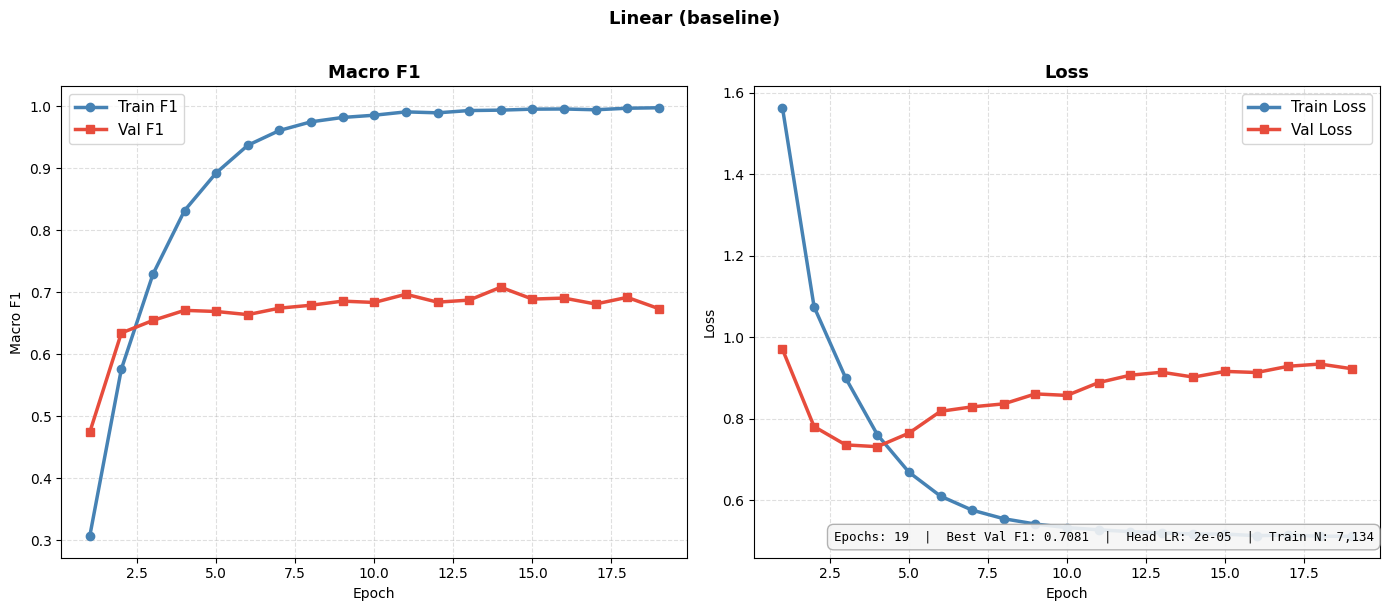

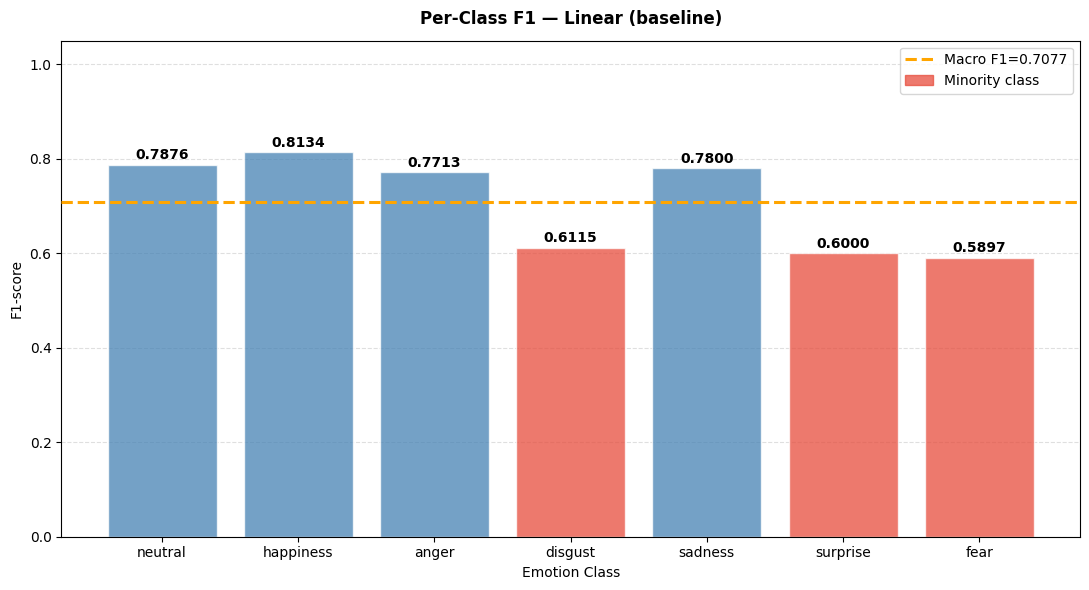

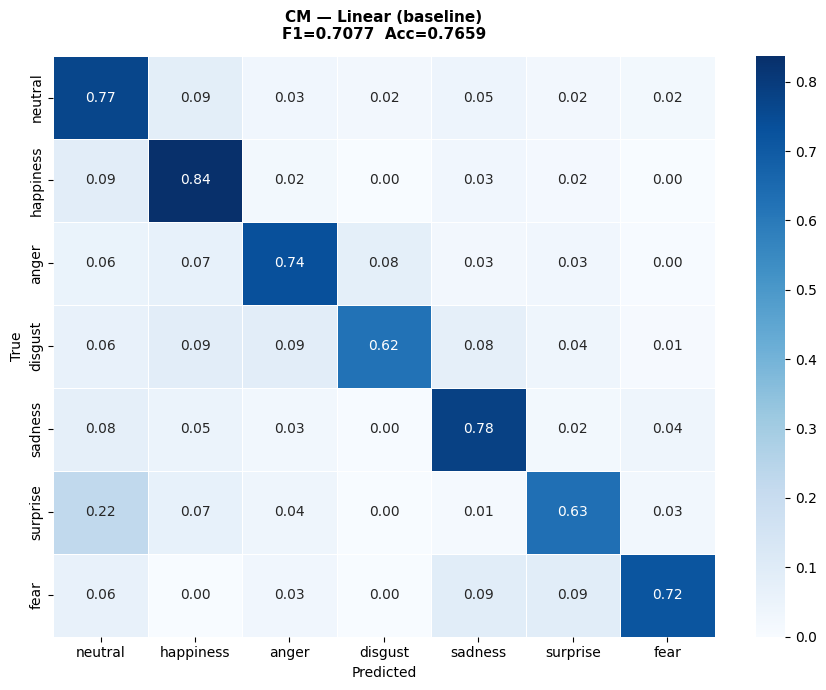


  LINEAR HEAD — Twitter-RoBERTa-large + Attention Pool + LS

                   Head LR Pooling  Epochs  Accuracy  Macro P  Macro R  Macro F1  Weighted F1  Val F1
Method                                                                                               
Linear (baseline)  0.00002    Attn      19    0.7659   0.6945   0.7278    0.7077       0.7672  0.7081

  PER-CLASS F1

                   neutral  happiness   anger  disgust  sadness  surprise    fear
Method                                                                           
Linear (baseline)   0.7876     0.8134  0.7713   0.6115     0.78       0.6  0.5897

🏆 Linear head Macro F1 = 0.7077

Saved to: linear_only/


In [8]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import re
import random
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
 
# ============================================================
# КОНФИГУРАЦИЯ
# ============================================================
 
ROBERTA_NAME    = "cardiffnlp/twitter-roberta-large-emotion-latest"
MAX_LEN         = 128
BATCH_SIZE      = 64
EPOCHS          = 20
ENCODER_LR      = 1e-5
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
PATIENCE        = 5
SEED            = 42
 
# DataLoader
NUM_WORKERS     = 4
PIN_MEMORY      = True
 
# Mixed precision (FP16 для V100 — нативная поддержка через Tensor Cores)
USE_AMP         = True
AMP_DTYPE       = torch.float16
 
emotion_classes  = ["neutral", "happiness", "anger", "disgust", "sadness", "surprise", "fear"]
CLASS_TO_ID      = {cls: i for i, cls in enumerate(emotion_classes)}
MINORITY_CLASSES = ["fear", "disgust", "surprise"]
 
SPLITS_DIR = "splits"
OUTPUT_DIR = "linear_only"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"AMP: {USE_AMP}  |  dtype: {AMP_DTYPE}  |  Batch: {BATCH_SIZE}  |  Encoder LR: {ENCODER_LR}")
 
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
 
# ============================================================
# ЛОСС
# ============================================================
 
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
 
    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_prob  = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            dist = torch.full_like(log_prob, self.smoothing / (n_classes - 1))
            dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(dist * log_prob).sum(dim=-1).mean()
 
# ============================================================
# ATTENTION POOLING
# ============================================================
 
class AttentionPooling(nn.Module):
    """
    Bahdanau-style attention pooling.
    attention_dim = H/4 — стандартное соотношение.
    Маскирование через -1e4 — безопасно для FP16
    (-1e9 переполнило бы FP16, диапазон ±65504).
    """
    def __init__(self, hidden_size):
        super().__init__()
        attention_dim  = hidden_size // 4
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, attention_dim),
            nn.Tanh(),
            nn.Linear(attention_dim, 1),
        )
 
    def forward(self, hidden_states, attention_mask):
        scores  = self.attention(hidden_states)                       # [B, T, 1]
        scores  = scores.masked_fill(
            attention_mask.unsqueeze(-1) == 0, -1e4)                  # FP16-safe
        weights = torch.softmax(scores, dim=1)                        # [B, T, 1]
        return (hidden_states * weights).sum(dim=1)                   # [B, H]
 
 
# ============================================================
# LINEAR HEAD
# ============================================================
 
class RobertaLinearHead(nn.Module):
    HEAD_LR = 2e-5
    USES_POOLING = True
 
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling    = AttentionPooling(H)
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(H, num_labels)
 
    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        pooled = self.pooling(seq, attention_mask)
        return self.classifier(self.dropout(pooled))
 
    def head_parameters(self):
        return list(self.pooling.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())
 
 
# ============================================================
# OPTIMIZER
# ============================================================
 
def build_optimizer(model, encoder_lr, head_lr, weight_decay):
    encoder_params = list(model.backbone.parameters())
    head_params    = model.head_parameters()
    no_decay = ("bias", "LayerNorm.weight", "layer_norm.weight")
 
    def split_decay(params, lr):
        decay, no_dec = [], []
        for n, p in params:
            if any(nd in n for nd in no_decay):
                no_dec.append(p)
            else:
                decay.append(p)
        return [
            {"params": decay,  "lr": lr, "weight_decay": weight_decay},
            {"params": no_dec, "lr": lr, "weight_decay": 0.0},
        ]
 
    encoder_named = list(model.backbone.named_parameters())
    head_named    = [(f"head.{i}", p) for i, p in enumerate(head_params)]
 
    groups = split_decay(encoder_named, encoder_lr) + \
             split_decay(head_named,    head_lr)
 
    return torch.optim.AdamW(groups, eps=1e-6)
 
 
# ============================================================
# TRAIN / EVAL — с FP16 autocast
# ============================================================
 
def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)
 
        optimizer.zero_grad(set_to_none=True)
 
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
            loss   = criterion(logits, labs)
 
        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
 
        scheduler.step()
 
        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).detach().cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")
 
 
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    ce = nn.CrossEntropyLoss()
    for batch in tqdm(loader, desc="  eval", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)
 
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
 
        # Loss и softmax считаем в FP32 для численной устойчивости метрик
        logits_fp32 = logits.float()
        total_loss += ce(logits_fp32, labs).item()
        probs = torch.softmax(logits_fp32, 1).cpu().numpy()
        all_preds.extend(probs.argmax(1))
        all_labels.extend(labs.cpu().numpy())
    return (total_loss / len(loader),
            f1_score(all_labels, all_preds, average="macro"),
            np.array(all_preds), np.array(all_labels))
 
# ============================================================
# ЭКСПЕРИМЕНТ
# ============================================================
 
def run_experiment(model_class, display_name,
                   train_df, val_df, test_df, tokenizer):
    print(f"\n{'='*60}")
    print(f"  {display_name}")
    print(f"  Head LR: {model_class.HEAD_LR}  |  Encoder LR: {ENCODER_LR}")
    print(f"{'='*60}")
 
    set_seed(SEED)
    num_labels = len(emotion_classes)
 
    X_train, y_train = train_df["tweet_text"], train_df["label_id"]
    X_val,   y_val   = val_df["tweet_text"],   val_df["label_id"]
    X_test,  y_test  = test_df["tweet_text"],  test_df["label_id"]
 
    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
 
    tr_loader = DataLoader(
        TweetDataset(X_train, y_train, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    va_loader = DataLoader(
        TweetDataset(X_val, y_val, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    te_loader = DataLoader(
        TweetDataset(X_test, y_test, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
 
    set_seed(SEED)
    model     = model_class(ROBERTA_NAME, num_labels).to(device)
    optimizer = build_optimizer(model,
                                encoder_lr   = ENCODER_LR,
                                head_lr      = model_class.HEAD_LR,
                                weight_decay = WEIGHT_DECAY)
    total_steps = len(tr_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * WARMUP_RATIO), total_steps)
 
    scaler = GradScaler('cuda', enabled=USE_AMP)
 
    best_f1, patience_cnt, best_state = 0.0, 0, None
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
 
    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_f1 = train_epoch(model, tr_loader, optimizer, scheduler, criterion, scaler)
        va_loss, va_f1, _, _ = evaluate(model, va_loader)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1);     history["val_f1"].append(va_f1)
 
        print(f"  Ep {ep}/{EPOCHS}  "
              f"trL={tr_loss:.4f} trF1={tr_f1:.4f}  "
              f"vaL={va_loss:.4f} vaF1={va_f1:.4f}", end="")
 
        if va_f1 > best_f1:
            best_f1, patience_cnt = va_f1, 0
            best_state = deepcopy(model.state_dict())
            print("  ✓")
        else:
            patience_cnt += 1
            print(f"  ⏳ {patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"  Early stop at epoch {ep}"); break
 
    model.load_state_dict(best_state)
    te_loss, te_f1, te_preds, te_labels = evaluate(model, te_loader)
 
    rep     = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4,
                                    output_dict=True)
    rep_str = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4)
    print(f"\n  Test loss={te_loss:.4f}  Macro F1={te_f1:.4f}")
    print(rep_str)
 
    # Освобождаем VRAM
    del model, optimizer, scheduler, scaler, best_state
    torch.cuda.empty_cache()
 
    result = {
        "variant":              display_name,
        "head_lr":              model_class.HEAD_LR,
        "uses_pooling":         model_class.USES_POOLING,
        "train_size":           len(X_train),
        "epochs_trained":       len(history["train_loss"]),
        "best_val_f1":          best_f1,
        "test_loss":            te_loss,
        "test_accuracy":        rep["accuracy"],
        "test_macro_precision": rep["macro avg"]["precision"],
        "test_macro_recall":    rep["macro avg"]["recall"],
        "test_macro_f1":        rep["macro avg"]["f1-score"],
        "test_weighted_f1":     rep["weighted avg"]["f1-score"],
        "history":              history,
        "report_dict":          rep,
        "test_preds":           te_preds,
        "test_labels":          te_labels,
    }
    for cls in emotion_classes:
        result[f"f1_{cls}"] = rep[cls]["f1-score"] if cls in rep else 0.0
    return result
 
# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================
 
loaders, meta = load_splits(splits_dir=SPLITS_DIR)
train_df  = meta["train_df"]
val_df    = meta["val_df"]
test_df   = meta["test_df"]
tokenizer = meta["tokenizer"]
 
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
 
# ============================================================
# ЗАПУСК
# ============================================================
 
result = run_experiment(
    model_class  = RobertaLinearHead,
    display_name = "Linear (baseline)",
    train_df     = train_df,
    val_df       = val_df,
    test_df      = test_df,
    tokenizer    = tokenizer,
)
 
# ============================================================
# ГРАФИКИ
# ============================================================
 
plt.rcParams['font.family'] = 'DejaVu Sans'
PROPS_BOX  = dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5',
                  edgecolor='#aaaaaa', alpha=0.9)
 
 
def plot_training_curves(result, output_dir):
    ep = range(1, len(result["history"]["train_f1"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('white')
    for ax in axes:
        ax.set_facecolor('white')
        ax.grid(True, ls='--', alpha=0.4, zorder=1)
        ax.set_axisbelow(True)
    axes[0].plot(ep, result["history"]["train_f1"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train F1", zorder=3)
    axes[0].plot(ep, result["history"]["val_f1"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val F1", zorder=3)
    axes[0].set_title("Macro F1", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Macro F1")
    axes[0].legend(fontsize=11)
 
    axes[1].plot(ep, result["history"]["train_loss"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train Loss", zorder=3)
    axes[1].plot(ep, result["history"]["val_loss"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val Loss", zorder=3)
    axes[1].set_title("Loss", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(fontsize=11)
 
    stats = (f"Epochs: {result['epochs_trained']}  |  "
             f"Best Val F1: {result['best_val_f1']:.4f}  |  "
             f"Head LR: {result['head_lr']}  |  "
             f"Train N: {result['train_size']:,}")
    axes[1].text(0.99, 0.03, stats, transform=axes[1].transAxes, fontsize=9,
                 va='bottom', ha='right', bbox=PROPS_BOX, family='monospace')
 
    plt.suptitle(result["variant"], fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"curves_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
def plot_per_class_f1(result, output_dir):
    from matplotlib.patches import Patch
    rep = result["report_dict"]
    f1s = [rep[c]["f1-score"] if c in rep else 0 for c in emotion_classes]
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')
 
    colors = ["#e74c3c" if c in MINORITY_CLASSES else "steelblue"
              for c in emotion_classes]
    bars = ax.bar(emotion_classes, f1s, color=colors, alpha=0.75,
                  edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
 
    ax.axhline(result["test_macro_f1"], color="#FFA500", ls="--", lw=2.2,
               zorder=3, label=f"Macro F1={result['test_macro_f1']:.4f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
    ax.set_title(f"Per-Class F1 — {result['variant']}",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
    ax.legend(handles=[
        plt.Line2D([0], [0], color="#FFA500", ls="--", lw=2.2,
                   label=f"Macro F1={result['test_macro_f1']:.4f}"),
        Patch(color='#e74c3c', alpha=0.75, label='Minority class'),
    ], fontsize=10)
 
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"perclass_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
def plot_confusion_matrix(result, output_dir):
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')
    cm   = confusion_matrix(result["test_labels"], result["test_preds"])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_classes, yticklabels=emotion_classes,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f"CM — {result['variant']}\n"
                 f"F1={result['test_macro_f1']:.4f}  "
                 f"Acc={result['test_accuracy']:.4f}",
                 fontsize=11, fontweight="bold", pad=12)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"cm_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
plot_training_curves(result, OUTPUT_DIR)
plot_per_class_f1(result, OUTPUT_DIR)
plot_confusion_matrix(result, OUTPUT_DIR)
 
# ============================================================
# ИТОГОВАЯ ТАБЛИЦА
# ============================================================
 
print(f"\n{'='*120}")
print("  LINEAR HEAD — Twitter-RoBERTa-large + Attention Pool + LS")
print(f"{'='*120}\n")
 
summary_row = {
    "Method":      result["variant"],
    "Head LR":     result["head_lr"],
    "Pooling":     "Attn" if result["uses_pooling"] else "bypass",
    "Epochs":      result["epochs_trained"],
    "Accuracy":    round(result["test_accuracy"], 4),
    "Macro P":     round(result["test_macro_precision"], 4),
    "Macro R":     round(result["test_macro_recall"], 4),
    "Macro F1":    round(result["test_macro_f1"], 4),
    "Weighted F1": round(result["test_weighted_f1"], 4),
    "Val F1":      round(result["best_val_f1"], 4),
}
 
summary_df = pd.DataFrame([summary_row]).set_index("Method")
print(summary_df.to_string())
 
print(f"\n{'='*120}")
print("  PER-CLASS F1")
print(f"{'='*120}\n")
 
pc_row = {"Method": result["variant"],
          **{c: round(result.get(f"f1_{c}", 0), 4) for c in emotion_classes}}
pc_df = pd.DataFrame([pc_row]).set_index("Method")
print(pc_df.to_string())
 
# Сохранение
summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"))
pc_df.to_csv(os.path.join(OUTPUT_DIR, "per_class_f1.csv"))
 
print(f"\n🏆 Linear head Macro F1 = {result['test_macro_f1']:.4f}")
print(f"\nSaved to: {OUTPUT_DIR}/")

Device: cuda
AMP: True  |  dtype: torch.float16  |  Batch: 64  |  Encoder LR: 1e-05
Splits loaded from: splits_new/
  Train: 7136 | Val: 1260 | Test: 1482

  Train samples per class:
    id=0  neutral     :  2315
    id=1  happiness   :  1745
    id=2  anger       :  1129
    id=3  disgust     :   368
    id=4  sadness     :  1057
    id=5  surprise    :   368
    id=6  fear        :   154
Train: 7136 | Val: 1260 | Test: 1482

  BiLSTM Head
  Head LR: 0.0001  |  Encoder LR: 1e-05


Loading weights: 100%|████████████████████████████████████████████████████████| 389/389 [00:00<00:00, 4741.87it/s]
RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-large-emotion-latest
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
                                                                                                                  

  Ep 1/20  trL=1.5482 trF1=0.3281  vaL=0.9798 vaF1=0.4801  v


  Ep 2/20  trL=1.0839 trF1=0.5621  vaL=0.7765 vaF1=0.6218  v


  Ep 3/20  trL=0.9062 trF1=0.7068  vaL=0.7342 vaF1=0.6649  v


...

  Ep 17/20  trL=0.5173 trF1=0.9932  vaL=0.8454 vaF1=0.7065  ... 1/5


  Ep 18/20  trL=0.5136 trF1=0.9957  vaL=0.8397 vaF1=0.7144  v


  Ep 19/20  trL=0.5141 trF1=0.9951  vaL=0.8382 vaF1=0.7125  ... 1/5


  Ep 20/20  trL=0.5134 trF1=0.9955  vaL=0.8399 vaF1=0.7111  ... 2/5



  Test loss=0.9056  Macro F1=0.7084
              precision    recall  f1-score   support

     neutral     0.8004    0.7672    0.7834       481
   happiness     0.8044    0.8066    0.8055       362
       anger     0.7735    0.7735    0.7735       234
     disgust     0.6216    0.5974    0.6093        77
     sadness     0.7672    0.8091    0.7876       220
    surprise     0.6125    0.6447    0.6282        76
        fear     0.5263    0.6250    0.5714        32

    accuracy                         0.7659      1482
   macro avg     0.7009    0.7176    0.7084      1482
weighted avg     0.7674    0.7659    0.7663      1482



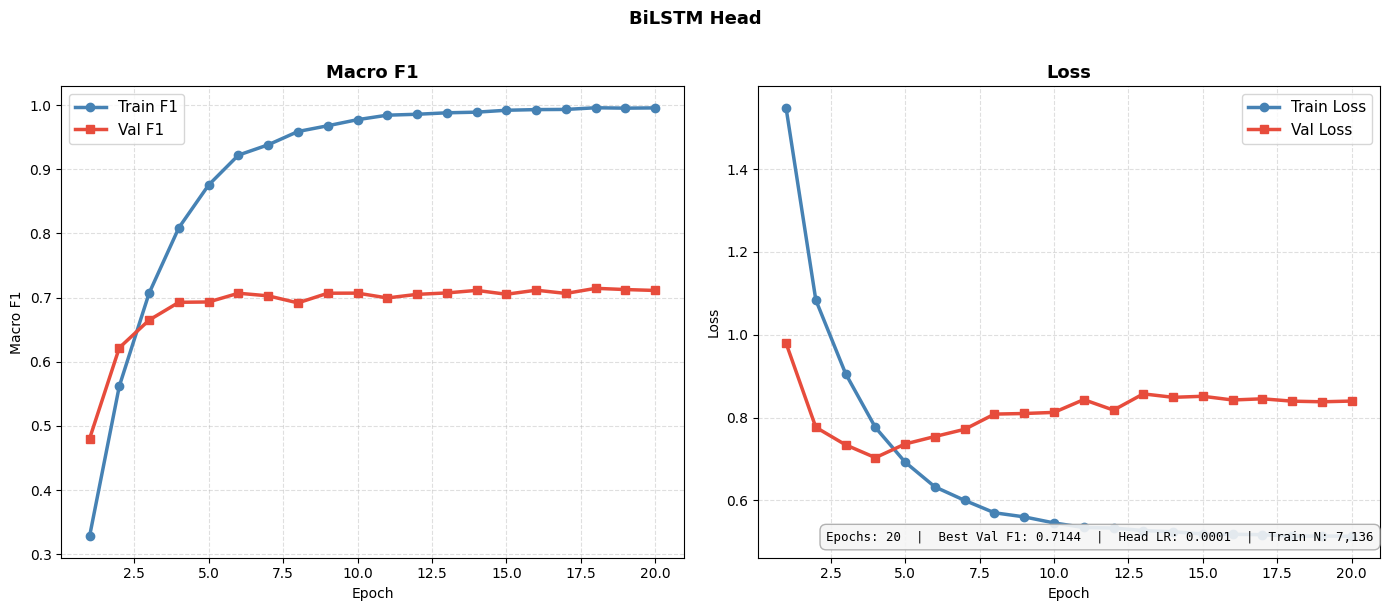

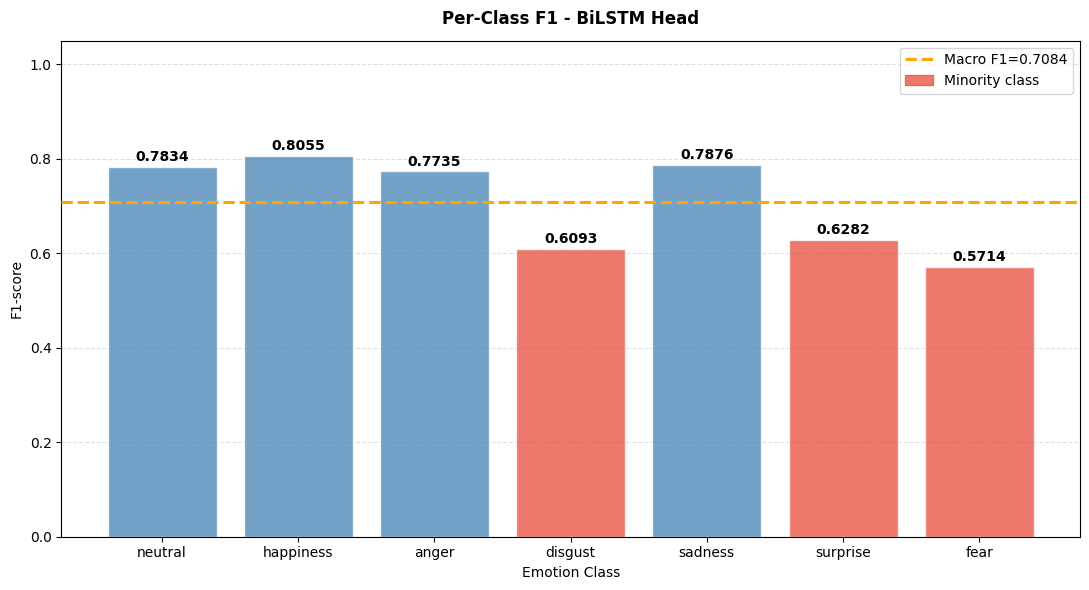

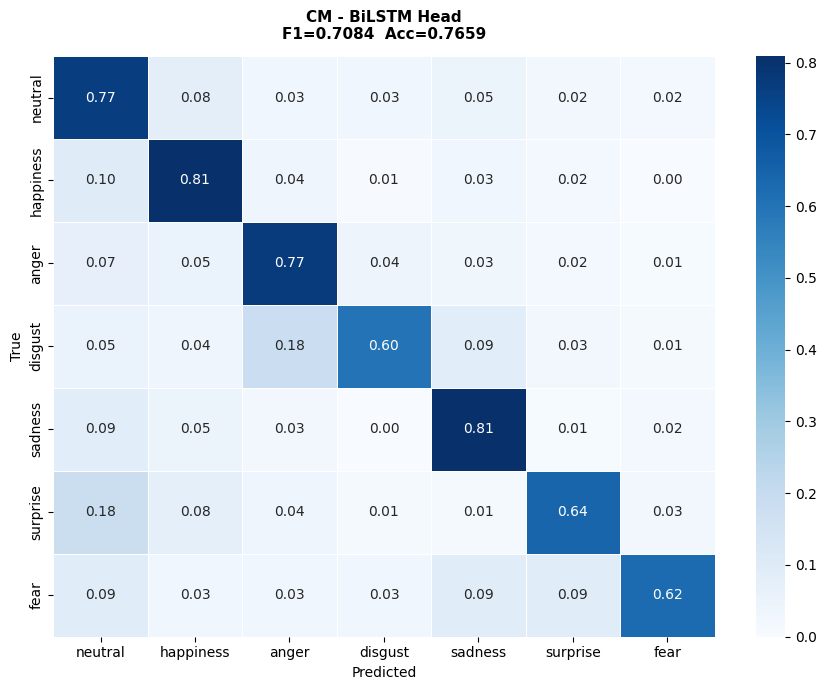


  BILSTM HEAD - Twitter-RoBERTa-large + LS

             Head LR Pooling  Epochs  Accuracy  Macro P  Macro R  Macro F1  Weighted F1  Val F1
Method                                                                                         
BiLSTM Head   0.0001  bypass      20    0.7659   0.7009   0.7176    0.7084       0.7663  0.7144

  PER-CLASS F1

             neutral  happiness   anger  disgust  sadness  surprise    fear
Method                                                                     
BiLSTM Head   0.7834     0.8055  0.7735   0.6093   0.7876    0.6282  0.5714

BiLSTM head Macro F1 = 0.7084

Saved to: bilstm_only/


In [9]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import re
import random
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
 
# ============================================================
# КОНФИГУРАЦИЯ
# ============================================================
 
ROBERTA_NAME    = "cardiffnlp/twitter-roberta-large-emotion-latest"
MAX_LEN         = 128
BATCH_SIZE      = 64
EPOCHS          = 20
ENCODER_LR      = 1e-5
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
PATIENCE        = 5
SEED            = 42
 
# DataLoader
NUM_WORKERS     = 4
PIN_MEMORY      = True
 
# Mixed precision (FP16 для V100 — нативная поддержка через Tensor Cores)
USE_AMP         = True
AMP_DTYPE       = torch.float16
 
emotion_classes  = ["neutral", "happiness", "anger", "disgust", "sadness", "surprise", "fear"]
CLASS_TO_ID      = {cls: i for i, cls in enumerate(emotion_classes)}
MINORITY_CLASSES = ["fear", "disgust", "surprise"]
 
SPLITS_DIR = "splits_new"
OUTPUT_DIR = "bilstm_only"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"AMP: {USE_AMP}  |  dtype: {AMP_DTYPE}  |  Batch: {BATCH_SIZE}  |  Encoder LR: {ENCODER_LR}")
 
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
 
# ============================================================
# ЛОСС
# ============================================================
 
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
 
    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_prob  = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            dist = torch.full_like(log_prob, self.smoothing / (n_classes - 1))
            dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(dist * log_prob).sum(dim=-1).mean()
 
 
# ============================================================
# BILSTM HEAD
# ============================================================
 
class RobertaBiLSTMHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = False
 
    def __init__(self, model_name, num_labels, lstm_hidden=256):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.lstm = nn.LSTM(
            input_size    = H,
            hidden_size   = lstm_hidden,
            num_layers    = 1,
            bidirectional = True,
            batch_first   = True,
        )
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(lstm_hidden * 2, num_labels)
 
    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        # LSTM безопаснее держать в FP32 (cuDNN bias to FP16 иногда нестабилен)
        with autocast('cuda', enabled=False):
            seq_fp32 = seq.float()
            out, _   = self.lstm(seq_fp32)
 
        mask = attention_mask.unsqueeze(-1).to(out.dtype)
        pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
 
        return self.classifier(self.dropout(pooled))
 
    def head_parameters(self):
        return list(self.lstm.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())
 
 
# ============================================================
# OPTIMIZER
# ============================================================
 
def build_optimizer(model, encoder_lr, head_lr, weight_decay):
    encoder_params = list(model.backbone.parameters())
    head_params    = model.head_parameters()
    no_decay = ("bias", "LayerNorm.weight", "layer_norm.weight")
 
    def split_decay(params, lr):
        decay, no_dec = [], []
        for n, p in params:
            if any(nd in n for nd in no_decay):
                no_dec.append(p)
            else:
                decay.append(p)
        return [
            {"params": decay,  "lr": lr, "weight_decay": weight_decay},
            {"params": no_dec, "lr": lr, "weight_decay": 0.0},
        ]
 
    encoder_named = list(model.backbone.named_parameters())
    head_named    = [(f"head.{i}", p) for i, p in enumerate(head_params)]
 
    groups = split_decay(encoder_named, encoder_lr) + \
             split_decay(head_named,    head_lr)
 
    return torch.optim.AdamW(groups, eps=1e-6)
 
 
# ============================================================
# TRAIN / EVAL — с FP16 autocast
# ============================================================
 
def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)
 
        optimizer.zero_grad(set_to_none=True)
 
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
            loss   = criterion(logits, labs)
 
        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
 
        scheduler.step()
 
        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).detach().cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")
 
 
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    ce = nn.CrossEntropyLoss()
    for batch in tqdm(loader, desc="  eval", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)
 
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
 
        # Loss и softmax считаем в FP32 для численной устойчивости метрик
        logits_fp32 = logits.float()
        total_loss += ce(logits_fp32, labs).item()
        probs = torch.softmax(logits_fp32, 1).cpu().numpy()
        all_preds.extend(probs.argmax(1))
        all_labels.extend(labs.cpu().numpy())
    return (total_loss / len(loader),
            f1_score(all_labels, all_preds, average="macro"),
            np.array(all_preds), np.array(all_labels))
 
# ============================================================
# ЭКСПЕРИМЕНТ
# ============================================================
 
def run_experiment(model_class, display_name,
                   train_df, val_df, test_df, tokenizer):
    print(f"\n{'='*60}")
    print(f"  {display_name}")
    print(f"  Head LR: {model_class.HEAD_LR}  |  Encoder LR: {ENCODER_LR}")
    print(f"{'='*60}")
 
    set_seed(SEED)
    num_labels = len(emotion_classes)
 
    X_train, y_train = train_df["tweet_text"], train_df["label_id"]
    X_val,   y_val   = val_df["tweet_text"],   val_df["label_id"]
    X_test,  y_test  = test_df["tweet_text"],  test_df["label_id"]
 
    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
 
    tr_loader = DataLoader(
        TweetDataset(X_train, y_train, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    va_loader = DataLoader(
        TweetDataset(X_val, y_val, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    te_loader = DataLoader(
        TweetDataset(X_test, y_test, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
 
    set_seed(SEED)
    model     = model_class(ROBERTA_NAME, num_labels).to(device)
    optimizer = build_optimizer(model,
                                encoder_lr   = ENCODER_LR,
                                head_lr      = model_class.HEAD_LR,
                                weight_decay = WEIGHT_DECAY)
    total_steps = len(tr_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * WARMUP_RATIO), total_steps)
 
    scaler = GradScaler('cuda', enabled=USE_AMP)
 
    best_f1, patience_cnt, best_state = 0.0, 0, None
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
 
    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_f1 = train_epoch(model, tr_loader, optimizer, scheduler, criterion, scaler)
        va_loss, va_f1, _, _ = evaluate(model, va_loader)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1);     history["val_f1"].append(va_f1)
 
        print(f"  Ep {ep}/{EPOCHS}  "
              f"trL={tr_loss:.4f} trF1={tr_f1:.4f}  "
              f"vaL={va_loss:.4f} vaF1={va_f1:.4f}", end="")
 
        if va_f1 > best_f1:
            best_f1, patience_cnt = va_f1, 0
            best_state = deepcopy(model.state_dict())
            print("  v")
        else:
            patience_cnt += 1
            print(f"  ... {patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"  Early stop at epoch {ep}"); break
 
    model.load_state_dict(best_state)
    te_loss, te_f1, te_preds, te_labels = evaluate(model, te_loader)
 
    rep     = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4,
                                    output_dict=True)
    rep_str = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4)
    print(f"\n  Test loss={te_loss:.4f}  Macro F1={te_f1:.4f}")
    print(rep_str)
 
    # Освобождаем VRAM
    del model, optimizer, scheduler, scaler, best_state
    torch.cuda.empty_cache()
 
    result = {
        "variant":              display_name,
        "head_lr":              model_class.HEAD_LR,
        "uses_pooling":         model_class.USES_POOLING,
        "train_size":           len(X_train),
        "epochs_trained":       len(history["train_loss"]),
        "best_val_f1":          best_f1,
        "test_loss":            te_loss,
        "test_accuracy":        rep["accuracy"],
        "test_macro_precision": rep["macro avg"]["precision"],
        "test_macro_recall":    rep["macro avg"]["recall"],
        "test_macro_f1":        rep["macro avg"]["f1-score"],
        "test_weighted_f1":     rep["weighted avg"]["f1-score"],
        "history":              history,
        "report_dict":          rep,
        "test_preds":           te_preds,
        "test_labels":          te_labels,
    }
    for cls in emotion_classes:
        result[f"f1_{cls}"] = rep[cls]["f1-score"] if cls in rep else 0.0
    return result
 
# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================
 
loaders, meta = load_splits(splits_dir=SPLITS_DIR)
train_df  = meta["train_df"]
val_df    = meta["val_df"]
test_df   = meta["test_df"]
tokenizer = meta["tokenizer"]
 
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
 
# ============================================================
# ЗАПУСК
# ============================================================
 
result = run_experiment(
    model_class  = RobertaBiLSTMHead,
    display_name = "BiLSTM Head",
    train_df     = train_df,
    val_df       = val_df,
    test_df      = test_df,
    tokenizer    = tokenizer,
)
 
# ============================================================
# ГРАФИКИ
# ============================================================
 
plt.rcParams['font.family'] = 'DejaVu Sans'
PROPS_BOX  = dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5',
                  edgecolor='#aaaaaa', alpha=0.9)
 
 
def plot_training_curves(result, output_dir):
    ep = range(1, len(result["history"]["train_f1"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('white')
    for ax in axes:
        ax.set_facecolor('white')
        ax.grid(True, ls='--', alpha=0.4, zorder=1)
        ax.set_axisbelow(True)
    axes[0].plot(ep, result["history"]["train_f1"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train F1", zorder=3)
    axes[0].plot(ep, result["history"]["val_f1"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val F1", zorder=3)
    axes[0].set_title("Macro F1", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Macro F1")
    axes[0].legend(fontsize=11)
 
    axes[1].plot(ep, result["history"]["train_loss"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train Loss", zorder=3)
    axes[1].plot(ep, result["history"]["val_loss"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val Loss", zorder=3)
    axes[1].set_title("Loss", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(fontsize=11)
 
    stats = (f"Epochs: {result['epochs_trained']}  |  "
             f"Best Val F1: {result['best_val_f1']:.4f}  |  "
             f"Head LR: {result['head_lr']}  |  "
             f"Train N: {result['train_size']:,}")
    axes[1].text(0.99, 0.03, stats, transform=axes[1].transAxes, fontsize=9,
                 va='bottom', ha='right', bbox=PROPS_BOX, family='monospace')
 
    plt.suptitle(result["variant"], fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"curves_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
def plot_per_class_f1(result, output_dir):
    from matplotlib.patches import Patch
    rep = result["report_dict"]
    f1s = [rep[c]["f1-score"] if c in rep else 0 for c in emotion_classes]
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')
 
    colors = ["#e74c3c" if c in MINORITY_CLASSES else "steelblue"
              for c in emotion_classes]
    bars = ax.bar(emotion_classes, f1s, color=colors, alpha=0.75,
                  edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
 
    ax.axhline(result["test_macro_f1"], color="#FFA500", ls="--", lw=2.2,
               zorder=3, label=f"Macro F1={result['test_macro_f1']:.4f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
    ax.set_title(f"Per-Class F1 - {result['variant']}",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
    ax.legend(handles=[
        plt.Line2D([0], [0], color="#FFA500", ls="--", lw=2.2,
                   label=f"Macro F1={result['test_macro_f1']:.4f}"),
        Patch(color='#e74c3c', alpha=0.75, label='Minority class'),
    ], fontsize=10)
 
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"perclass_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
def plot_confusion_matrix(result, output_dir):
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')
    cm   = confusion_matrix(result["test_labels"], result["test_preds"])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_classes, yticklabels=emotion_classes,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f"CM - {result['variant']}\n"
                 f"F1={result['test_macro_f1']:.4f}  "
                 f"Acc={result['test_accuracy']:.4f}",
                 fontsize=11, fontweight="bold", pad=12)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"cm_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
plot_training_curves(result, OUTPUT_DIR)
plot_per_class_f1(result, OUTPUT_DIR)
plot_confusion_matrix(result, OUTPUT_DIR)
 
# ============================================================
# ИТОГОВАЯ ТАБЛИЦА
# ============================================================
 
print(f"\n{'='*120}")
print("  BILSTM HEAD - Twitter-RoBERTa-large + LS")
print(f"{'='*120}\n")
 
summary_row = {
    "Method":      result["variant"],
    "Head LR":     result["head_lr"],
    "Pooling":     "Attn" if result["uses_pooling"] else "bypass",
    "Epochs":      result["epochs_trained"],
    "Accuracy":    round(result["test_accuracy"], 4),
    "Macro P":     round(result["test_macro_precision"], 4),
    "Macro R":     round(result["test_macro_recall"], 4),
    "Macro F1":    round(result["test_macro_f1"], 4),
    "Weighted F1": round(result["test_weighted_f1"], 4),
    "Val F1":      round(result["best_val_f1"], 4),
}
 
summary_df = pd.DataFrame([summary_row]).set_index("Method")
print(summary_df.to_string())
 
print(f"\n{'='*120}")
print("  PER-CLASS F1")
print(f"{'='*120}\n")
 
pc_row = {"Method": result["variant"],
          **{c: round(result.get(f"f1_{c}", 0), 4) for c in emotion_classes}}
pc_df = pd.DataFrame([pc_row]).set_index("Method")
print(pc_df.to_string())
 
# Сохранение
summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"))
pc_df.to_csv(os.path.join(OUTPUT_DIR, "per_class_f1.csv"))
 
print(f"\nBiLSTM head Macro F1 = {result['test_macro_f1']:.4f}")
print(f"\nSaved to: {OUTPUT_DIR}/")

Device: cuda
AMP: True  |  dtype: torch.float16  |  Batch: 64  |  Encoder LR: 1e-05
Splits loaded from: splits_new/
  Train: 7136 | Val: 1260 | Test: 1482

  Train samples per class:
    id=0  neutral     :  2315
    id=1  happiness   :  1745
    id=2  anger       :  1129
    id=3  disgust     :   368
    id=4  sadness     :  1057
    id=5  surprise    :   368
    id=6  fear        :   154
Train: 7136 | Val: 1260 | Test: 1482

  BiLSTM Head
  Head LR: 0.0001  |  Encoder LR: 1e-05


Loading weights: 100%|████████████████████████████████████████████████████████████████████| 389/389 [00:00<00:00, 4193.05it/s]
RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-large-emotion-latest
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
                                                                                                                              

  Ep 1/20  trL=1.5482 trF1=0.3281  vaL=0.9798 vaF1=0.4801  v


  Ep 2/20  trL=1.0839 trF1=0.5621  vaL=0.7765 vaF1=0.6218  v


  Ep 3/20  trL=0.9062 trF1=0.7068  vaL=0.7342 vaF1=0.6649  v


...

  Ep 17/20  trL=0.5173 trF1=0.9932  vaL=0.8454 vaF1=0.7065  ... 1/5


  Ep 18/20  trL=0.5136 trF1=0.9957  vaL=0.8397 vaF1=0.7144  v


  Ep 19/20  trL=0.5141 trF1=0.9951  vaL=0.8382 vaF1=0.7125  ... 1/5


  Ep 20/20  trL=0.5134 trF1=0.9955  vaL=0.8399 vaF1=0.7111  ... 2/5



  Test loss=0.9056  Macro F1=0.7084
              precision    recall  f1-score   support

     neutral     0.8004    0.7672    0.7834       481
   happiness     0.8044    0.8066    0.8055       362
       anger     0.7735    0.7735    0.7735       234
     disgust     0.6216    0.5974    0.6093        77
     sadness     0.7672    0.8091    0.7876       220
    surprise     0.6125    0.6447    0.6282        76
        fear     0.5263    0.6250    0.5714        32

    accuracy                         0.7659      1482
   macro avg     0.7009    0.7176    0.7084      1482
weighted avg     0.7674    0.7659    0.7663      1482



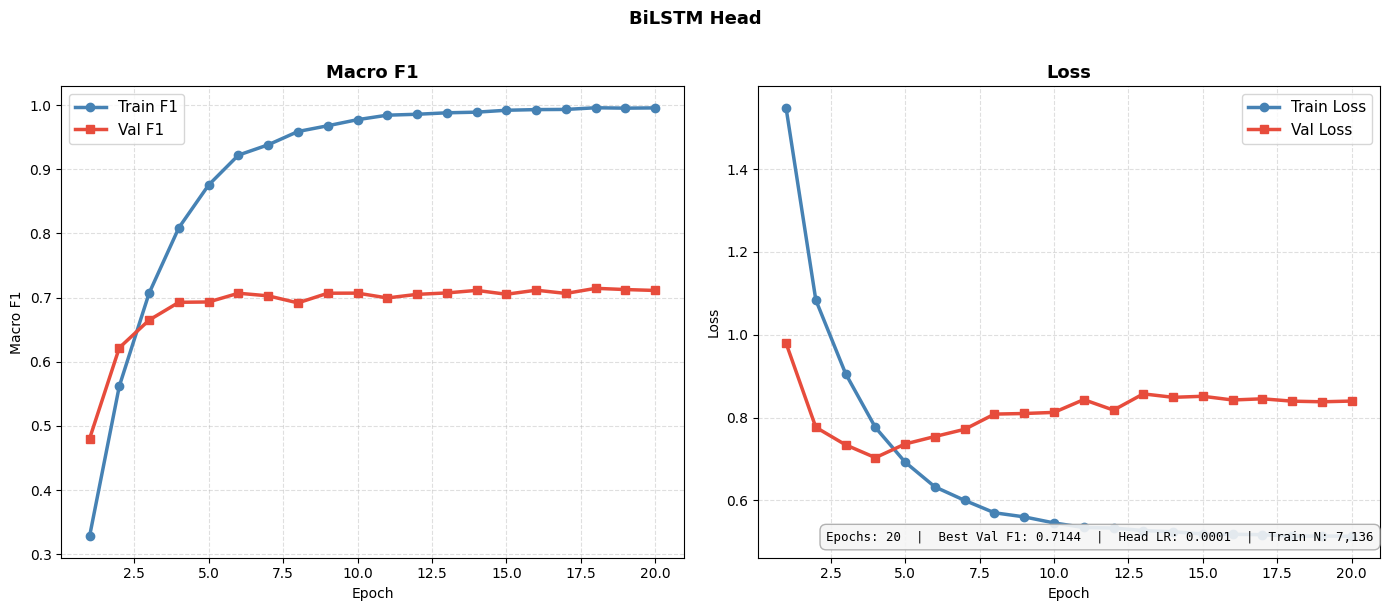

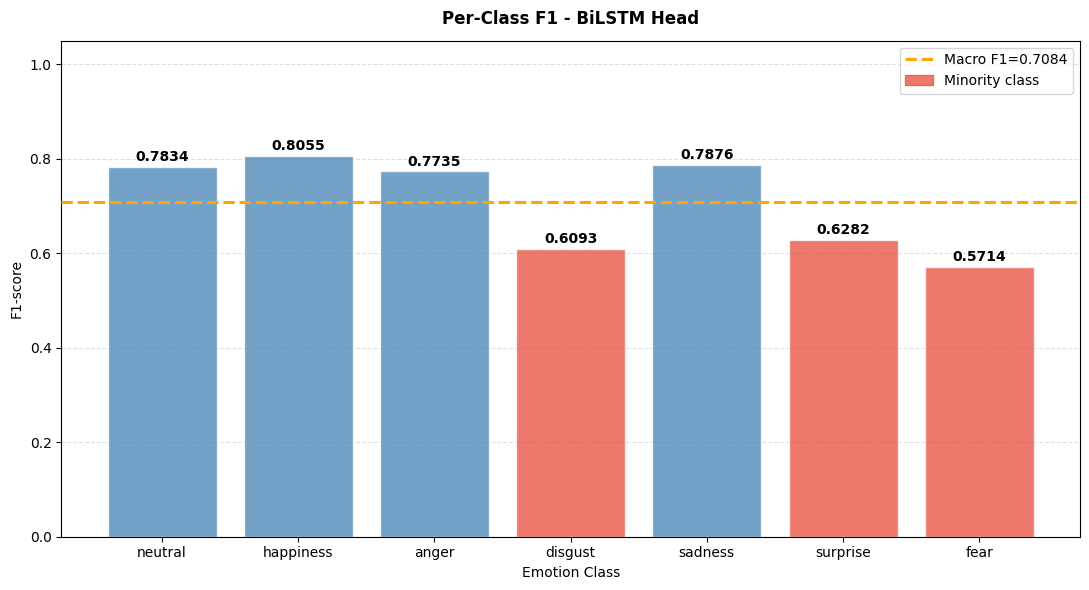

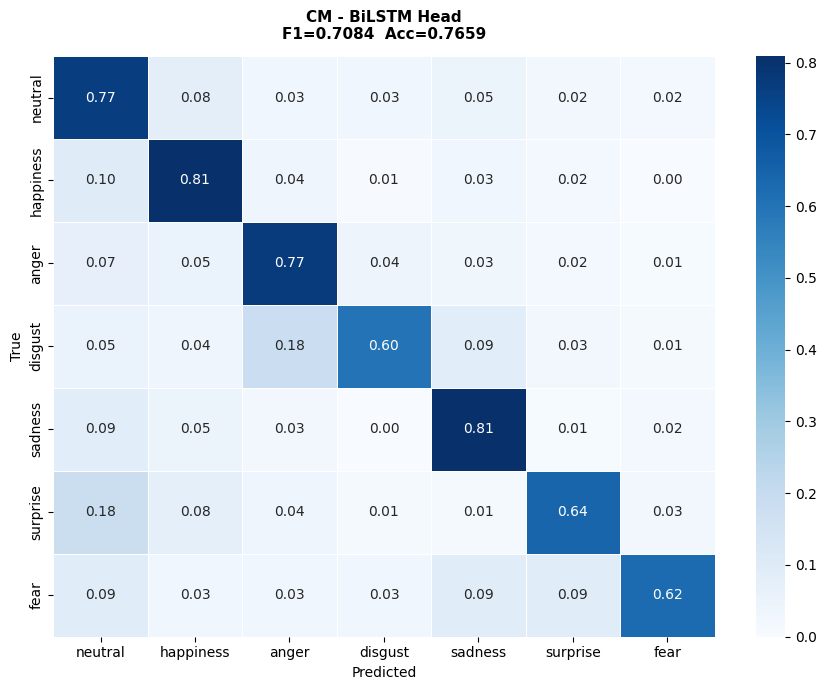


  BILSTM HEAD - Twitter-RoBERTa-large + LS

             Head LR Pooling  Epochs  Accuracy  Macro P  Macro R  Macro F1  Weighted F1  Val F1
Method                                                                                         
BiLSTM Head   0.0001  bypass      20    0.7659   0.7009   0.7176    0.7084       0.7663  0.7144

  PER-CLASS F1

             neutral  happiness   anger  disgust  sadness  surprise    fear
Method                                                                     
BiLSTM Head   0.7834     0.8055  0.7735   0.6093   0.7876    0.6282  0.5714

BiLSTM head Macro F1 = 0.7084

Saved to: bilstm_only/


In [5]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import re
import random
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
 
# ============================================================
# КОНФИГУРАЦИЯ
# ============================================================
 
ROBERTA_NAME    = "cardiffnlp/twitter-roberta-large-emotion-latest"
MAX_LEN         = 128
BATCH_SIZE      = 64
EPOCHS          = 20
ENCODER_LR      = 1e-5
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
PATIENCE        = 5
SEED            = 42
 
# DataLoader
NUM_WORKERS     = 4
PIN_MEMORY      = True
 
# Mixed precision (FP16 для V100 — нативная поддержка через Tensor Cores)
USE_AMP         = True
AMP_DTYPE       = torch.float16
 
emotion_classes  = ["neutral", "happiness", "anger", "disgust", "sadness", "surprise", "fear"]
CLASS_TO_ID      = {cls: i for i, cls in enumerate(emotion_classes)}
MINORITY_CLASSES = ["fear", "disgust", "surprise"]
 
SPLITS_DIR = "splits_new"
OUTPUT_DIR = "bilstm_only"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"AMP: {USE_AMP}  |  dtype: {AMP_DTYPE}  |  Batch: {BATCH_SIZE}  |  Encoder LR: {ENCODER_LR}")
 
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
 
# ============================================================
# ЛОСС
# ============================================================
 
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
 
    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_prob  = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            dist = torch.full_like(log_prob, self.smoothing / (n_classes - 1))
            dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(dist * log_prob).sum(dim=-1).mean()
 
 
# ============================================================
# BILSTM HEAD
# ============================================================
 
class RobertaBiLSTMHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = False
 
    def __init__(self, model_name, num_labels, lstm_hidden=256):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.lstm = nn.LSTM(
            input_size    = H,
            hidden_size   = lstm_hidden,
            num_layers    = 1,
            bidirectional = True,
            batch_first   = True,
        )
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(lstm_hidden * 2, num_labels)
 
    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        # LSTM безопаснее держать в FP32 (cuDNN bias to FP16 иногда нестабилен)
        with autocast('cuda', enabled=False):
            seq_fp32 = seq.float()
            out, _   = self.lstm(seq_fp32)
 
        mask = attention_mask.unsqueeze(-1).to(out.dtype)
        pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
 
        return self.classifier(self.dropout(pooled))
 
    def head_parameters(self):
        return list(self.lstm.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())
 
 
# ============================================================
# OPTIMIZER
# ============================================================
 
def build_optimizer(model, encoder_lr, head_lr, weight_decay):
    encoder_params = list(model.backbone.parameters())
    head_params    = model.head_parameters()
    no_decay = ("bias", "LayerNorm.weight", "layer_norm.weight")
 
    def split_decay(params, lr):
        decay, no_dec = [], []
        for n, p in params:
            if any(nd in n for nd in no_decay):
                no_dec.append(p)
            else:
                decay.append(p)
        return [
            {"params": decay,  "lr": lr, "weight_decay": weight_decay},
            {"params": no_dec, "lr": lr, "weight_decay": 0.0},
        ]
 
    encoder_named = list(model.backbone.named_parameters())
    head_named    = [(f"head.{i}", p) for i, p in enumerate(head_params)]
 
    groups = split_decay(encoder_named, encoder_lr) + \
             split_decay(head_named,    head_lr)
 
    return torch.optim.AdamW(groups, eps=1e-6)
 
 
# ============================================================
# TRAIN / EVAL — с FP16 autocast
# ============================================================
 
def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)
 
        optimizer.zero_grad(set_to_none=True)
 
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
            loss   = criterion(logits, labs)
 
        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
 
        scheduler.step()
 
        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).detach().cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")
 
 
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    ce = nn.CrossEntropyLoss()
    for batch in tqdm(loader, desc="  eval", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)
 
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
 
        # Loss и softmax считаем в FP32 для численной устойчивости метрик
        logits_fp32 = logits.float()
        total_loss += ce(logits_fp32, labs).item()
        probs = torch.softmax(logits_fp32, 1).cpu().numpy()
        all_preds.extend(probs.argmax(1))
        all_labels.extend(labs.cpu().numpy())
    return (total_loss / len(loader),
            f1_score(all_labels, all_preds, average="macro"),
            np.array(all_preds), np.array(all_labels))
 
# ============================================================
# ЭКСПЕРИМЕНТ
# ============================================================
 
def run_experiment(model_class, display_name,
                   train_df, val_df, test_df, tokenizer):
    print(f"\n{'='*60}")
    print(f"  {display_name}")
    print(f"  Head LR: {model_class.HEAD_LR}  |  Encoder LR: {ENCODER_LR}")
    print(f"{'='*60}")
 
    set_seed(SEED)
    num_labels = len(emotion_classes)
 
    X_train, y_train = train_df["tweet_text"], train_df["label_id"]
    X_val,   y_val   = val_df["tweet_text"],   val_df["label_id"]
    X_test,  y_test  = test_df["tweet_text"],  test_df["label_id"]
 
    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
 
    tr_loader = DataLoader(
        TweetDataset(X_train, y_train, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    va_loader = DataLoader(
        TweetDataset(X_val, y_val, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    te_loader = DataLoader(
        TweetDataset(X_test, y_test, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
 
    set_seed(SEED)
    model     = model_class(ROBERTA_NAME, num_labels).to(device)
    optimizer = build_optimizer(model,
                                encoder_lr   = ENCODER_LR,
                                head_lr      = model_class.HEAD_LR,
                                weight_decay = WEIGHT_DECAY)
    total_steps = len(tr_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * WARMUP_RATIO), total_steps)
 
    scaler = GradScaler('cuda', enabled=USE_AMP)
 
    best_f1, patience_cnt, best_state = 0.0, 0, None
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
 
    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_f1 = train_epoch(model, tr_loader, optimizer, scheduler, criterion, scaler)
        va_loss, va_f1, _, _ = evaluate(model, va_loader)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1);     history["val_f1"].append(va_f1)
 
        print(f"  Ep {ep}/{EPOCHS}  "
              f"trL={tr_loss:.4f} trF1={tr_f1:.4f}  "
              f"vaL={va_loss:.4f} vaF1={va_f1:.4f}", end="")
 
        if va_f1 > best_f1:
            best_f1, patience_cnt = va_f1, 0
            best_state = deepcopy(model.state_dict())
            print("  v")
        else:
            patience_cnt += 1
            print(f"  ... {patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"  Early stop at epoch {ep}"); break
 
    model.load_state_dict(best_state)
    te_loss, te_f1, te_preds, te_labels = evaluate(model, te_loader)
 
    rep     = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4,
                                    output_dict=True)
    rep_str = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4)
    print(f"\n  Test loss={te_loss:.4f}  Macro F1={te_f1:.4f}")
    print(rep_str)
 
    # Освобождаем VRAM
    del model, optimizer, scheduler, scaler, best_state
    torch.cuda.empty_cache()
 
    result = {
        "variant":              display_name,
        "head_lr":              model_class.HEAD_LR,
        "uses_pooling":         model_class.USES_POOLING,
        "train_size":           len(X_train),
        "epochs_trained":       len(history["train_loss"]),
        "best_val_f1":          best_f1,
        "test_loss":            te_loss,
        "test_accuracy":        rep["accuracy"],
        "test_macro_precision": rep["macro avg"]["precision"],
        "test_macro_recall":    rep["macro avg"]["recall"],
        "test_macro_f1":        rep["macro avg"]["f1-score"],
        "test_weighted_f1":     rep["weighted avg"]["f1-score"],
        "history":              history,
        "report_dict":          rep,
        "test_preds":           te_preds,
        "test_labels":          te_labels,
    }
    for cls in emotion_classes:
        result[f"f1_{cls}"] = rep[cls]["f1-score"] if cls in rep else 0.0
    return result
 
# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================
 
loaders, meta = load_splits(splits_dir=SPLITS_DIR)
train_df  = meta["train_df"]
val_df    = meta["val_df"]
test_df   = meta["test_df"]
tokenizer = meta["tokenizer"]
 
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
 
# ============================================================
# ЗАПУСК
# ============================================================
 
result = run_experiment(
    model_class  = RobertaBiLSTMHead,
    display_name = "BiLSTM Head",
    train_df     = train_df,
    val_df       = val_df,
    test_df      = test_df,
    tokenizer    = tokenizer,
)
 
# ============================================================
# ГРАФИКИ
# ============================================================
 
plt.rcParams['font.family'] = 'DejaVu Sans'
PROPS_BOX  = dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5',
                  edgecolor='#aaaaaa', alpha=0.9)
 
 
def plot_training_curves(result, output_dir):
    ep = range(1, len(result["history"]["train_f1"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('white')
    for ax in axes:
        ax.set_facecolor('white')
        ax.grid(True, ls='--', alpha=0.4, zorder=1)
        ax.set_axisbelow(True)
    axes[0].plot(ep, result["history"]["train_f1"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train F1", zorder=3)
    axes[0].plot(ep, result["history"]["val_f1"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val F1", zorder=3)
    axes[0].set_title("Macro F1", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Macro F1")
    axes[0].legend(fontsize=11)
 
    axes[1].plot(ep, result["history"]["train_loss"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train Loss", zorder=3)
    axes[1].plot(ep, result["history"]["val_loss"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val Loss", zorder=3)
    axes[1].set_title("Loss", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(fontsize=11)
 
    stats = (f"Epochs: {result['epochs_trained']}  |  "
             f"Best Val F1: {result['best_val_f1']:.4f}  |  "
             f"Head LR: {result['head_lr']}  |  "
             f"Train N: {result['train_size']:,}")
    axes[1].text(0.99, 0.03, stats, transform=axes[1].transAxes, fontsize=9,
                 va='bottom', ha='right', bbox=PROPS_BOX, family='monospace')
 
    plt.suptitle(result["variant"], fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"curves_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
def plot_per_class_f1(result, output_dir):
    from matplotlib.patches import Patch
    rep = result["report_dict"]
    f1s = [rep[c]["f1-score"] if c in rep else 0 for c in emotion_classes]
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')
 
    colors = ["#e74c3c" if c in MINORITY_CLASSES else "steelblue"
              for c in emotion_classes]
    bars = ax.bar(emotion_classes, f1s, color=colors, alpha=0.75,
                  edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
 
    ax.axhline(result["test_macro_f1"], color="#FFA500", ls="--", lw=2.2,
               zorder=3, label=f"Macro F1={result['test_macro_f1']:.4f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
    ax.set_title(f"Per-Class F1 - {result['variant']}",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
    ax.legend(handles=[
        plt.Line2D([0], [0], color="#FFA500", ls="--", lw=2.2,
                   label=f"Macro F1={result['test_macro_f1']:.4f}"),
        Patch(color='#e74c3c', alpha=0.75, label='Minority class'),
    ], fontsize=10)
 
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"perclass_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
def plot_confusion_matrix(result, output_dir):
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')
    cm   = confusion_matrix(result["test_labels"], result["test_preds"])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_classes, yticklabels=emotion_classes,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f"CM - {result['variant']}\n"
                 f"F1={result['test_macro_f1']:.4f}  "
                 f"Acc={result['test_accuracy']:.4f}",
                 fontsize=11, fontweight="bold", pad=12)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"cm_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
plot_training_curves(result, OUTPUT_DIR)
plot_per_class_f1(result, OUTPUT_DIR)
plot_confusion_matrix(result, OUTPUT_DIR)
 
# ============================================================
# ИТОГОВАЯ ТАБЛИЦА
# ============================================================
 
print(f"\n{'='*120}")
print("  BILSTM HEAD - Twitter-RoBERTa-large + LS")
print(f"{'='*120}\n")
 
summary_row = {
    "Method":      result["variant"],
    "Head LR":     result["head_lr"],
    "Pooling":     "Attn" if result["uses_pooling"] else "bypass",
    "Epochs":      result["epochs_trained"],
    "Accuracy":    round(result["test_accuracy"], 4),
    "Macro P":     round(result["test_macro_precision"], 4),
    "Macro R":     round(result["test_macro_recall"], 4),
    "Macro F1":    round(result["test_macro_f1"], 4),
    "Weighted F1": round(result["test_weighted_f1"], 4),
    "Val F1":      round(result["best_val_f1"], 4),
}
 
summary_df = pd.DataFrame([summary_row]).set_index("Method")
print(summary_df.to_string())
 
print(f"\n{'='*120}")
print("  PER-CLASS F1")
print(f"{'='*120}\n")
 
pc_row = {"Method": result["variant"],
          **{c: round(result.get(f"f1_{c}", 0), 4) for c in emotion_classes}}
pc_df = pd.DataFrame([pc_row]).set_index("Method")
print(pc_df.to_string())
 
# Сохранение
summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"))
pc_df.to_csv(os.path.join(OUTPUT_DIR, "per_class_f1.csv"))
 
print(f"\nBiLSTM head Macro F1 = {result['test_macro_f1']:.4f}")
print(f"\nSaved to: {OUTPUT_DIR}/")

In [6]:
# ============================================================
# СОХРАНЕНИЕ ТЕСТА С TRUE И PRED
# ============================================================

test_predictions_df = pd.DataFrame({
    "tweet_text": test_df["tweet_text"].reset_index(drop=True).values,
    "label_id":   result["test_labels"],
    "tone_value": result["test_preds"],
})

pred_path = os.path.join(OUTPUT_DIR, "test_predictions.csv")
test_predictions_df.to_csv(pred_path, index=False)
print(f"Saved predictions: {pred_path}")

Saved predictions: bilstm_only/test_predictions.csv


In [9]:
"""
================================================================================
Bi-GRU + GloVe Twitter 200d  —  RNN baseline для emotion classification
================================================================================

Заполняет методологический пробел между классическим ML (TF-IDF + LR/SVM)
и трансформерами/декодерами. Каноничный strong RNN-baseline для твиттерских
эмоций: GloVe Twitter -> Bi-GRU -> masked self-attention pooling -> FC.

ВАЖНО: используются ТЕ ЖЕ splits, что и в трансформерном пайплайне
(splits_new/{train,val,test}.csv с колонками tweet_text, label_id).
Никаких ре-сплитов, ре-сэмплинга или фильтрации не выполняется.

GloVe Twitter 200d скачивается автоматически в ./glove/ при первом запуске.
"""

import os
import re
import zipfile
import random
import urllib.request
from collections import Counter
from copy import deepcopy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import emoji
    HAS_EMOJI = True
except ImportError:
    HAS_EMOJI = False
    print("[warn] `emoji` пакет не установлен. Запусти: pip install emoji")
    print("       Без него эмодзи в твитах не будут конвертированы в слова.")

# ============================================================
# КОНФИГУРАЦИЯ
# ============================================================

SEED            = 42
MAX_LEN         = 64
MIN_FREQ        = 2
EMB_DIM         = 200
GRU_HIDDEN      = 256
GRU_LAYERS      = 2
DROPOUT_EMB     = 0.3
DROPOUT_FC      = 0.5

BATCH_SIZE      = 128
EPOCHS          = 30
LR              = 1e-3
EMB_LR          = 1e-4
EMB_FREEZE_EPOCHS = 3
WEIGHT_DECAY    = 1e-5
GRAD_CLIP       = 1.0
PATIENCE        = 6
LABEL_SMOOTHING = 0.1

NUM_WORKERS     = 4
PIN_MEMORY      = True
USE_AMP         = True
AMP_DTYPE       = torch.float16

emotion_classes  = ["neutral", "happiness", "anger", "disgust",
                    "sadness", "surprise", "fear"]
CLASS_TO_ID      = {c: i for i, c in enumerate(emotion_classes)}
MINORITY_CLASSES = ["fear", "disgust", "surprise"]

SPLITS_DIR  = "splits_new"
OUTPUT_DIR  = "bigru_glove"
GLOVE_DIR   = "glove"
GLOVE_URL   = "https://nlp.stanford.edu/data/glove.twitter.27B.zip"
GLOVE_FILE  = "glove.twitter.27B.200d.txt"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(GLOVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"AMP: {USE_AMP} | dtype: {AMP_DTYPE} | Batch: {BATCH_SIZE}")


def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True


set_seed(SEED)

# ============================================================
# ЗАГРУЗКА SPLITS  —  те же файлы, что у трансформера
# ============================================================

def load_splits_from_csv(splits_dir=SPLITS_DIR):
    """Читаем те же CSV, что использует трансформерный пайплайн.
    НИКАКОЙ модификации, ре-сплита или фильтрации."""
    paths = {s: os.path.join(splits_dir, f"{s}.csv") for s in ("train", "val", "test")}
    for s, p in paths.items():
        if not os.path.exists(p):
            raise FileNotFoundError(
                f"Не найден {p}. Ожидаются файлы train.csv / val.csv / test.csv "
                f"в директории {splits_dir}/ с колонками tweet_text и label_id."
            )
    train_df = pd.read_csv(paths["train"])
    val_df   = pd.read_csv(paths["val"])
    test_df  = pd.read_csv(paths["test"])

    for name, df in (("train", train_df), ("val", val_df), ("test", test_df)):
        for col in ("tweet_text", "label_id"):
            if col not in df.columns:
                raise ValueError(f"В {name}.csv нет колонки '{col}'. "
                                 f"Колонки файла: {list(df.columns)}")

    print(f"Splits загружены БЕЗ модификации:")
    print(f"  Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
    print(f"  Распределение классов в train: "
          f"{dict(Counter(train_df['label_id'].tolist()))}")
    return train_df, val_df, test_df


# ============================================================
# ПРЕПРОЦЕССИНГ (twitter-aware, под словарь GloVe Twitter)
# ============================================================
# GloVe Twitter обучен с препроцессингом Stanford ruby-скрипта:
# URL -> <url>, mention -> <user>, hashtag -> <hashtag> word,
# number -> <number>, эмодзи -> текст. Имитируем близко для максимума coverage.

URL_RE       = re.compile(r"http\S+|www\.\S+")
USER_RE      = re.compile(r"@\w+")
HASHTAG_RE   = re.compile(r"#(\w+)")
NUMBER_RE    = re.compile(r"\b\d+([.,]\d+)?\b")
SPACE_RE     = re.compile(r"\s+")
REPEAT_RE    = re.compile(r"(.)\1{2,}")
PUNCT_REP_RE = re.compile(r"([!?.,]){2,}")
PUNCT_SPLIT_RE = re.compile(r"([!?.,;:()\"'])")


def preprocess_tweet(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = text.lower().strip()
    t = URL_RE.sub(" <url> ", t)
    t = USER_RE.sub(" <user> ", t)
    t = HASHTAG_RE.sub(r" <hashtag> \1 ", t)
    t = NUMBER_RE.sub(" <number> ", t)
    if HAS_EMOJI:
        t = emoji.demojize(t, delimiters=(" ", " "))
    t = REPEAT_RE.sub(r"\1\1", t)
    t = PUNCT_REP_RE.sub(r"\1 <repeat> ", t)
    t = SPACE_RE.sub(" ", t).strip()
    return t


def simple_tokenize(text: str):
    text = PUNCT_SPLIT_RE.sub(r" \1 ", text)
    text = SPACE_RE.sub(" ", text).strip()
    return text.split() if text else []


# ============================================================
# СЛОВАРЬ
# ============================================================

PAD_TOK, UNK_TOK = "<pad>", "<unk>"
PAD_IDX, UNK_IDX = 0, 1


def build_vocab(texts, min_freq=MIN_FREQ):
    counter = Counter()
    for t in texts:
        counter.update(simple_tokenize(preprocess_tweet(t)))
    itos = [PAD_TOK, UNK_TOK]
    for tok, cnt in counter.most_common():
        if cnt >= min_freq:
            itos.append(tok)
    stoi = {tok: i for i, tok in enumerate(itos)}
    print(f"Vocab: {len(itos)} токенов (min_freq={min_freq})")
    return stoi, itos


# ============================================================
# GLOVE
# ============================================================

def ensure_glove():
    """Скачиваем glove.twitter.27B.200d.txt с HuggingFace mirror (надёжнее Stanford)."""
    target = os.path.join(GLOVE_DIR, GLOVE_FILE)
    if os.path.exists(target):
        print(f"GloVe найден: {target}")
        return target

    from huggingface_hub import hf_hub_download
    print(f"Скачиваю {GLOVE_FILE} с HuggingFace mirror (~750 MB)...")
    path = hf_hub_download(
        repo_id   = "stanfordnlp/glove",
        filename  = GLOVE_FILE,
        repo_type = "model",
        local_dir = GLOVE_DIR,
    )
    # hf_hub_download возвращает путь — если он не совпал с target, делаем симлинк
    if os.path.abspath(path) != os.path.abspath(target):
        if not os.path.exists(target):
            os.symlink(os.path.abspath(path), target)
    print(f"  Скачано: {target}")
    return target


def load_glove_into_matrix(glove_path, stoi, dim=EMB_DIM):
    """Матрица [V, dim]: для слов из словаря — векторы GloVe; для OOV — N(0, 0.1)."""
    V = len(stoi)
    matrix = np.random.normal(scale=0.1, size=(V, dim)).astype(np.float32)
    matrix[PAD_IDX] = 0.0
    found = 0
    print(f"Загружаю GloVe и матчу со словарём (V={V})...")
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            tok = parts[0]
            if tok in stoi:
                vec = np.asarray(parts[1:], dtype=np.float32)
                if vec.shape[0] == dim:
                    matrix[stoi[tok]] = vec
                    found += 1
    coverage = found / max(V - 2, 1)  # минус <pad>, <unk>
    print(f"GloVe coverage: {found}/{V-2} = {coverage:.1%}")
    return torch.from_numpy(matrix), coverage


# ============================================================
# DATASET
# ============================================================

class GloveTweetDataset(Dataset):
    def __init__(self, texts, labels, stoi, max_len=MAX_LEN):
        self.texts   = list(texts)
        self.labels  = list(labels)
        self.stoi    = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def encode(self, text):
        toks = simple_tokenize(preprocess_tweet(text))[: self.max_len]
        ids  = [self.stoi.get(t, UNK_IDX) for t in toks]
        length = len(ids)
        if length < self.max_len:
            ids = ids + [PAD_IDX] * (self.max_len - length)
        mask = [1] * length + [0] * (self.max_len - length)
        return ids, mask, max(length, 1)

    def __getitem__(self, idx):
        ids, mask, length = self.encode(self.texts[idx])
        return {
            "input_ids":      torch.tensor(ids,  dtype=torch.long),
            "attention_mask": torch.tensor(mask, dtype=torch.long),
            "length":         torch.tensor(length, dtype=torch.long),
            "labels":         torch.tensor(int(self.labels[idx]), dtype=torch.long),
        }


# ============================================================
# МОДЕЛЬ: Bi-GRU + masked self-attention pooling
# ============================================================

class SpatialDropout1D(nn.Module):
    """Dropout по координате эмбеддинга (как в Keras): шум одинаковый для всех токенов."""
    def __init__(self, p):
        super().__init__()
        self.p = p

    def forward(self, x):  # x: [B, T, D]
        if not self.training or self.p == 0:
            return x
        mask = x.new_empty(x.size(0), 1, x.size(2)).bernoulli_(1 - self.p)
        return x * mask / (1 - self.p)


class AttentionPool(nn.Module):
    """Masked additive self-attention pooling (Bahdanau-style)."""
    def __init__(self, hidden):
        super().__init__()
        self.proj = nn.Linear(hidden, hidden)
        self.v    = nn.Linear(hidden, 1, bias=False)

    def forward(self, x, mask):  # x: [B, T, H], mask: [B, T]
        scores = self.v(torch.tanh(self.proj(x))).squeeze(-1)        # [B, T]
        scores = scores.masked_fill(mask == 0, float("-inf"))
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)         # [B, T, 1]
        return (x * weights).sum(dim=1)                              # [B, H]


class BiGRUClassifier(nn.Module):
    def __init__(self, emb_matrix, num_labels,
                 gru_hidden=GRU_HIDDEN, gru_layers=GRU_LAYERS,
                 dropout_emb=DROPOUT_EMB, dropout_fc=DROPOUT_FC):
        super().__init__()
        V, D = emb_matrix.shape
        self.embedding = nn.Embedding(V, D, padding_idx=PAD_IDX)
        self.embedding.weight.data.copy_(emb_matrix)
        self.embedding.weight.requires_grad = False  # заморозка на старте

        self.emb_dropout = SpatialDropout1D(dropout_emb)

        self.gru = nn.GRU(
            input_size    = D,
            hidden_size   = gru_hidden,
            num_layers    = gru_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = 0.3 if gru_layers > 1 else 0.0,
        )

        H = gru_hidden * 2
        self.attn = AttentionPool(H)
        self.fc_dropout = nn.Dropout(dropout_fc)
        self.classifier = nn.Linear(H, num_labels)

    def unfreeze_embeddings(self):
        self.embedding.weight.requires_grad = True

    def forward(self, input_ids, attention_mask, lengths=None):
        x = self.embedding(input_ids)        # [B, T, D]
        x = self.emb_dropout(x)

        # GRU безопаснее в FP32 (cuDNN bias в FP16 иногда нестабилен на V100)
        with autocast('cuda', enabled=False):
            x_fp32 = x.float()
            if lengths is not None:
                # pack для эффективности и корректности на pad
                lengths_cpu = lengths.cpu()
                packed = nn.utils.rnn.pack_padded_sequence(
                    x_fp32, lengths_cpu, batch_first=True, enforce_sorted=False
                )
                out_packed, _ = self.gru(packed)
                out, _ = nn.utils.rnn.pad_packed_sequence(
                    out_packed, batch_first=True, total_length=input_ids.size(1)
                )
            else:
                out, _ = self.gru(x_fp32)

        pooled = self.attn(out, attention_mask)
        return self.classifier(self.fc_dropout(pooled))


# ============================================================
# ЛОСС
# ============================================================

class WeightedLabelSmoothingCE(nn.Module):
    """LS + per-class веса. Веса применяются к таргет-распределению."""
    def __init__(self, class_weights, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.register_buffer("weights", class_weights)

    def forward(self, logits, targets):
        n = logits.size(-1)
        log_p = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            dist = torch.full_like(log_p, self.smoothing / (n - 1))
            dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        w = self.weights[targets].unsqueeze(1)        # [B, 1]
        return -(dist * log_p * w).sum(dim=-1).mean()


# ============================================================
# TRAIN / EVAL
# ============================================================

def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        lens = batch["length"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask, lens)
            loss   = criterion(logits.float(), labs)  # loss в FP32

        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], GRAD_CLIP)
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).detach().cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    ce = nn.CrossEntropyLoss()
    for batch in tqdm(loader, desc="  eval", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        lens = batch["length"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)

        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask, lens)
        logits_fp32 = logits.float()
        total_loss += ce(logits_fp32, labs).item()
        all_preds.extend(logits_fp32.argmax(1).cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
    return (total_loss / len(loader),
            f1_score(all_labels, all_preds, average="macro"),
            np.array(all_preds), np.array(all_labels))


# ============================================================
# ЭКСПЕРИМЕНТ
# ============================================================

def run_experiment(train_df, val_df, test_df):
    print("\n" + "=" * 60)
    print("  Bi-GRU + GloVe Twitter 200d")
    print("=" * 60)

    # 1. Словарь — строим ТОЛЬКО на train (важно для честной оценки)
    stoi, itos = build_vocab(train_df["tweet_text"].tolist(), min_freq=MIN_FREQ)

    # 2. GloVe
    glove_path = ensure_glove()
    emb_matrix, coverage = load_glove_into_matrix(glove_path, stoi, dim=EMB_DIM)

    # 3. Class weights — на train
    y_train = train_df["label_id"].astype(int).values
    cw = compute_class_weight(class_weight="balanced",
                              classes=np.arange(len(emotion_classes)),
                              y=y_train)
    print(f"Class weights: {dict(zip(emotion_classes, cw.round(3)))}")
    class_weights_t = torch.tensor(cw, dtype=torch.float32, device=device)

    # 4. DataLoaders
    set_seed(SEED)
    tr_loader = DataLoader(
        GloveTweetDataset(train_df["tweet_text"], y_train, stoi, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0))
    va_loader = DataLoader(
        GloveTweetDataset(val_df["tweet_text"], val_df["label_id"].astype(int), stoi, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0))
    te_loader = DataLoader(
        GloveTweetDataset(test_df["tweet_text"], test_df["label_id"].astype(int), stoi, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0))

    # 5. Модель
    set_seed(SEED)
    model = BiGRUClassifier(emb_matrix, num_labels=len(emotion_classes)).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Параметров: всего {n_params:,}  |  тренируемых {n_train:,} "
          f"(эмбеддинги заморожены первые {EMB_FREEZE_EPOCHS} эпох)")

    criterion = WeightedLabelSmoothingCE(class_weights_t, smoothing=LABEL_SMOOTHING)

    # Optimizer: один LR для головы, отдельный (после разморозки) для эмбеддингов
    head_params = [p for n, p in model.named_parameters() if "embedding" not in n]
    optimizer = torch.optim.AdamW(
        [{"params": head_params, "lr": LR, "weight_decay": WEIGHT_DECAY}],
        eps=1e-8,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=len(tr_loader) * EPOCHS)

    scaler = GradScaler('cuda', enabled=USE_AMP)

    best_f1, patience_cnt, best_state = 0.0, 0, None
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    for ep in range(1, EPOCHS + 1):
        # Разморозка эмбеддингов: добавляем их в оптимизатор с маленьким LR
        if ep == EMB_FREEZE_EPOCHS + 1:
            model.unfreeze_embeddings()
            optimizer.add_param_group({
                "params": [model.embedding.weight],
                "lr": EMB_LR,
                "weight_decay": 0.0,
            })
            print(f"  >> Эмбеддинги разморожены (LR={EMB_LR})")

        tr_loss, tr_f1 = train_epoch(model, tr_loader, optimizer, scheduler, criterion, scaler)
        va_loss, va_f1, _, _ = evaluate(model, va_loader)

        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1);     history["val_f1"].append(va_f1)

        print(f"  Ep {ep:2d}/{EPOCHS}  "
              f"trL={tr_loss:.4f} trF1={tr_f1:.4f}  "
              f"vaL={va_loss:.4f} vaF1={va_f1:.4f}", end="")

        if va_f1 > best_f1:
            best_f1, patience_cnt = va_f1, 0
            best_state = deepcopy(model.state_dict())
            print("  v")
        else:
            patience_cnt += 1
            print(f"  ... {patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"  Early stop at epoch {ep}")
            break

    model.load_state_dict(best_state)
    te_loss, te_f1, te_preds, te_labels = evaluate(model, te_loader)

    rep     = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes,
                                    digits=4, output_dict=True)
    rep_str = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4)
    print(f"\n  Test loss={te_loss:.4f}  Macro F1={te_f1:.4f}")
    print(rep_str)

    result = {
        "variant":              "Bi-GRU + GloVe Twitter 200d",
        "glove_coverage":       coverage,
        "vocab_size":           len(itos),
        "train_size":           len(train_df),
        "epochs_trained":       len(history["train_loss"]),
        "best_val_f1":          best_f1,
        "test_loss":            te_loss,
        "test_accuracy":        rep["accuracy"],
        "test_macro_precision": rep["macro avg"]["precision"],
        "test_macro_recall":    rep["macro avg"]["recall"],
        "test_macro_f1":        rep["macro avg"]["f1-score"],
        "test_weighted_f1":     rep["weighted avg"]["f1-score"],
        "history":              history,
        "report_dict":          rep,
        "test_preds":           te_preds,
        "test_labels":          te_labels,
    }
    for cls in emotion_classes:
        result[f"f1_{cls}"] = rep[cls]["f1-score"] if cls in rep else 0.0

    del model, optimizer, scheduler, scaler, best_state
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


# ============================================================
# ГРАФИКИ
# ============================================================

plt.rcParams["font.family"] = "DejaVu Sans"
PROPS_BOX = dict(boxstyle="round,pad=0.5", facecolor="#f5f5f5",
                 edgecolor="#aaaaaa", alpha=0.9)


def plot_training_curves(result, output_dir):
    ep = range(1, len(result["history"]["train_f1"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor("white")
    for ax in axes:
        ax.set_facecolor("white")
        ax.grid(True, ls="--", alpha=0.4, zorder=1)
        ax.set_axisbelow(True)

    axes[0].plot(ep, result["history"]["train_f1"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train F1", zorder=3)
    axes[0].plot(ep, result["history"]["val_f1"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val F1",  zorder=3)
    axes[0].set_title("Macro F1", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Macro F1"); axes[0].legend(fontsize=11)

    axes[1].plot(ep, result["history"]["train_loss"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train Loss", zorder=3)
    axes[1].plot(ep, result["history"]["val_loss"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val Loss",  zorder=3)
    axes[1].set_title("Loss", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend(fontsize=11)

    stats = (f"Epochs: {result['epochs_trained']}  |  "
             f"Best Val F1: {result['best_val_f1']:.4f}  |  "
             f"GloVe cov: {result['glove_coverage']:.1%}  |  "
             f"Train N: {result['train_size']:,}")
    axes[1].text(0.99, 0.03, stats, transform=axes[1].transAxes, fontsize=9,
                 va="bottom", ha="right", bbox=PROPS_BOX, family="monospace")

    plt.suptitle(result["variant"], fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe = re.sub(r"[^\w\-]", "_", result["variant"])[:40]
    plt.savefig(os.path.join(output_dir, f"curves_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()


def plot_per_class_f1(result, output_dir):
    from matplotlib.patches import Patch
    rep = result["report_dict"]
    f1s = [rep[c]["f1-score"] if c in rep else 0 for c in emotion_classes]
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor("white"); ax.set_facecolor("white")

    colors = ["#e74c3c" if c in MINORITY_CLASSES else "steelblue"
              for c in emotion_classes]
    bars = ax.bar(emotion_classes, f1s, color=colors, alpha=0.75,
                  edgecolor="white", zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")

    ax.axhline(result["test_macro_f1"], color="#FFA500", ls="--", lw=2.2,
               zorder=3, label=f"Macro F1={result['test_macro_f1']:.4f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
    ax.set_title(f"Per-Class F1 - {result['variant']}",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis="y", ls="--", alpha=0.4, zorder=1); ax.set_axisbelow(True)
    ax.legend(handles=[
        plt.Line2D([0], [0], color="#FFA500", ls="--", lw=2.2,
                   label=f"Macro F1={result['test_macro_f1']:.4f}"),
        Patch(color="#e74c3c", alpha=0.75, label="Minority class"),
    ], fontsize=10)

    plt.tight_layout()
    safe = re.sub(r"[^\w\-]", "_", result["variant"])[:40]
    plt.savefig(os.path.join(output_dir, f"perclass_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()


def plot_confusion_matrix(result, output_dir):
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor("white")
    cm   = confusion_matrix(result["test_labels"], result["test_preds"])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_classes, yticklabels=emotion_classes,
                ax=ax, linewidths=0.5, linecolor="white")
    ax.set_title(f"CM - {result['variant']}\n"
                 f"F1={result['test_macro_f1']:.4f}  "
                 f"Acc={result['test_accuracy']:.4f}",
                 fontsize=11, fontweight="bold", pad=12)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    safe = re.sub(r"[^\w\-]", "_", result["variant"])[:40]
    plt.savefig(os.path.join(output_dir, f"cm_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    train_df, val_df, test_df = load_splits_from_csv(SPLITS_DIR)

    result = run_experiment(train_df, val_df, test_df)

    plot_training_curves(result, OUTPUT_DIR)
    plot_per_class_f1(result, OUTPUT_DIR)
    plot_confusion_matrix(result, OUTPUT_DIR)

    # ============== ИТОГОВАЯ ТАБЛИЦА ==============
    print(f"\n{'='*120}")
    print("  Bi-GRU + GloVe Twitter 200d  —  RNN BASELINE")
    print(f"{'='*120}\n")

    summary_row = {
        "Method":         result["variant"],
        "Epochs":         result["epochs_trained"],
        "Accuracy":       round(result["test_accuracy"], 4),
        "Macro P":        round(result["test_macro_precision"], 4),
        "Macro R":        round(result["test_macro_recall"], 4),
        "Macro F1":       round(result["test_macro_f1"], 4),
        "Weighted F1":    round(result["test_weighted_f1"], 4),
        "Val F1":         round(result["best_val_f1"], 4),
        "GloVe cov":      f"{result['glove_coverage']:.1%}",
    }
    summary_df = pd.DataFrame([summary_row]).set_index("Method")
    print(summary_df.to_string())

    print(f"\n{'='*120}")
    print("  PER-CLASS F1")
    print(f"{'='*120}\n")
    pc_row = {"Method": result["variant"],
              **{c: round(result.get(f"f1_{c}", 0), 4) for c in emotion_classes}}
    pc_df = pd.DataFrame([pc_row]).set_index("Method")
    print(pc_df.to_string())

    summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"))
    pc_df.to_csv(os.path.join(OUTPUT_DIR, "per_class_f1.csv"))
    print(f"\nBi-GRU + GloVe Macro F1 = {result['test_macro_f1']:.4f}")
    print(f"Saved to: {OUTPUT_DIR}/")

[warn] `emoji` пакет не установлен. Запусти: pip install emoji
       Без него эмодзи в твитах не будут конвертированы в слова.
Device: cuda
AMP: True | dtype: torch.float16 | Batch: 128
Splits загружены БЕЗ модификации:
  Train: 7136  |  Val: 1260  |  Test: 1482
  Распределение классов в train: {2: 1129, 5: 368, 1: 1745, 3: 368, 4: 1057, 0: 2315, 6: 154}

  Bi-GRU + GloVe Twitter 200d
Vocab: 7938 токенов (min_freq=2)
Скачиваю glove.twitter.27B.200d.txt с HuggingFace mirror (~750 MB)...


RemoteEntryNotFoundError: 404 Client Error. (Request ID: Root=1-6a0dcb66-5c5bb3c160a143fe632b3688;da481f7b-9c17-47f2-8ab7-9a440245056f)

Entry Not Found for url: https://huggingface.co/stanfordnlp/glove/resolve/main/glove.twitter.27B.200d.txt.

In [8]:
pip install huggingface_hub

Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import re
import random
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
 
# ============================================================
# КОНФИГУРАЦИЯ
# ============================================================
 
ROBERTA_NAME    = "cardiffnlp/twitter-roberta-large-emotion-latest"
MAX_LEN         = 128
BATCH_SIZE      = 64
EPOCHS          = 20
ENCODER_LR      = 1e-5
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
PATIENCE        = 5
SEED            = 42
 
# DataLoader
NUM_WORKERS     = 4
PIN_MEMORY      = True
 
# Mixed precision (FP16 для V100 — нативная поддержка через Tensor Cores)
USE_AMP         = True
AMP_DTYPE       = torch.float16
 
emotion_classes  = ["neutral", "happiness", "anger", "disgust", "sadness", "surprise", "fear"]
CLASS_TO_ID      = {cls: i for i, cls in enumerate(emotion_classes)}
MINORITY_CLASSES = ["fear", "disgust", "surprise"]
 
SPLITS_DIR = "splits"
OUTPUT_DIR = "best_roberta"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"AMP: {USE_AMP}  |  dtype: {AMP_DTYPE}  |  Batch: {BATCH_SIZE}  |  Encoder LR: {ENCODER_LR}")
 
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
 
# ============================================================
# ЛОСС
# ============================================================
 
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
 
    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_prob  = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            dist = torch.full_like(log_prob, self.smoothing / (n_classes - 1))
            dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(dist * log_prob).sum(dim=-1).mean()
 
# ============================================================
# ATTENTION POOLING
# ============================================================
 
class AttentionPooling(nn.Module):
    """
    Bahdanau-style attention pooling.
    attention_dim = H/4 — стандартное соотношение.
    Маскирование через -1e4 — безопасно для FP16
    (-1e9 переполнило бы FP16, диапазон ±65504).
    """
    def __init__(self, hidden_size):
        super().__init__()
        attention_dim  = hidden_size // 4
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, attention_dim),
            nn.Tanh(),
            nn.Linear(attention_dim, 1),
        )
 
    def forward(self, hidden_states, attention_mask):
        scores  = self.attention(hidden_states)                       # [B, T, 1]
        scores  = scores.masked_fill(
            attention_mask.unsqueeze(-1) == 0, -1e4)                  # FP16-safe
        weights = torch.softmax(scores, dim=1)                        # [B, T, 1]
        return (hidden_states * weights).sum(dim=1)                   # [B, H]
 
 
# ============================================================
# LINEAR HEAD
# ============================================================
 
class RobertaLinearHead(nn.Module):
    HEAD_LR = 2e-5
    USES_POOLING = True
 
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling    = AttentionPooling(H)
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(H, num_labels)
 
    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        pooled = self.pooling(seq, attention_mask)
        return self.classifier(self.dropout(pooled))
 
    def head_parameters(self):
        return list(self.pooling.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())
 
 
# ============================================================
# OPTIMIZER
# ============================================================
 
def build_optimizer(model, encoder_lr, head_lr, weight_decay):
    encoder_params = list(model.backbone.parameters())
    head_params    = model.head_parameters()
    no_decay = ("bias", "LayerNorm.weight", "layer_norm.weight")
 
    def split_decay(params, lr):
        decay, no_dec = [], []
        for n, p in params:
            if any(nd in n for nd in no_decay):
                no_dec.append(p)
            else:
                decay.append(p)
        return [
            {"params": decay,  "lr": lr, "weight_decay": weight_decay},
            {"params": no_dec, "lr": lr, "weight_decay": 0.0},
        ]
 
    encoder_named = list(model.backbone.named_parameters())
    head_named    = [(f"head.{i}", p) for i, p in enumerate(head_params)]
 
    groups = split_decay(encoder_named, encoder_lr) + \
             split_decay(head_named,    head_lr)
 
    return torch.optim.AdamW(groups, eps=1e-6)
 
 
# ============================================================
# TRAIN / EVAL — с FP16 autocast
# ============================================================
 
def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)
 
        optimizer.zero_grad(set_to_none=True)
 
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
            loss   = criterion(logits, labs)
 
        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
 
        scheduler.step()
 
        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).detach().cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")
 
 
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    ce = nn.CrossEntropyLoss()
    for batch in tqdm(loader, desc="  eval", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)
 
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
 
        # Loss и softmax считаем в FP32 для численной устойчивости метрик
        logits_fp32 = logits.float()
        total_loss += ce(logits_fp32, labs).item()
        probs = torch.softmax(logits_fp32, 1).cpu().numpy()
        all_preds.extend(probs.argmax(1))
        all_labels.extend(labs.cpu().numpy())
    return (total_loss / len(loader),
            f1_score(all_labels, all_preds, average="macro"),
            np.array(all_preds), np.array(all_labels))
 
# ============================================================
# ЭКСПЕРИМЕНТ
# ============================================================
 
def run_experiment(model_class, display_name,
                   train_df, val_df, test_df, tokenizer):
    print(f"\n{'='*60}")
    print(f"  {display_name}")
    print(f"  Head LR: {model_class.HEAD_LR}  |  Encoder LR: {ENCODER_LR}")
    print(f"{'='*60}")
 
    set_seed(SEED)
    num_labels = len(emotion_classes)
 
    X_train, y_train = train_df["tweet_text"], train_df["label_id"]
    X_val,   y_val   = val_df["tweet_text"],   val_df["label_id"]
    X_test,  y_test  = test_df["tweet_text"],  test_df["label_id"]
 
    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
 
    tr_loader = DataLoader(
        TweetDataset(X_train, y_train, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    va_loader = DataLoader(
        TweetDataset(X_val, y_val, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    te_loader = DataLoader(
        TweetDataset(X_test, y_test, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
 
    set_seed(SEED)
    model     = model_class(ROBERTA_NAME, num_labels).to(device)
    optimizer = build_optimizer(model,
                                encoder_lr   = ENCODER_LR,
                                head_lr      = model_class.HEAD_LR,
                                weight_decay = WEIGHT_DECAY)
    total_steps = len(tr_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * WARMUP_RATIO), total_steps)
 
    scaler = GradScaler('cuda', enabled=USE_AMP)
 
    best_f1, patience_cnt, best_state = 0.0, 0, None
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
 
    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_f1 = train_epoch(model, tr_loader, optimizer, scheduler, criterion, scaler)
        va_loss, va_f1, _, _ = evaluate(model, va_loader)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1);     history["val_f1"].append(va_f1)
 
        print(f"  Ep {ep}/{EPOCHS}  "
              f"trL={tr_loss:.4f} trF1={tr_f1:.4f}  "
              f"vaL={va_loss:.4f} vaF1={va_f1:.4f}", end="")
 
        if va_f1 > best_f1:
            best_f1, patience_cnt = va_f1, 0
            best_state = deepcopy(model.state_dict())
            print("  ✓")
        else:
            patience_cnt += 1
            print(f"  ⏳ {patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"  Early stop at epoch {ep}"); break
 
    model.load_state_dict(best_state)
    te_loss, te_f1, te_preds, te_labels = evaluate(model, te_loader)
 
    rep     = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4,
                                    output_dict=True)
    rep_str = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4)
    print(f"\n  Test loss={te_loss:.4f}  Macro F1={te_f1:.4f}")
    print(rep_str)
 
    # Освобождаем VRAM
    del model, optimizer, scheduler, scaler, best_state
    torch.cuda.empty_cache()
 
    result = {
        "variant":              display_name,
        "head_lr":              model_class.HEAD_LR,
        "uses_pooling":         model_class.USES_POOLING,
        "train_size":           len(X_train),
        "epochs_trained":       len(history["train_loss"]),
        "best_val_f1":          best_f1,
        "test_loss":            te_loss,
        "test_accuracy":        rep["accuracy"],
        "test_macro_precision": rep["macro avg"]["precision"],
        "test_macro_recall":    rep["macro avg"]["recall"],
        "test_macro_f1":        rep["macro avg"]["f1-score"],
        "test_weighted_f1":     rep["weighted avg"]["f1-score"],
        "history":              history,
        "report_dict":          rep,
        "test_preds":           te_preds,
        "test_labels":          te_labels,
    }
    for cls in emotion_classes:
        result[f"f1_{cls}"] = rep[cls]["f1-score"] if cls in rep else 0.0
    return result
 
# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================
 
loaders, meta = load_splits(splits_dir=SPLITS_DIR)
train_df  = meta["train_df"]
val_df    = meta["val_df"]
test_df   = meta["test_df"]
tokenizer = meta["tokenizer"]
 
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
 
# ============================================================
# ЗАПУСК
# ============================================================
 
result = run_experiment(
    model_class  = RobertaLinearHead,
    display_name = "Linear (baseline)",
    train_df     = train_df,
    val_df       = val_df,
    test_df      = test_df,
    tokenizer    = tokenizer,
)
 
# ============================================================
# ГРАФИКИ
# ============================================================
 
plt.rcParams['font.family'] = 'DejaVu Sans'
PROPS_BOX  = dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5',
                  edgecolor='#aaaaaa', alpha=0.9)
 
 
def plot_training_curves(result, output_dir):
    ep = range(1, len(result["history"]["train_f1"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('white')
    for ax in axes:
        ax.set_facecolor('white')
        ax.grid(True, ls='--', alpha=0.4, zorder=1)
        ax.set_axisbelow(True)
    axes[0].plot(ep, result["history"]["train_f1"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train F1", zorder=3)
    axes[0].plot(ep, result["history"]["val_f1"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val F1", zorder=3)
    axes[0].set_title("Macro F1", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Macro F1")
    axes[0].legend(fontsize=11)
 
    axes[1].plot(ep, result["history"]["train_loss"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train Loss", zorder=3)
    axes[1].plot(ep, result["history"]["val_loss"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val Loss", zorder=3)
    axes[1].set_title("Loss", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(fontsize=11)
 
    stats = (f"Epochs: {result['epochs_trained']}  |  "
             f"Best Val F1: {result['best_val_f1']:.4f}  |  "
             f"Head LR: {result['head_lr']}  |  "
             f"Train N: {result['train_size']:,}")
    axes[1].text(0.99, 0.03, stats, transform=axes[1].transAxes, fontsize=9,
                 va='bottom', ha='right', bbox=PROPS_BOX, family='monospace')
 
    plt.suptitle(result["variant"], fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"curves_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
def plot_per_class_f1(result, output_dir):
    from matplotlib.patches import Patch
    rep = result["report_dict"]
    f1s = [rep[c]["f1-score"] if c in rep else 0 for c in emotion_classes]
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')
 
    colors = ["#e74c3c" if c in MINORITY_CLASSES else "steelblue"
              for c in emotion_classes]
    bars = ax.bar(emotion_classes, f1s, color=colors, alpha=0.75,
                  edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
 
    ax.axhline(result["test_macro_f1"], color="#FFA500", ls="--", lw=2.2,
               zorder=3, label=f"Macro F1={result['test_macro_f1']:.4f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
    ax.set_title(f"Per-Class F1 — {result['variant']}",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
    ax.legend(handles=[
        plt.Line2D([0], [0], color="#FFA500", ls="--", lw=2.2,
                   label=f"Macro F1={result['test_macro_f1']:.4f}"),
        Patch(color='#e74c3c', alpha=0.75, label='Minority class'),
    ], fontsize=10)
 
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"perclass_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
def plot_confusion_matrix(result, output_dir):
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')
    cm   = confusion_matrix(result["test_labels"], result["test_preds"])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_classes, yticklabels=emotion_classes,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f"CM — {result['variant']}\n"
                 f"F1={result['test_macro_f1']:.4f}  "
                 f"Acc={result['test_accuracy']:.4f}",
                 fontsize=11, fontweight="bold", pad=12)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"cm_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
plot_training_curves(result, OUTPUT_DIR)
plot_per_class_f1(result, OUTPUT_DIR)
plot_confusion_matrix(result, OUTPUT_DIR)
 
# ============================================================
# ИТОГОВАЯ ТАБЛИЦА
# ============================================================
 
print(f"\n{'='*120}")
print("  LINEAR HEAD — Twitter-RoBERTa-large + Attention Pool + LS")
print(f"{'='*120}\n")
 
summary_row = {
    "Method":      result["variant"],
    "Head LR":     result["head_lr"],
    "Pooling":     "Attn" if result["uses_pooling"] else "bypass",
    "Epochs":      result["epochs_trained"],
    "Accuracy":    round(result["test_accuracy"], 4),
    "Macro P":     round(result["test_macro_precision"], 4),
    "Macro R":     round(result["test_macro_recall"], 4),
    "Macro F1":    round(result["test_macro_f1"], 4),
    "Weighted F1": round(result["test_weighted_f1"], 4),
    "Val F1":      round(result["best_val_f1"], 4),
}
 
summary_df = pd.DataFrame([summary_row]).set_index("Method")
print(summary_df.to_string())
 
print(f"\n{'='*120}")
print("  PER-CLASS F1")
print(f"{'='*120}\n")
 
pc_row = {"Method": result["variant"],
          **{c: round(result.get(f"f1_{c}", 0), 4) for c in emotion_classes}}
pc_df = pd.DataFrame([pc_row]).set_index("Method")
print(pc_df.to_string())
 
# Сохранение
summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"))
pc_df.to_csv(os.path.join(OUTPUT_DIR, "per_class_f1.csv"))
 
print(f"\n🏆 Linear head Macro F1 = {result['test_macro_f1']:.4f}")
print(f"\nSaved to: {OUTPUT_DIR}/")

Device: cuda
AMP: True  |  dtype: torch.float16  |  Batch: 64  |  Encoder LR: 1e-05
Splits loaded from: splits/
  Train: 7134 | Val: 1260 | Test: 1482

  Train samples per class:
    id=0  neutral     :  2313
    id=1  happiness   :  1745
    id=2  anger       :  1129
    id=3  disgust     :   368
    id=4  sadness     :  1057
    id=5  surprise    :   368
    id=6  fear        :   154
Train: 7134 | Val: 1260 | Test: 1482

  Linear (baseline)
  Head LR: 2e-05  |  Encoder LR: 1e-05


Loading weights: 100%|████████████████████████████████████████████████████████| 389/389 [00:00<00:00, 4000.34it/s]
RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-large-emotion-latest
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.bias      | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.dense.weight    | UNEXPECTED | 
pooler.dense.weight        | MISSING    | 
pooler.dense.bias          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
                                                                                                                  

OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB. GPU 0 has a total capacity of 31.73 GiB of which 58.19 MiB is free. Process 657156 has 9.46 GiB memory in use. Process 740952 has 2.06 GiB memory in use. Process 741413 has 3.87 GiB memory in use. Including non-PyTorch memory, this process has 16.29 GiB memory in use. Of the allocated memory 15.81 GiB is allocated by PyTorch, and 94.36 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [13]:
tokenizer = meta["tokenizer"]
print(f"Tokenizer type:  {type(tokenizer).__name__}")
print(f"Vocab size:      {tokenizer.vocab_size}")
print(f"Model max_len:   {tokenizer.model_max_length}")

# Проверим один батч
batch = next(iter(loaders["train"]))
print(f"\ninput_ids shape: {batch['input_ids'].shape}")
print(f"input_ids range: [{batch['input_ids'].min()}, {batch['input_ids'].max()}]")
print(f"\nDecoded sample 0:")
print(tokenizer.decode(batch['input_ids'][0], skip_special_tokens=False))
print(f"\nLabel: {batch['labels'][0].item()} = {emotion_classes[batch['labels'][0].item()]}")

Tokenizer type:  DebertaV2Tokenizer
Vocab size:      128000
Model max_len:   1000000000000000019884624838656

input_ids shape: torch.Size([64, 128])
input_ids range: [0, 127339]

Decoded sample 0:
[CLS] aww thats too bad you lost it though[SEP][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD]

Label: 4 = sadness


Device: cuda
AMP: True  |  dtype: torch.float16  |  Batch: 64  |  Encoder LR: 1e-05
Splits loaded from: splits_deberta/
  Train: 7134 | Val: 1260 | Test: 1482

  Train samples per class:
    id=0  neutral     :  2313
    id=1  happiness   :  1745
    id=2  anger       :  1129
    id=3  disgust     :   368
    id=4  sadness     :  1057
    id=5  surprise    :   368
    id=6  fear        :   154
Train: 7134 | Val: 1260 | Test: 1482

  Linear (baseline)
  Head LR: 2e-05  |  Encoder LR: 1e-05


Loading weights: 100%|████████████████████████████████████████████████████████| 390/390 [00:00<00:00, 5101.38it/s]
DebertaV2Model LOAD REPORT from: Tanneru/Emotion-Classification-DeBERTa-v3-Large
Key                 | Status     |  | 
--------------------+------------+--+-
pooler.dense.bias   | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 
classifier.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
                                                                                                                  

  Ep 1/20  trL=1.6363 trF1=0.2659  vaL=1.1119 vaF1=0.3791  ✓


  Ep 2/20  trL=1.1481 trF1=0.4740  vaL=0.8824 vaF1=0.5259  ✓


  Ep 3/20  trL=0.9156 trF1=0.6613  vaL=0.8240 vaF1=0.5876  ✓


...

  Ep 17/20  trL=0.5119 trF1=0.9964  vaL=0.9968 vaF1=0.6536  ⏳ 1/5


  Ep 18/20  trL=0.5116 trF1=0.9969  vaL=0.9976 vaF1=0.6653  ⏳ 2/5


  Ep 19/20  trL=0.5101 trF1=0.9979  vaL=1.0027 vaF1=0.6734  ✓


  Ep 20/20  trL=0.5100 trF1=0.9978  vaL=1.0025 vaF1=0.6637  ⏳ 1/5



  Test loss=1.0438  Macro F1=0.6567
              precision    recall  f1-score   support

     neutral     0.7849    0.7131    0.7473       481
   happiness     0.7513    0.8094    0.7793       362
       anger     0.7008    0.7607    0.7295       234
     disgust     0.5091    0.3636    0.4242        77
     sadness     0.7660    0.8182    0.7912       220
    surprise     0.5641    0.5789    0.5714        76
        fear     0.5455    0.5625    0.5538        32

    accuracy                         0.7314      1482
   macro avg     0.6602    0.6581    0.6567      1482
weighted avg     0.7298    0.7314    0.7288      1482



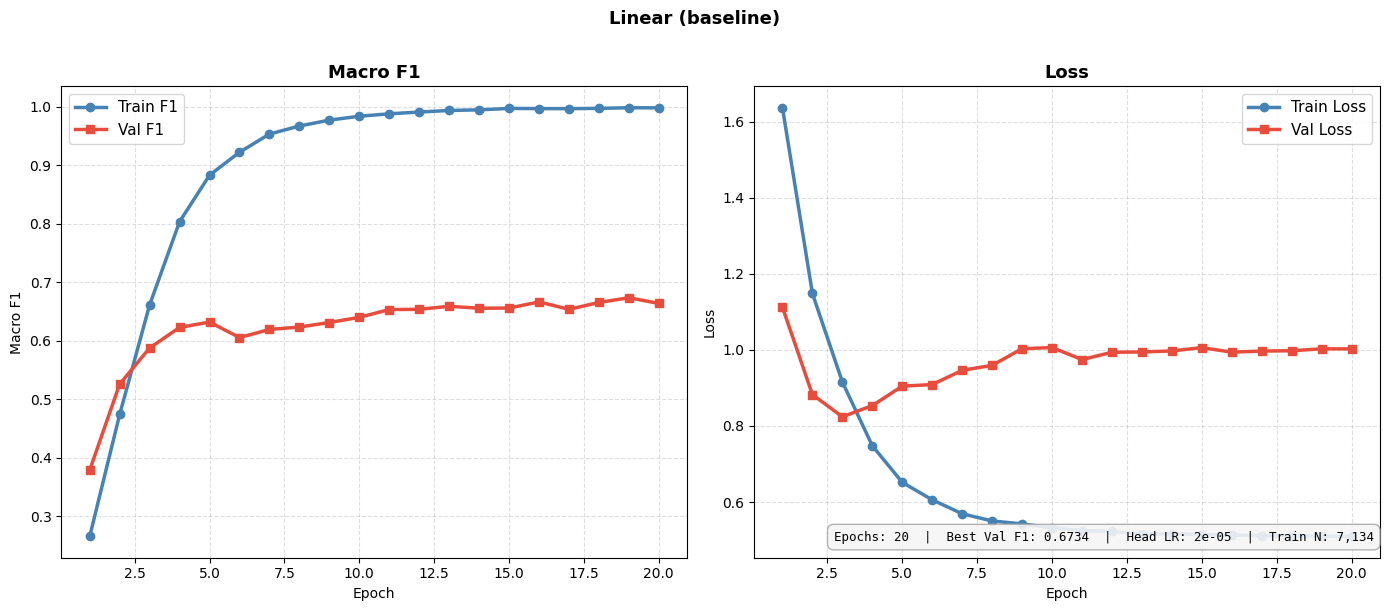

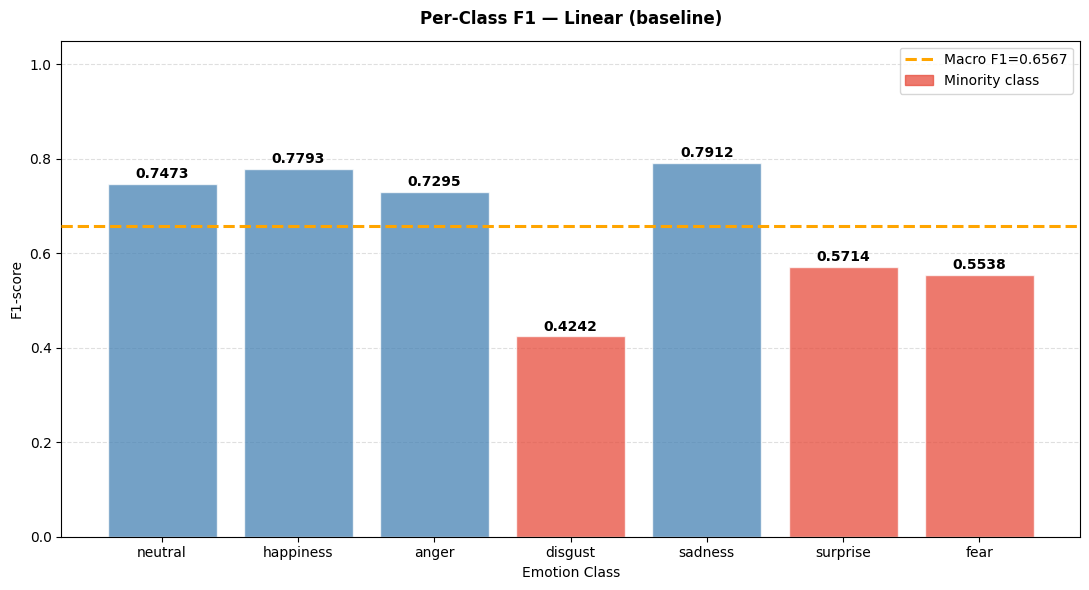

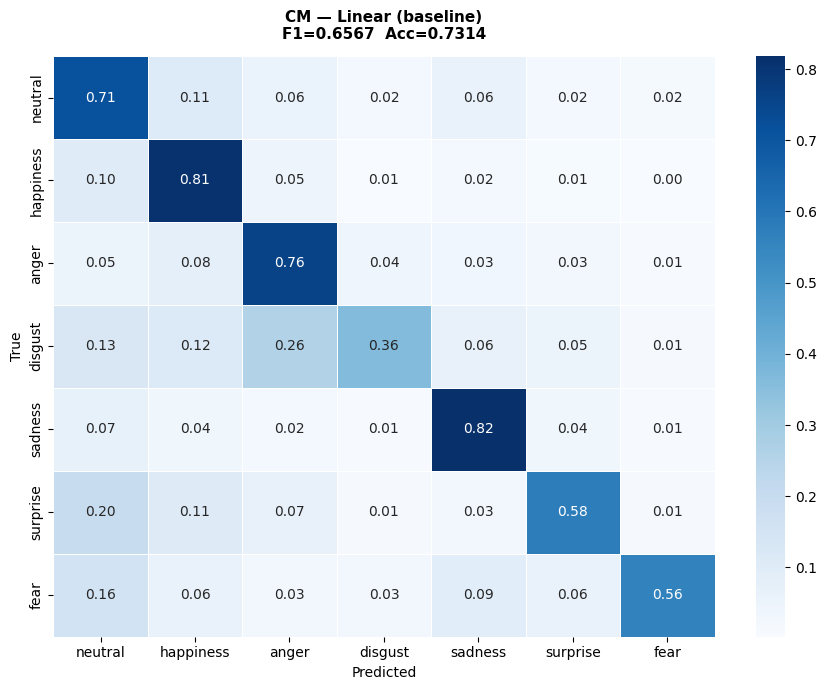


  LINEAR HEAD — Twitter-RoBERTa-large + Attention Pool + LS

                   Head LR Pooling  Epochs  Accuracy  Macro P  Macro R  Macro F1  Weighted F1  Val F1
Method                                                                                               
Linear (baseline)  0.00002    Attn      20    0.7314   0.6602   0.6581    0.6567       0.7288  0.6734

  PER-CLASS F1

                   neutral  happiness   anger  disgust  sadness  surprise    fear
Method                                                                           
Linear (baseline)   0.7473     0.7793  0.7295   0.4242   0.7912    0.5714  0.5538

🏆 Linear head Macro F1 = 0.6567

Saved to: linear_only/


In [4]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import re
import random
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
 
# ============================================================
# КОНФИГУРАЦИЯ
# ============================================================
 
ROBERTA_NAME    = "Tanneru/Emotion-Classification-DeBERTa-v3-Large"
MAX_LEN         = 128
BATCH_SIZE      = 64
EPOCHS          = 20
ENCODER_LR      = 1e-5
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
PATIENCE        = 5
SEED            = 42
 
# DataLoader
NUM_WORKERS     = 4
PIN_MEMORY      = True
 
# Mixed precision (FP16 для V100 — нативная поддержка через Tensor Cores)
USE_AMP         = True
AMP_DTYPE       = torch.float16
 
emotion_classes  = ["neutral", "happiness", "anger", "disgust", "sadness", "surprise", "fear"]
CLASS_TO_ID      = {cls: i for i, cls in enumerate(emotion_classes)}
MINORITY_CLASSES = ["fear", "disgust", "surprise"]
 
SPLITS_DIR = "splits_deberta"
OUTPUT_DIR = "linear_only"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"AMP: {USE_AMP}  |  dtype: {AMP_DTYPE}  |  Batch: {BATCH_SIZE}  |  Encoder LR: {ENCODER_LR}")
 
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
 
# ============================================================
# ЛОСС
# ============================================================
 
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
 
    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_prob  = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            dist = torch.full_like(log_prob, self.smoothing / (n_classes - 1))
            dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(dist * log_prob).sum(dim=-1).mean()
 
# ============================================================
# ATTENTION POOLING
# ============================================================
 
class AttentionPooling(nn.Module):
    """
    Bahdanau-style attention pooling.
    attention_dim = H/4 — стандартное соотношение.
    Маскирование через -1e4 — безопасно для FP16
    (-1e9 переполнило бы FP16, диапазон ±65504).
    """
    def __init__(self, hidden_size):
        super().__init__()
        attention_dim  = hidden_size // 4
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, attention_dim),
            nn.Tanh(),
            nn.Linear(attention_dim, 1),
        )
 
    def forward(self, hidden_states, attention_mask):
        scores  = self.attention(hidden_states)                       # [B, T, 1]
        scores  = scores.masked_fill(
            attention_mask.unsqueeze(-1) == 0, -1e4)                  # FP16-safe
        weights = torch.softmax(scores, dim=1)                        # [B, T, 1]
        return (hidden_states * weights).sum(dim=1)                   # [B, H]
 
 
# ============================================================
# LINEAR HEAD
# ============================================================
 
class RobertaLinearHead(nn.Module):
    HEAD_LR = 2e-5
    USES_POOLING = True
 
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling    = AttentionPooling(H)
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(H, num_labels)
 
    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        pooled = self.pooling(seq, attention_mask)
        return self.classifier(self.dropout(pooled))
 
    def head_parameters(self):
        return list(self.pooling.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())
 
 
# ============================================================
# OPTIMIZER
# ============================================================
 
def build_optimizer(model, encoder_lr, head_lr, weight_decay):
    encoder_params = list(model.backbone.parameters())
    head_params    = model.head_parameters()
    no_decay = ("bias", "LayerNorm.weight", "layer_norm.weight")
 
    def split_decay(params, lr):
        decay, no_dec = [], []
        for n, p in params:
            if any(nd in n for nd in no_decay):
                no_dec.append(p)
            else:
                decay.append(p)
        return [
            {"params": decay,  "lr": lr, "weight_decay": weight_decay},
            {"params": no_dec, "lr": lr, "weight_decay": 0.0},
        ]
 
    encoder_named = list(model.backbone.named_parameters())
    head_named    = [(f"head.{i}", p) for i, p in enumerate(head_params)]
 
    groups = split_decay(encoder_named, encoder_lr) + \
             split_decay(head_named,    head_lr)
 
    return torch.optim.AdamW(groups, eps=1e-6)
 
 
# ============================================================
# TRAIN / EVAL — с FP16 autocast
# ============================================================
 
def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)
 
        optimizer.zero_grad(set_to_none=True)
 
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
            loss   = criterion(logits, labs)
 
        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
 
        scheduler.step()
 
        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).detach().cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")
 
 
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    ce = nn.CrossEntropyLoss()
    for batch in tqdm(loader, desc="  eval", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)
 
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
 
        # Loss и softmax считаем в FP32 для численной устойчивости метрик
        logits_fp32 = logits.float()
        total_loss += ce(logits_fp32, labs).item()
        probs = torch.softmax(logits_fp32, 1).cpu().numpy()
        all_preds.extend(probs.argmax(1))
        all_labels.extend(labs.cpu().numpy())
    return (total_loss / len(loader),
            f1_score(all_labels, all_preds, average="macro"),
            np.array(all_preds), np.array(all_labels))
 
# ============================================================
# ЭКСПЕРИМЕНТ
# ============================================================
 
def run_experiment(model_class, display_name,
                   train_df, val_df, test_df, tokenizer):
    print(f"\n{'='*60}")
    print(f"  {display_name}")
    print(f"  Head LR: {model_class.HEAD_LR}  |  Encoder LR: {ENCODER_LR}")
    print(f"{'='*60}")
 
    set_seed(SEED)
    num_labels = len(emotion_classes)
 
    X_train, y_train = train_df["tweet_text"], train_df["label_id"]
    X_val,   y_val   = val_df["tweet_text"],   val_df["label_id"]
    X_test,  y_test  = test_df["tweet_text"],  test_df["label_id"]
 
    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
 
    tr_loader = DataLoader(
        TweetDataset(X_train, y_train, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    va_loader = DataLoader(
        TweetDataset(X_val, y_val, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    te_loader = DataLoader(
        TweetDataset(X_test, y_test, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
 
    set_seed(SEED)
    model     = model_class(ROBERTA_NAME, num_labels).to(device)
    optimizer = build_optimizer(model,
                                encoder_lr   = ENCODER_LR,
                                head_lr      = model_class.HEAD_LR,
                                weight_decay = WEIGHT_DECAY)
    total_steps = len(tr_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * WARMUP_RATIO), total_steps)
 
    scaler = GradScaler('cuda', enabled=USE_AMP)
 
    best_f1, patience_cnt, best_state = 0.0, 0, None
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
 
    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_f1 = train_epoch(model, tr_loader, optimizer, scheduler, criterion, scaler)
        va_loss, va_f1, _, _ = evaluate(model, va_loader)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1);     history["val_f1"].append(va_f1)
 
        print(f"  Ep {ep}/{EPOCHS}  "
              f"trL={tr_loss:.4f} trF1={tr_f1:.4f}  "
              f"vaL={va_loss:.4f} vaF1={va_f1:.4f}", end="")
 
        if va_f1 > best_f1:
            best_f1, patience_cnt = va_f1, 0
            best_state = deepcopy(model.state_dict())
            print("  ✓")
        else:
            patience_cnt += 1
            print(f"  ⏳ {patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"  Early stop at epoch {ep}"); break
 
    model.load_state_dict(best_state)
    te_loss, te_f1, te_preds, te_labels = evaluate(model, te_loader)
 
    rep     = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4,
                                    output_dict=True)
    rep_str = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4)
    print(f"\n  Test loss={te_loss:.4f}  Macro F1={te_f1:.4f}")
    print(rep_str)
 
    # Освобождаем VRAM
    del model, optimizer, scheduler, scaler, best_state
    torch.cuda.empty_cache()
 
    result = {
        "variant":              display_name,
        "head_lr":              model_class.HEAD_LR,
        "uses_pooling":         model_class.USES_POOLING,
        "train_size":           len(X_train),
        "epochs_trained":       len(history["train_loss"]),
        "best_val_f1":          best_f1,
        "test_loss":            te_loss,
        "test_accuracy":        rep["accuracy"],
        "test_macro_precision": rep["macro avg"]["precision"],
        "test_macro_recall":    rep["macro avg"]["recall"],
        "test_macro_f1":        rep["macro avg"]["f1-score"],
        "test_weighted_f1":     rep["weighted avg"]["f1-score"],
        "history":              history,
        "report_dict":          rep,
        "test_preds":           te_preds,
        "test_labels":          te_labels,
    }
    for cls in emotion_classes:
        result[f"f1_{cls}"] = rep[cls]["f1-score"] if cls in rep else 0.0
    return result
 
# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================
 
loaders, meta = load_splits(splits_dir=SPLITS_DIR)
train_df  = meta["train_df"]
val_df    = meta["val_df"]
test_df   = meta["test_df"]
tokenizer = meta["tokenizer"]
 
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
 
# ============================================================
# ЗАПУСК
# ============================================================
 
result = run_experiment(
    model_class  = RobertaLinearHead,
    display_name = "Linear (baseline)",
    train_df     = train_df,
    val_df       = val_df,
    test_df      = test_df,
    tokenizer    = tokenizer,
)
 
# ============================================================
# ГРАФИКИ
# ============================================================
 
plt.rcParams['font.family'] = 'DejaVu Sans'
PROPS_BOX  = dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5',
                  edgecolor='#aaaaaa', alpha=0.9)
 
 
def plot_training_curves(result, output_dir):
    ep = range(1, len(result["history"]["train_f1"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('white')
    for ax in axes:
        ax.set_facecolor('white')
        ax.grid(True, ls='--', alpha=0.4, zorder=1)
        ax.set_axisbelow(True)
    axes[0].plot(ep, result["history"]["train_f1"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train F1", zorder=3)
    axes[0].plot(ep, result["history"]["val_f1"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val F1", zorder=3)
    axes[0].set_title("Macro F1", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Macro F1")
    axes[0].legend(fontsize=11)
 
    axes[1].plot(ep, result["history"]["train_loss"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train Loss", zorder=3)
    axes[1].plot(ep, result["history"]["val_loss"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val Loss", zorder=3)
    axes[1].set_title("Loss", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(fontsize=11)
 
    stats = (f"Epochs: {result['epochs_trained']}  |  "
             f"Best Val F1: {result['best_val_f1']:.4f}  |  "
             f"Head LR: {result['head_lr']}  |  "
             f"Train N: {result['train_size']:,}")
    axes[1].text(0.99, 0.03, stats, transform=axes[1].transAxes, fontsize=9,
                 va='bottom', ha='right', bbox=PROPS_BOX, family='monospace')
 
    plt.suptitle(result["variant"], fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"curves_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
def plot_per_class_f1(result, output_dir):
    from matplotlib.patches import Patch
    rep = result["report_dict"]
    f1s = [rep[c]["f1-score"] if c in rep else 0 for c in emotion_classes]
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')
 
    colors = ["#e74c3c" if c in MINORITY_CLASSES else "steelblue"
              for c in emotion_classes]
    bars = ax.bar(emotion_classes, f1s, color=colors, alpha=0.75,
                  edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
 
    ax.axhline(result["test_macro_f1"], color="#FFA500", ls="--", lw=2.2,
               zorder=3, label=f"Macro F1={result['test_macro_f1']:.4f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
    ax.set_title(f"Per-Class F1 — {result['variant']}",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
    ax.legend(handles=[
        plt.Line2D([0], [0], color="#FFA500", ls="--", lw=2.2,
                   label=f"Macro F1={result['test_macro_f1']:.4f}"),
        Patch(color='#e74c3c', alpha=0.75, label='Minority class'),
    ], fontsize=10)
 
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"perclass_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
def plot_confusion_matrix(result, output_dir):
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')
    cm   = confusion_matrix(result["test_labels"], result["test_preds"])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_classes, yticklabels=emotion_classes,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f"CM — {result['variant']}\n"
                 f"F1={result['test_macro_f1']:.4f}  "
                 f"Acc={result['test_accuracy']:.4f}",
                 fontsize=11, fontweight="bold", pad=12)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"cm_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
plot_training_curves(result, OUTPUT_DIR)
plot_per_class_f1(result, OUTPUT_DIR)
plot_confusion_matrix(result, OUTPUT_DIR)
 
# ============================================================
# ИТОГОВАЯ ТАБЛИЦА
# ============================================================
 
print(f"\n{'='*120}")
print("  LINEAR HEAD — Twitter-RoBERTa-large + Attention Pool + LS")
print(f"{'='*120}\n")
 
summary_row = {
    "Method":      result["variant"],
    "Head LR":     result["head_lr"],
    "Pooling":     "Attn" if result["uses_pooling"] else "bypass",
    "Epochs":      result["epochs_trained"],
    "Accuracy":    round(result["test_accuracy"], 4),
    "Macro P":     round(result["test_macro_precision"], 4),
    "Macro R":     round(result["test_macro_recall"], 4),
    "Macro F1":    round(result["test_macro_f1"], 4),
    "Weighted F1": round(result["test_weighted_f1"], 4),
    "Val F1":      round(result["best_val_f1"], 4),
}
 
summary_df = pd.DataFrame([summary_row]).set_index("Method")
print(summary_df.to_string())
 
print(f"\n{'='*120}")
print("  PER-CLASS F1")
print(f"{'='*120}\n")
 
pc_row = {"Method": result["variant"],
          **{c: round(result.get(f"f1_{c}", 0), 4) for c in emotion_classes}}
pc_df = pd.DataFrame([pc_row]).set_index("Method")
print(pc_df.to_string())
 
# Сохранение
summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"))
pc_df.to_csv(os.path.join(OUTPUT_DIR, "per_class_f1.csv"))
 
print(f"\n🏆 Linear head Macro F1 = {result['test_macro_f1']:.4f}")
print(f"\nSaved to: {OUTPUT_DIR}/")

Device: cuda
AMP: True  |  dtype: torch.float16  |  Batch: 64  |  Encoder LR: 1e-05
Splits loaded from: splits_deberta/
  Train: 7134 | Val: 1260 | Test: 1482

  Train samples per class:
    id=0  neutral     :  2313
    id=1  happiness   :  1745
    id=2  anger       :  1129
    id=3  disgust     :   368
    id=4  sadness     :  1057
    id=5  surprise    :   368
    id=6  fear        :   154
Train: 7134 | Val: 1260 | Test: 1482

  Linear (baseline)
  Head LR: 2e-05  |  Encoder LR: 1e-05


Loading weights: 100%|████████████████████████████████████████████████████████| 390/390 [00:00<00:00, 5327.73it/s]
DebertaV2Model LOAD REPORT from: Tanneru/Emotion-Classification-DeBERTa-v3-Large
Key                 | Status     |  | 
--------------------+------------+--+-
pooler.dense.bias   | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 
classifier.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
                                                                                                                  

  Ep 1/20  trL=1.7142 trF1=0.2346  vaL=1.1559 vaF1=0.3972  ✓


  Ep 2/20  trL=1.1840 trF1=0.4825  vaL=0.8895 vaF1=0.5230  ✓


  Ep 3/20  trL=0.9617 trF1=0.6419  vaL=0.8102 vaF1=0.5661  ✓


...

  Ep 12/20  trL=0.5255 trF1=0.9913  vaL=0.9775 vaF1=0.6429  ⏳ 2/5


  Ep 13/20  trL=0.5238 trF1=0.9902  vaL=0.9855 vaF1=0.6597  ⏳ 3/5


  Ep 14/20  trL=0.5197 trF1=0.9935  vaL=1.0048 vaF1=0.6476  ⏳ 4/5


  Ep 15/20  trL=0.5175 trF1=0.9946  vaL=0.9947 vaF1=0.6521  ⏳ 5/5
  Early stop at epoch 15



  Test loss=1.0111  Macro F1=0.6630
              precision    recall  f1-score   support

     neutral     0.8059    0.6819    0.7387       481
   happiness     0.7512    0.8425    0.7943       362
       anger     0.7384    0.7479    0.7431       234
     disgust     0.5424    0.4156    0.4706        77
     sadness     0.7676    0.8409    0.8026       220
    surprise     0.5495    0.6579    0.5988        76
        fear     0.4390    0.5625    0.4932        32

    accuracy                         0.7375      1482
   macro avg     0.6563    0.6785    0.6630      1482
weighted avg     0.7414    0.7375    0.7361      1482



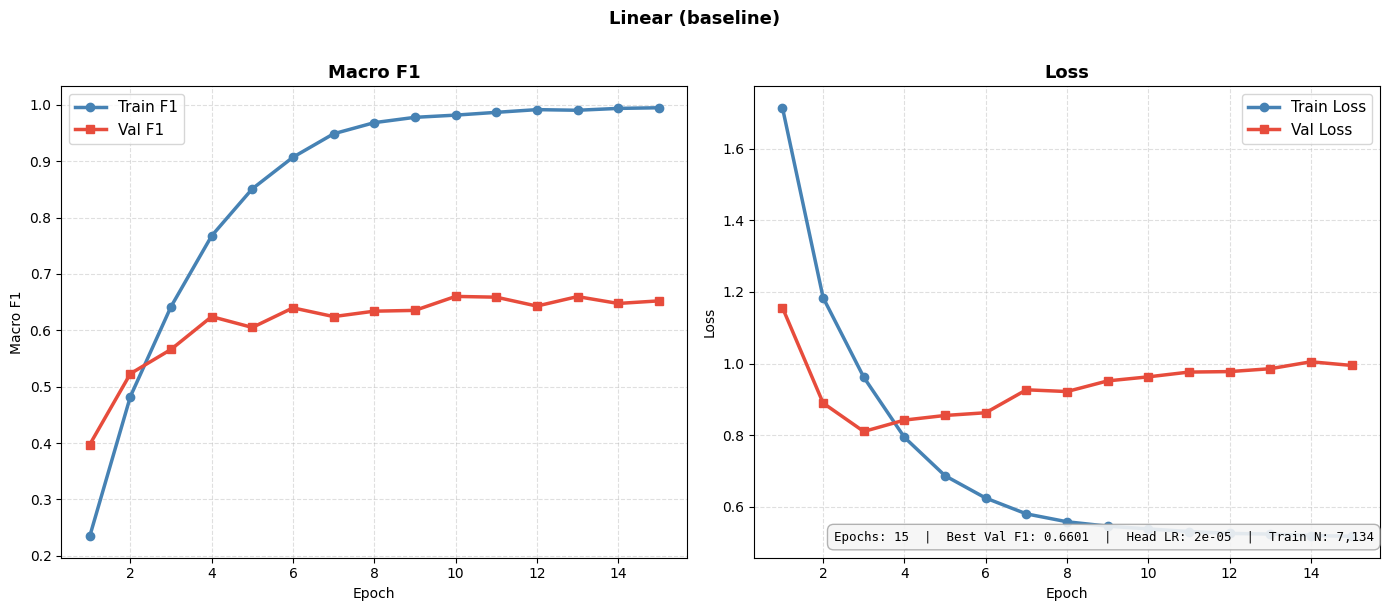

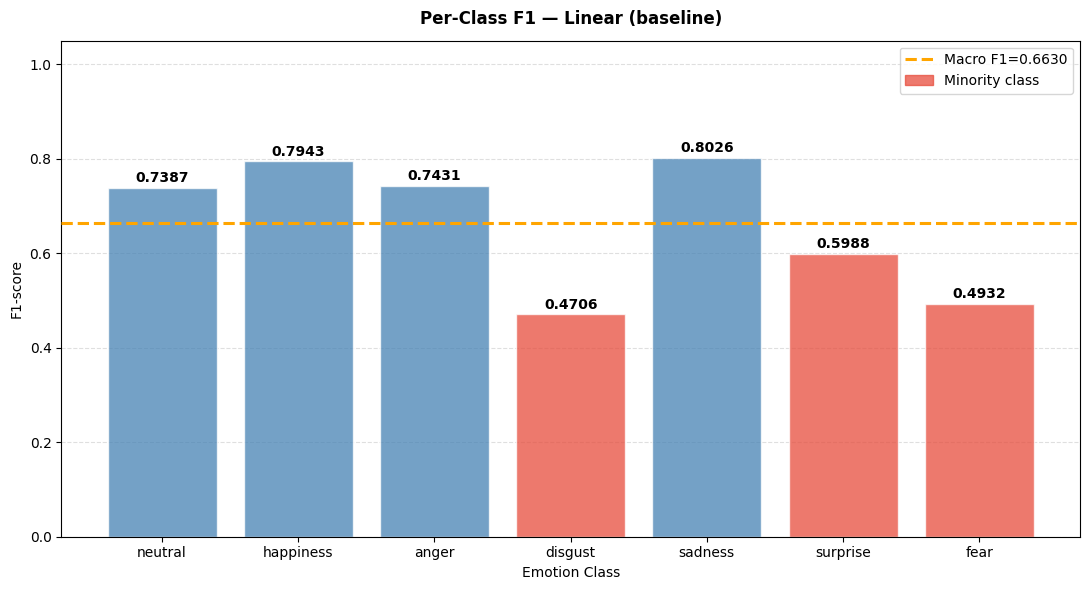

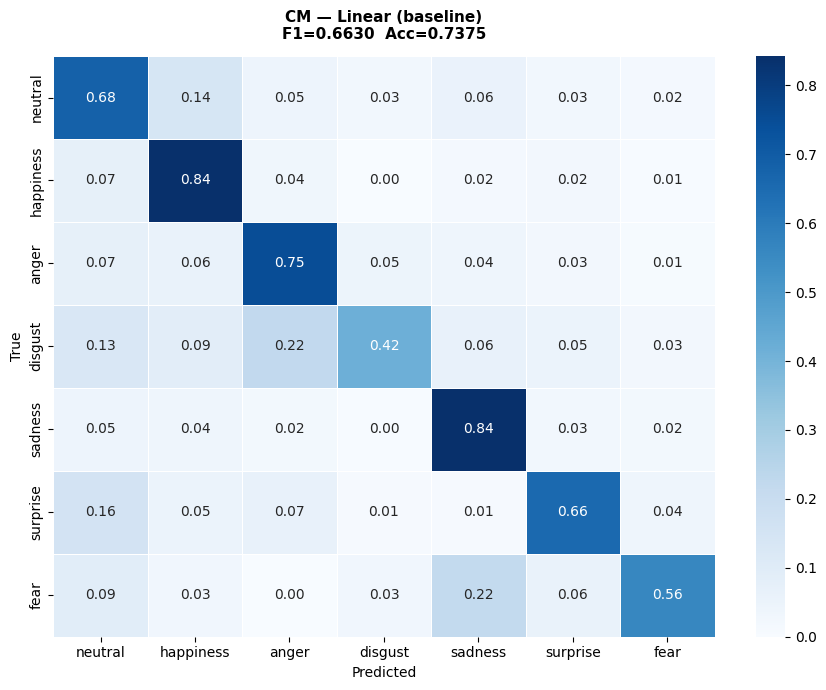


  LINEAR HEAD — Twitter-RoBERTa-large + Attention Pool + LS

                   Head LR Pooling  Epochs  Accuracy  Macro P  Macro R  Macro F1  Weighted F1  Val F1
Method                                                                                               
Linear (baseline)  0.00002    Attn      15    0.7375   0.6563   0.6785     0.663       0.7361  0.6601

  PER-CLASS F1

                   neutral  happiness   anger  disgust  sadness  surprise    fear
Method                                                                           
Linear (baseline)   0.7387     0.7943  0.7431   0.4706   0.8026    0.5988  0.4932

🏆 Linear head Macro F1 = 0.6630

Saved to: linear_only/


In [5]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import re
import random
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
 
# ============================================================
# КОНФИГУРАЦИЯ
# ============================================================
 
ROBERTA_NAME    = "Tanneru/Emotion-Classification-DeBERTa-v3-Large"
MAX_LEN         = 128
BATCH_SIZE      = 64
EPOCHS          = 20
ENCODER_LR      = 1e-5
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
PATIENCE        = 5
SEED            = 42
 
# DataLoader
NUM_WORKERS     = 4
PIN_MEMORY      = True
 
# Mixed precision (FP16 для V100 — нативная поддержка через Tensor Cores)
USE_AMP         = True
AMP_DTYPE       = torch.float16
 
emotion_classes  = ["neutral", "happiness", "anger", "disgust", "sadness", "surprise", "fear"]
CLASS_TO_ID      = {cls: i for i, cls in enumerate(emotion_classes)}
MINORITY_CLASSES = ["fear", "disgust", "surprise"]
 
SPLITS_DIR = "splits_deberta"
OUTPUT_DIR = "linear_only"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"AMP: {USE_AMP}  |  dtype: {AMP_DTYPE}  |  Batch: {BATCH_SIZE}  |  Encoder LR: {ENCODER_LR}")
 
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
 
# ============================================================
# ЛОСС
# ============================================================
 
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
 
    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_prob  = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            dist = torch.full_like(log_prob, self.smoothing / (n_classes - 1))
            dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(dist * log_prob).sum(dim=-1).mean()
 
# ============================================================
# ATTENTION POOLING
# ============================================================
 
# ============================================================
# CLS POOLING
# ============================================================

class CLSPooling(nn.Module):
    """
    Берёт hidden state первого токена (CLS / <s>).
    Стандартный pooling для BERT-style моделей.
    attention_mask не используется — CLS всегда в позиции 0.
    """
    def forward(self, hidden_states, attention_mask=None):
        return hidden_states[:, 0, :]  # [B, H]


# ============================================================
# LINEAR HEAD
# ============================================================

class RobertaLinearHead(nn.Module):
    HEAD_LR = 2e-5
    USES_POOLING = True  # технически CLS — это тоже pooling

    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling    = CLSPooling()
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(H, num_labels)

    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        pooled = self.pooling(seq, attention_mask)
        return self.classifier(self.dropout(pooled))

    def head_parameters(self):
        # У CLSPooling нет параметров, но оставляем для совместимости
        return list(self.pooling.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())
 
 
# ============================================================
# OPTIMIZER
# ============================================================
 
def build_optimizer(model, encoder_lr, head_lr, weight_decay):
    encoder_params = list(model.backbone.parameters())
    head_params    = model.head_parameters()
    no_decay = ("bias", "LayerNorm.weight", "layer_norm.weight")
 
    def split_decay(params, lr):
        decay, no_dec = [], []
        for n, p in params:
            if any(nd in n for nd in no_decay):
                no_dec.append(p)
            else:
                decay.append(p)
        return [
            {"params": decay,  "lr": lr, "weight_decay": weight_decay},
            {"params": no_dec, "lr": lr, "weight_decay": 0.0},
        ]
 
    encoder_named = list(model.backbone.named_parameters())
    head_named    = [(f"head.{i}", p) for i, p in enumerate(head_params)]
 
    groups = split_decay(encoder_named, encoder_lr) + \
             split_decay(head_named,    head_lr)
 
    return torch.optim.AdamW(groups, eps=1e-6)
 
 
# ============================================================
# TRAIN / EVAL — с FP16 autocast
# ============================================================
 
def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)
 
        optimizer.zero_grad(set_to_none=True)
 
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
            loss   = criterion(logits, labs)
 
        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
 
        scheduler.step()
 
        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).detach().cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")
 
 
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    ce = nn.CrossEntropyLoss()
    for batch in tqdm(loader, desc="  eval", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)
 
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
 
        # Loss и softmax считаем в FP32 для численной устойчивости метрик
        logits_fp32 = logits.float()
        total_loss += ce(logits_fp32, labs).item()
        probs = torch.softmax(logits_fp32, 1).cpu().numpy()
        all_preds.extend(probs.argmax(1))
        all_labels.extend(labs.cpu().numpy())
    return (total_loss / len(loader),
            f1_score(all_labels, all_preds, average="macro"),
            np.array(all_preds), np.array(all_labels))
 
# ============================================================
# ЭКСПЕРИМЕНТ
# ============================================================
 
def run_experiment(model_class, display_name,
                   train_df, val_df, test_df, tokenizer):
    print(f"\n{'='*60}")
    print(f"  {display_name}")
    print(f"  Head LR: {model_class.HEAD_LR}  |  Encoder LR: {ENCODER_LR}")
    print(f"{'='*60}")
 
    set_seed(SEED)
    num_labels = len(emotion_classes)
 
    X_train, y_train = train_df["tweet_text"], train_df["label_id"]
    X_val,   y_val   = val_df["tweet_text"],   val_df["label_id"]
    X_test,  y_test  = test_df["tweet_text"],  test_df["label_id"]
 
    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
 
    tr_loader = DataLoader(
        TweetDataset(X_train, y_train, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    va_loader = DataLoader(
        TweetDataset(X_val, y_val, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    te_loader = DataLoader(
        TweetDataset(X_test, y_test, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
 
    set_seed(SEED)
    model     = model_class(ROBERTA_NAME, num_labels).to(device)
    optimizer = build_optimizer(model,
                                encoder_lr   = ENCODER_LR,
                                head_lr      = model_class.HEAD_LR,
                                weight_decay = WEIGHT_DECAY)
    total_steps = len(tr_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * WARMUP_RATIO), total_steps)
 
    scaler = GradScaler('cuda', enabled=USE_AMP)
 
    best_f1, patience_cnt, best_state = 0.0, 0, None
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
 
    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_f1 = train_epoch(model, tr_loader, optimizer, scheduler, criterion, scaler)
        va_loss, va_f1, _, _ = evaluate(model, va_loader)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1);     history["val_f1"].append(va_f1)
 
        print(f"  Ep {ep}/{EPOCHS}  "
              f"trL={tr_loss:.4f} trF1={tr_f1:.4f}  "
              f"vaL={va_loss:.4f} vaF1={va_f1:.4f}", end="")
 
        if va_f1 > best_f1:
            best_f1, patience_cnt = va_f1, 0
            best_state = deepcopy(model.state_dict())
            print("  ✓")
        else:
            patience_cnt += 1
            print(f"  ⏳ {patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"  Early stop at epoch {ep}"); break
 
    model.load_state_dict(best_state)
    te_loss, te_f1, te_preds, te_labels = evaluate(model, te_loader)
 
    rep     = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4,
                                    output_dict=True)
    rep_str = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4)
    print(f"\n  Test loss={te_loss:.4f}  Macro F1={te_f1:.4f}")
    print(rep_str)
 
    # Освобождаем VRAM
    del model, optimizer, scheduler, scaler, best_state
    torch.cuda.empty_cache()
 
    result = {
        "variant":              display_name,
        "head_lr":              model_class.HEAD_LR,
        "uses_pooling":         model_class.USES_POOLING,
        "train_size":           len(X_train),
        "epochs_trained":       len(history["train_loss"]),
        "best_val_f1":          best_f1,
        "test_loss":            te_loss,
        "test_accuracy":        rep["accuracy"],
        "test_macro_precision": rep["macro avg"]["precision"],
        "test_macro_recall":    rep["macro avg"]["recall"],
        "test_macro_f1":        rep["macro avg"]["f1-score"],
        "test_weighted_f1":     rep["weighted avg"]["f1-score"],
        "history":              history,
        "report_dict":          rep,
        "test_preds":           te_preds,
        "test_labels":          te_labels,
    }
    for cls in emotion_classes:
        result[f"f1_{cls}"] = rep[cls]["f1-score"] if cls in rep else 0.0
    return result
 
# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================
 
loaders, meta = load_splits(splits_dir=SPLITS_DIR)
train_df  = meta["train_df"]
val_df    = meta["val_df"]
test_df   = meta["test_df"]
tokenizer = meta["tokenizer"]
 
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
 
# ============================================================
# ЗАПУСК
# ============================================================
 
result = run_experiment(
    model_class  = RobertaLinearHead,
    display_name = "Linear (baseline)",
    train_df     = train_df,
    val_df       = val_df,
    test_df      = test_df,
    tokenizer    = tokenizer,
)
 
# ============================================================
# ГРАФИКИ
# ============================================================
 
plt.rcParams['font.family'] = 'DejaVu Sans'
PROPS_BOX  = dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5',
                  edgecolor='#aaaaaa', alpha=0.9)
 
 
def plot_training_curves(result, output_dir):
    ep = range(1, len(result["history"]["train_f1"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('white')
    for ax in axes:
        ax.set_facecolor('white')
        ax.grid(True, ls='--', alpha=0.4, zorder=1)
        ax.set_axisbelow(True)
    axes[0].plot(ep, result["history"]["train_f1"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train F1", zorder=3)
    axes[0].plot(ep, result["history"]["val_f1"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val F1", zorder=3)
    axes[0].set_title("Macro F1", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Macro F1")
    axes[0].legend(fontsize=11)
 
    axes[1].plot(ep, result["history"]["train_loss"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train Loss", zorder=3)
    axes[1].plot(ep, result["history"]["val_loss"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val Loss", zorder=3)
    axes[1].set_title("Loss", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(fontsize=11)
 
    stats = (f"Epochs: {result['epochs_trained']}  |  "
             f"Best Val F1: {result['best_val_f1']:.4f}  |  "
             f"Head LR: {result['head_lr']}  |  "
             f"Train N: {result['train_size']:,}")
    axes[1].text(0.99, 0.03, stats, transform=axes[1].transAxes, fontsize=9,
                 va='bottom', ha='right', bbox=PROPS_BOX, family='monospace')
 
    plt.suptitle(result["variant"], fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"curves_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
def plot_per_class_f1(result, output_dir):
    from matplotlib.patches import Patch
    rep = result["report_dict"]
    f1s = [rep[c]["f1-score"] if c in rep else 0 for c in emotion_classes]
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')
 
    colors = ["#e74c3c" if c in MINORITY_CLASSES else "steelblue"
              for c in emotion_classes]
    bars = ax.bar(emotion_classes, f1s, color=colors, alpha=0.75,
                  edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
 
    ax.axhline(result["test_macro_f1"], color="#FFA500", ls="--", lw=2.2,
               zorder=3, label=f"Macro F1={result['test_macro_f1']:.4f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
    ax.set_title(f"Per-Class F1 — {result['variant']}",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
    ax.legend(handles=[
        plt.Line2D([0], [0], color="#FFA500", ls="--", lw=2.2,
                   label=f"Macro F1={result['test_macro_f1']:.4f}"),
        Patch(color='#e74c3c', alpha=0.75, label='Minority class'),
    ], fontsize=10)
 
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"perclass_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
def plot_confusion_matrix(result, output_dir):
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')
    cm   = confusion_matrix(result["test_labels"], result["test_preds"])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_classes, yticklabels=emotion_classes,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f"CM — {result['variant']}\n"
                 f"F1={result['test_macro_f1']:.4f}  "
                 f"Acc={result['test_accuracy']:.4f}",
                 fontsize=11, fontweight="bold", pad=12)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"cm_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
plot_training_curves(result, OUTPUT_DIR)
plot_per_class_f1(result, OUTPUT_DIR)
plot_confusion_matrix(result, OUTPUT_DIR)
 
# ============================================================
# ИТОГОВАЯ ТАБЛИЦА
# ============================================================
 
print(f"\n{'='*120}")
print("  LINEAR HEAD — Twitter-RoBERTa-large + Attention Pool + LS")
print(f"{'='*120}\n")
 
summary_row = {
    "Method":      result["variant"],
    "Head LR":     result["head_lr"],
    "Pooling":     "Attn" if result["uses_pooling"] else "bypass",
    "Epochs":      result["epochs_trained"],
    "Accuracy":    round(result["test_accuracy"], 4),
    "Macro P":     round(result["test_macro_precision"], 4),
    "Macro R":     round(result["test_macro_recall"], 4),
    "Macro F1":    round(result["test_macro_f1"], 4),
    "Weighted F1": round(result["test_weighted_f1"], 4),
    "Val F1":      round(result["best_val_f1"], 4),
}
 
summary_df = pd.DataFrame([summary_row]).set_index("Method")
print(summary_df.to_string())
 
print(f"\n{'='*120}")
print("  PER-CLASS F1")
print(f"{'='*120}\n")
 
pc_row = {"Method": result["variant"],
          **{c: round(result.get(f"f1_{c}", 0), 4) for c in emotion_classes}}
pc_df = pd.DataFrame([pc_row]).set_index("Method")
print(pc_df.to_string())
 
# Сохранение
summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"))
pc_df.to_csv(os.path.join(OUTPUT_DIR, "per_class_f1.csv"))
 
print(f"\n🏆 Linear head Macro F1 = {result['test_macro_f1']:.4f}")
print(f"\nSaved to: {OUTPUT_DIR}/")

Device: cuda
AMP: True  |  dtype: torch.float16  |  Batch: 64  |  Encoder LR: 1e-05
Splits loaded from: splits_modernbert/
  Train: 7134 | Val: 1260 | Test: 1482

  Train samples per class:
    id=0  neutral     :  2313
    id=1  happiness   :  1745
    id=2  anger       :  1129
    id=3  disgust     :   368
    id=4  sadness     :  1057
    id=5  surprise    :   368
    id=6  fear        :   154
Train: 7134 | Val: 1260 | Test: 1482

  Linear (baseline)
  Head LR: 0.0001  |  Encoder LR: 1e-05


Loading weights: 100%|████████████████████████████████████████████████████████| 170/170 [00:00<00:00, 4721.50it/s]
ModernBertModel LOAD REPORT from: cirimus/modernbert-large-go-emotions
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
                                                                                                                  

  Ep 1/20  trL=1.7598 trF1=0.2717  vaL=1.0978 vaF1=0.4281  ✓


  Ep 2/20  trL=1.1338 trF1=0.5293  vaL=0.8635 vaF1=0.5488  ✓


  Ep 3/20  trL=0.8972 trF1=0.7023  vaL=0.7997 vaF1=0.6148  ✓


...

  Ep 10/20  trL=0.5118 trF1=0.9986  vaL=0.9678 vaF1=0.6307  ⏳ 2/5


  Ep 11/20  trL=0.5108 trF1=0.9984  vaL=0.9739 vaF1=0.6284  ⏳ 3/5


  Ep 12/20  trL=0.5097 trF1=0.9994  vaL=0.9818 vaF1=0.6316  ⏳ 4/5


  Ep 13/20  trL=0.5096 trF1=0.9993  vaL=0.9851 vaF1=0.6272  ⏳ 5/5
  Early stop at epoch 13



  Test loss=0.9644  Macro F1=0.6488
              precision    recall  f1-score   support

     neutral     0.7357    0.7235    0.7296       481
   happiness     0.7294    0.7818    0.7547       362
       anger     0.6870    0.7222    0.7042       234
     disgust     0.5294    0.4675    0.4966        77
     sadness     0.7644    0.7227    0.7430       220
    surprise     0.5125    0.5395    0.5256        76
        fear     0.7895    0.4688    0.5882        32

    accuracy                         0.7092      1482
   macro avg     0.6783    0.6323    0.6488      1482
weighted avg     0.7097    0.7092    0.7081      1482



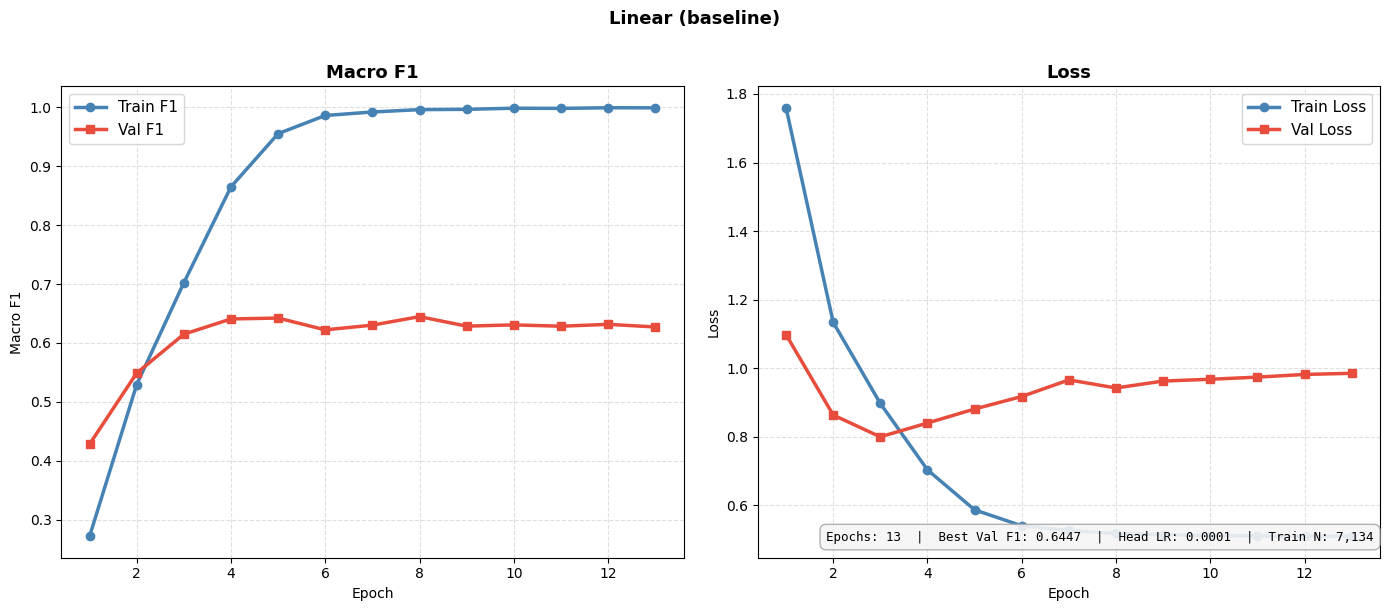

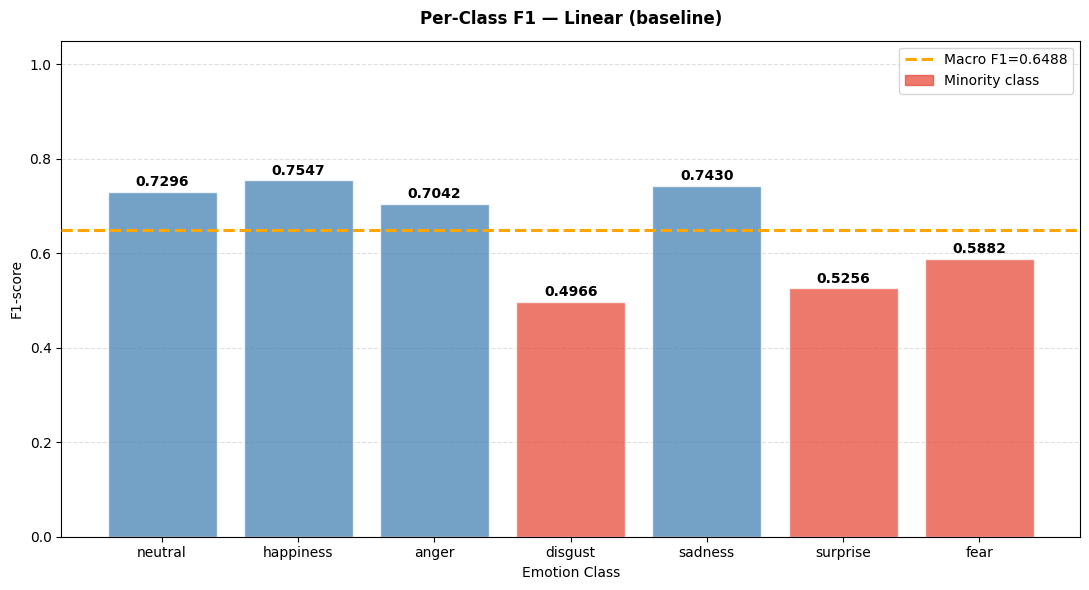

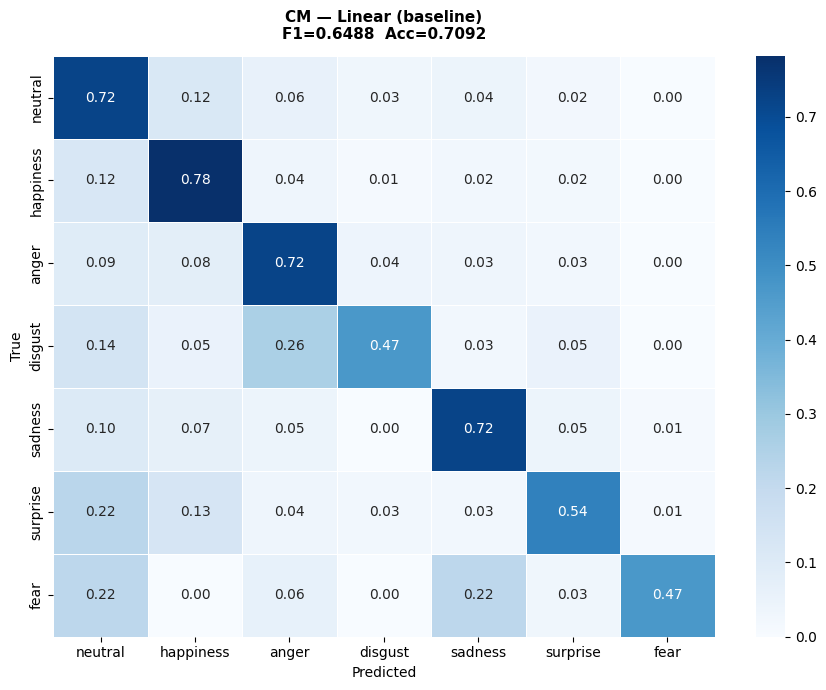


  LINEAR HEAD — Twitter-RoBERTa-large + Attention Pool + LS

                   Head LR Pooling  Epochs  Accuracy  Macro P  Macro R  Macro F1  Weighted F1  Val F1
Method                                                                                               
Linear (baseline)   0.0001    Attn      13    0.7092   0.6783   0.6323    0.6488       0.7081  0.6447

  PER-CLASS F1

                   neutral  happiness   anger  disgust  sadness  surprise    fear
Method                                                                           
Linear (baseline)   0.7296     0.7547  0.7042   0.4966    0.743    0.5256  0.5882

🏆 Linear head Macro F1 = 0.6488

Saved to: linear_only/


In [10]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import re
import random
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
 
# ============================================================
# КОНФИГУРАЦИЯ
# ============================================================
 
ROBERTA_NAME    = "cirimus/modernbert-large-go-emotions"
MAX_LEN         = 128
BATCH_SIZE      = 64
EPOCHS          = 20
ENCODER_LR      = 1e-5
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
PATIENCE        = 5
SEED            = 42
 
# DataLoader
NUM_WORKERS     = 4
PIN_MEMORY      = True
 
# Mixed precision (FP16 для V100 — нативная поддержка через Tensor Cores)
USE_AMP         = True
AMP_DTYPE       = torch.float16
 
emotion_classes  = ["neutral", "happiness", "anger", "disgust", "sadness", "surprise", "fear"]
CLASS_TO_ID      = {cls: i for i, cls in enumerate(emotion_classes)}
MINORITY_CLASSES = ["fear", "disgust", "surprise"]
 
SPLITS_DIR = "splits_modernbert"
OUTPUT_DIR = "linear_only"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"AMP: {USE_AMP}  |  dtype: {AMP_DTYPE}  |  Batch: {BATCH_SIZE}  |  Encoder LR: {ENCODER_LR}")
 
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
 
# ============================================================
# ЛОСС
# ============================================================
 
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
 
    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_prob  = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            dist = torch.full_like(log_prob, self.smoothing / (n_classes - 1))
            dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(dist * log_prob).sum(dim=-1).mean()
 
# ============================================================
# ATTENTION POOLING
# ============================================================
 
class AttentionPooling(nn.Module):
    """
    Bahdanau-style attention pooling.
    attention_dim = H/4 — стандартное соотношение.
    Маскирование через -1e4 — безопасно для FP16
    (-1e9 переполнило бы FP16, диапазон ±65504).
    """
    def __init__(self, hidden_size):
        super().__init__()
        attention_dim  = hidden_size // 4
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, attention_dim),
            nn.Tanh(),
            nn.Linear(attention_dim, 1),
        )
 
    def forward(self, hidden_states, attention_mask):
        scores  = self.attention(hidden_states)                       # [B, T, 1]
        scores  = scores.masked_fill(
            attention_mask.unsqueeze(-1) == 0, -1e4)                  # FP16-safe
        weights = torch.softmax(scores, dim=1)                        # [B, T, 1]
        return (hidden_states * weights).sum(dim=1)                   # [B, H]
 
 
# ============================================================
# LINEAR HEAD
# ============================================================
 
class RobertaLinearHead(nn.Module):
    HEAD_LR = 1e-4
    USES_POOLING = True
 
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.pooling    = AttentionPooling(H)
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(H, num_labels)
 
    def forward(self, input_ids, attention_mask):
        seq    = self.backbone(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state
        pooled = self.pooling(seq, attention_mask)
        return self.classifier(self.dropout(pooled))
 
    def head_parameters(self):
        return list(self.pooling.parameters()) + \
               list(self.dropout.parameters()) + \
               list(self.classifier.parameters())
 
 
# ============================================================
# OPTIMIZER
# ============================================================
 
def build_optimizer(model, encoder_lr, head_lr, weight_decay):
    encoder_params = list(model.backbone.parameters())
    head_params    = model.head_parameters()
    no_decay = ("bias", "LayerNorm.weight", "layer_norm.weight")
 
    def split_decay(params, lr):
        decay, no_dec = [], []
        for n, p in params:
            if any(nd in n for nd in no_decay):
                no_dec.append(p)
            else:
                decay.append(p)
        return [
            {"params": decay,  "lr": lr, "weight_decay": weight_decay},
            {"params": no_dec, "lr": lr, "weight_decay": 0.0},
        ]
 
    encoder_named = list(model.backbone.named_parameters())
    head_named    = [(f"head.{i}", p) for i, p in enumerate(head_params)]
 
    groups = split_decay(encoder_named, encoder_lr) + \
             split_decay(head_named,    head_lr)
 
    return torch.optim.AdamW(groups, eps=1e-6)
 
 
# ============================================================
# TRAIN / EVAL — с FP16 autocast
# ============================================================
 
def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)
 
        optimizer.zero_grad(set_to_none=True)
 
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
            loss   = criterion(logits, labs)
 
        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
 
        scheduler.step()
 
        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).detach().cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")
 
 
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    ce = nn.CrossEntropyLoss()
    for batch in tqdm(loader, desc="  eval", leave=False):
        ids  = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        labs = batch["labels"].to(device, non_blocking=True)
 
        with autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            logits = model(ids, mask)
 
        # Loss и softmax считаем в FP32 для численной устойчивости метрик
        logits_fp32 = logits.float()
        total_loss += ce(logits_fp32, labs).item()
        probs = torch.softmax(logits_fp32, 1).cpu().numpy()
        all_preds.extend(probs.argmax(1))
        all_labels.extend(labs.cpu().numpy())
    return (total_loss / len(loader),
            f1_score(all_labels, all_preds, average="macro"),
            np.array(all_preds), np.array(all_labels))
 
# ============================================================
# ЭКСПЕРИМЕНТ
# ============================================================
 
def run_experiment(model_class, display_name,
                   train_df, val_df, test_df, tokenizer):
    print(f"\n{'='*60}")
    print(f"  {display_name}")
    print(f"  Head LR: {model_class.HEAD_LR}  |  Encoder LR: {ENCODER_LR}")
    print(f"{'='*60}")
 
    set_seed(SEED)
    num_labels = len(emotion_classes)
 
    X_train, y_train = train_df["tweet_text"], train_df["label_id"]
    X_val,   y_val   = val_df["tweet_text"],   val_df["label_id"]
    X_test,  y_test  = test_df["tweet_text"],  test_df["label_id"]
 
    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
 
    tr_loader = DataLoader(
        TweetDataset(X_train, y_train, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    va_loader = DataLoader(
        TweetDataset(X_val, y_val, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    te_loader = DataLoader(
        TweetDataset(X_test, y_test, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE * 2, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
 
    set_seed(SEED)
    model     = model_class(ROBERTA_NAME, num_labels).to(device)
    optimizer = build_optimizer(model,
                                encoder_lr   = ENCODER_LR,
                                head_lr      = model_class.HEAD_LR,
                                weight_decay = WEIGHT_DECAY)
    total_steps = len(tr_loader) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * WARMUP_RATIO), total_steps)
 
    scaler = GradScaler('cuda', enabled=USE_AMP)
 
    best_f1, patience_cnt, best_state = 0.0, 0, None
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
 
    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_f1 = train_epoch(model, tr_loader, optimizer, scheduler, criterion, scaler)
        va_loss, va_f1, _, _ = evaluate(model, va_loader)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_f1"].append(tr_f1);     history["val_f1"].append(va_f1)
 
        print(f"  Ep {ep}/{EPOCHS}  "
              f"trL={tr_loss:.4f} trF1={tr_f1:.4f}  "
              f"vaL={va_loss:.4f} vaF1={va_f1:.4f}", end="")
 
        if va_f1 > best_f1:
            best_f1, patience_cnt = va_f1, 0
            best_state = deepcopy(model.state_dict())
            print("  ✓")
        else:
            patience_cnt += 1
            print(f"  ⏳ {patience_cnt}/{PATIENCE}")
        if patience_cnt >= PATIENCE:
            print(f"  Early stop at epoch {ep}"); break
 
    model.load_state_dict(best_state)
    te_loss, te_f1, te_preds, te_labels = evaluate(model, te_loader)
 
    rep     = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4,
                                    output_dict=True)
    rep_str = classification_report(te_labels, te_preds,
                                    target_names=emotion_classes, digits=4)
    print(f"\n  Test loss={te_loss:.4f}  Macro F1={te_f1:.4f}")
    print(rep_str)
 
    # Освобождаем VRAM
    del model, optimizer, scheduler, scaler, best_state
    torch.cuda.empty_cache()
 
    result = {
        "variant":              display_name,
        "head_lr":              model_class.HEAD_LR,
        "uses_pooling":         model_class.USES_POOLING,
        "train_size":           len(X_train),
        "epochs_trained":       len(history["train_loss"]),
        "best_val_f1":          best_f1,
        "test_loss":            te_loss,
        "test_accuracy":        rep["accuracy"],
        "test_macro_precision": rep["macro avg"]["precision"],
        "test_macro_recall":    rep["macro avg"]["recall"],
        "test_macro_f1":        rep["macro avg"]["f1-score"],
        "test_weighted_f1":     rep["weighted avg"]["f1-score"],
        "history":              history,
        "report_dict":          rep,
        "test_preds":           te_preds,
        "test_labels":          te_labels,
    }
    for cls in emotion_classes:
        result[f"f1_{cls}"] = rep[cls]["f1-score"] if cls in rep else 0.0
    return result
 
# ============================================================
# ЗАГРУЗКА ДАННЫХ
# ============================================================
 
loaders, meta = load_splits(splits_dir=SPLITS_DIR)
train_df  = meta["train_df"]
val_df    = meta["val_df"]
test_df   = meta["test_df"]
tokenizer = meta["tokenizer"]
 
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
 
# ============================================================
# ЗАПУСК
# ============================================================
 
result = run_experiment(
    model_class  = RobertaLinearHead,
    display_name = "Linear (baseline)",
    train_df     = train_df,
    val_df       = val_df,
    test_df      = test_df,
    tokenizer    = tokenizer,
)
 
# ============================================================
# ГРАФИКИ
# ============================================================
 
plt.rcParams['font.family'] = 'DejaVu Sans'
PROPS_BOX  = dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5',
                  edgecolor='#aaaaaa', alpha=0.9)
 
 
def plot_training_curves(result, output_dir):
    ep = range(1, len(result["history"]["train_f1"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('white')
    for ax in axes:
        ax.set_facecolor('white')
        ax.grid(True, ls='--', alpha=0.4, zorder=1)
        ax.set_axisbelow(True)
    axes[0].plot(ep, result["history"]["train_f1"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train F1", zorder=3)
    axes[0].plot(ep, result["history"]["val_f1"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val F1", zorder=3)
    axes[0].set_title("Macro F1", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Macro F1")
    axes[0].legend(fontsize=11)
 
    axes[1].plot(ep, result["history"]["train_loss"], "o-", color="steelblue",
                 lw=2.5, ms=6, label="Train Loss", zorder=3)
    axes[1].plot(ep, result["history"]["val_loss"],   "s-", color="#e74c3c",
                 lw=2.5, ms=6, label="Val Loss", zorder=3)
    axes[1].set_title("Loss", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(fontsize=11)
 
    stats = (f"Epochs: {result['epochs_trained']}  |  "
             f"Best Val F1: {result['best_val_f1']:.4f}  |  "
             f"Head LR: {result['head_lr']}  |  "
             f"Train N: {result['train_size']:,}")
    axes[1].text(0.99, 0.03, stats, transform=axes[1].transAxes, fontsize=9,
                 va='bottom', ha='right', bbox=PROPS_BOX, family='monospace')
 
    plt.suptitle(result["variant"], fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"curves_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
def plot_per_class_f1(result, output_dir):
    from matplotlib.patches import Patch
    rep = result["report_dict"]
    f1s = [rep[c]["f1-score"] if c in rep else 0 for c in emotion_classes]
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')
 
    colors = ["#e74c3c" if c in MINORITY_CLASSES else "steelblue"
              for c in emotion_classes]
    bars = ax.bar(emotion_classes, f1s, color=colors, alpha=0.75,
                  edgecolor='white', zorder=2)
    for b, v in zip(bars, f1s):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
 
    ax.axhline(result["test_macro_f1"], color="#FFA500", ls="--", lw=2.2,
               zorder=3, label=f"Macro F1={result['test_macro_f1']:.4f}")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1-score"); ax.set_xlabel("Emotion Class")
    ax.set_title(f"Per-Class F1 — {result['variant']}",
                 fontsize=12, fontweight="bold", pad=12)
    ax.grid(True, axis='y', ls='--', alpha=0.4, zorder=1); ax.set_axisbelow(True)
    ax.legend(handles=[
        plt.Line2D([0], [0], color="#FFA500", ls="--", lw=2.2,
                   label=f"Macro F1={result['test_macro_f1']:.4f}"),
        Patch(color='#e74c3c', alpha=0.75, label='Minority class'),
    ], fontsize=10)
 
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"perclass_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
def plot_confusion_matrix(result, output_dir):
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')
    cm   = confusion_matrix(result["test_labels"], result["test_preds"])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=emotion_classes, yticklabels=emotion_classes,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f"CM — {result['variant']}\n"
                 f"F1={result['test_macro_f1']:.4f}  "
                 f"Acc={result['test_accuracy']:.4f}",
                 fontsize=11, fontweight="bold", pad=12)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout()
    safe = re.sub(r'[^\w\-]', '_', result['variant'])[:40]
    plt.savefig(os.path.join(output_dir, f"cm_{safe}.png"),
                dpi=150, bbox_inches="tight", facecolor='white')
    plt.show()
 
 
plot_training_curves(result, OUTPUT_DIR)
plot_per_class_f1(result, OUTPUT_DIR)
plot_confusion_matrix(result, OUTPUT_DIR)
 
# ============================================================
# ИТОГОВАЯ ТАБЛИЦА
# ============================================================
 
print(f"\n{'='*120}")
print("  LINEAR HEAD — Twitter-RoBERTa-large + Attention Pool + LS")
print(f"{'='*120}\n")
 
summary_row = {
    "Method":      result["variant"],
    "Head LR":     result["head_lr"],
    "Pooling":     "Attn" if result["uses_pooling"] else "bypass",
    "Epochs":      result["epochs_trained"],
    "Accuracy":    round(result["test_accuracy"], 4),
    "Macro P":     round(result["test_macro_precision"], 4),
    "Macro R":     round(result["test_macro_recall"], 4),
    "Macro F1":    round(result["test_macro_f1"], 4),
    "Weighted F1": round(result["test_weighted_f1"], 4),
    "Val F1":      round(result["best_val_f1"], 4),
}
 
summary_df = pd.DataFrame([summary_row]).set_index("Method")
print(summary_df.to_string())
 
print(f"\n{'='*120}")
print("  PER-CLASS F1")
print(f"{'='*120}\n")
 
pc_row = {"Method": result["variant"],
          **{c: round(result.get(f"f1_{c}", 0), 4) for c in emotion_classes}}
pc_df = pd.DataFrame([pc_row]).set_index("Method")
print(pc_df.to_string())
 
# Сохранение
summary_df.to_csv(os.path.join(OUTPUT_DIR, "summary_metrics.csv"))
pc_df.to_csv(os.path.join(OUTPUT_DIR, "per_class_f1.csv"))
 
print(f"\n🏆 Linear head Macro F1 = {result['test_macro_f1']:.4f}")
print(f"\nSaved to: {OUTPUT_DIR}/")